In [2]:
import numpy as np
from scipy.stats import norm

# --- HELPER FUNCTIONS ---
def sigmoid(x):
    # Numerically stable sigmoid function
    # If x >= 0: 1 / (1 + exp(-x))
    # If x < 0:  exp(x) / (1 + exp(x))
    return np.where(x >= 0, 
                    1 / (1 + np.exp(-np.clip(x, -500, 500))), 
                    np.exp(np.clip(x, -500, 500)) / (1 + np.exp(np.clip(x, -500, 500))))

class ContextualBanditEnv:
    def __init__(self, num_arms=2, mu_prior=0.0, sigma_env=1.0, sigma_listener=1.0, alpha_trust=0.2, initial_trust=0.5):
        self.num_arms = num_arms
        self.mu_prior = mu_prior
        self.sigma_env = sigma_env
        self.sigma_listener = sigma_listener
        self.alpha_trust = alpha_trust
        
        # --- ROBUST TRUST INITIALIZATION ---
        # We store trust as Logits (Log-Odds) to allow for Bayesian updating.
        # Logit 0.0 corresponds to Probability 0.5 (Neutral).
        safe_trust = np.clip(initial_trust, 0.001, 0.999)
        self.trust_logits = np.log(safe_trust / (1.0 - safe_trust))
        self.trust = initial_trust
        
        # State variables
        self.true_rewards = None
        self.listener_obs = None 
        
    def reset(self):
        """
        Generates a NEW round with fresh rewards and observations.
        """
        # 1. Generate True Rewards
        self.true_rewards = np.random.normal(self.mu_prior, self.sigma_env, self.num_arms)
        
        # 2. Generate Listener Observations (Noisy)
        # Listener gets a noisy signal centered on the True Reward.
        noisy_means = self.true_rewards + np.random.normal(0, self.sigma_listener, self.num_arms)
        
        self.listener_obs = []
        for mu in noisy_means:
            self.listener_obs.append( (mu, self.sigma_listener) )
            
        return self.listener_obs

    def _get_social_belief_params(self, utterance):
        mus = np.array([u[0] for u in utterance])
        sigmas = np.array([u[1] for u in utterance])
        return mus, sigmas

    def _get_listener_belief_params(self):
        mus = np.array([o[0] for o in self.listener_obs])
        sigmas = np.array([o[1] for o in self.listener_obs])
        return mus, sigmas

    def get_final_belief_dist(self, utterance):
        """
        Combines beliefs using Geometric Mixture (Product of Gaussians).
        Mathematically equivalent to Inverse Variance Weighting.
        """
        # 1. Get Parameters
        mu_s, sigma_s = self._get_social_belief_params(utterance)
        mu_l, sigma_l = self._get_listener_belief_params()
        
        # 2. Convert to Precision (lambda = 1 / sigma^2)
        # Add epsilon to avoid division by zero
        prec_s = 1.0 / (sigma_s**2 + 1e-6)
        prec_l = 1.0 / (sigma_l**2 + 1e-6)
        
        # 3. Weighted Precision Sum (Trust gates the Speaker's precision)
        prec_final = (self.trust * prec_s) + ((1 - self.trust) * prec_l)
        
        # 4. Precision-Weighted Mean
        numerator = (self.trust * prec_s * mu_s) + ((1 - self.trust) * prec_l * mu_l)
        mu_final = numerator / prec_final
        
        # 5. Convert back to Sigma
        sigma_final = np.sqrt(1.0 / prec_final)
        
        return mu_final, sigma_final
    
    def step(self, utterance, beta_rationality=5.0):
        # 1. Belief Integration (Geometric)
        mu_final, sigma_final = self.get_final_belief_dist(utterance)
        
        # 2. Action Selection (Softmax on Means)
        # No Risk Aversion: We just use the mean (Expected Value)
        exps = np.exp(beta_rationality * (mu_final - np.max(mu_final)))
        probs = exps / np.sum(exps)
        action = np.random.choice(self.num_arms, p=probs)
        
        # 3. Observe Reward
        reward_obtained = self.true_rewards[action]
        
        # 4. Trust Update (Recursive Bayesian Log-Odds)
        self._update_trust_logits(utterance, action, reward_obtained)
        
        return reward_obtained, action, {
            "trust": self.trust,
            "probs": probs,
            "final_means": mu_final,
            "final_sigmas": sigma_final
        }

    def _update_trust_logits(self, utterance, action, observed_reward):
        """
        Updates trust using the Bayes Factor (Evidence Ratio) added to Logits.
        """
        mu_s, sigma_s = utterance[action]
        mu_l, sigma_l = self.listener_obs[action]
        
        # 1. Calculate Scores (Log Likelihoods)
        # "How well did the Speaker explain this data?"
        score_s = norm.logpdf(observed_reward, loc=mu_s, scale=sigma_s + 1e-6)
        
        # "How well did my own Prior explain this data?"
        score_l = norm.logpdf(observed_reward, loc=mu_l, scale=sigma_l + 1e-6)
        
        # 2. Evidence = Difference in Predictive Power
        evidence = score_s - score_l
        
        # 3. Update Logits
        # alpha acts as learning rate / epistemic sensitivity
        self.trust_logits += self.alpha_trust * evidence
        
        # 4. Convert Logits back to Probability (0 to 1) for the next step
        self.trust = sigmoid(self.trust_logits)

In [5]:
class LogBayesEnv(ContextualBanditEnv):
    """
    Implements the original update rule from the paper (Equation 4).
    Trust updates via the raw Log-Bayes Factor.
    """
    def _update_trust_logits(self, utterance, action, observed_reward):
        mu_s, sigma_s = utterance[action]
        mu_l, sigma_l = self.listener_obs[action]
        
        # Pointwise likelihood comparison (Scorekeeping)
        score_s = norm.logpdf(observed_reward, loc=mu_s, scale=sigma_s + 1e-6)
        score_l = norm.logpdf(observed_reward, loc=mu_l, scale=sigma_l + 1e-6)
        
        evidence = score_s - score_l
        self.trust_logits += self.alpha_trust * evidence
        self.trust = sigmoid(self.trust_logits)

class NormalizedGradientEnv(ContextualBanditEnv):
    """
    Implements the Normalized Gradient update.
    Trust updates based on surprise (Observed - Expected Advantage) 
    and the Sigmoid Chain Rule.
    """
    def _update_trust_logits(self, utterance, action, observed_reward):
        mu_s, sigma_s = utterance[action]
        mu_l, sigma_l = self.listener_obs[action]
        
        # 1. Current Fused Belief Q (The expected state)
        prec_s = 1.0 / (sigma_s**2 + 1e-6)
        prec_l = 1.0 / (sigma_l**2 + 1e-6)
        prec_q = (self.trust * prec_s) + ((1 - self.trust) * prec_l)
        sigma_q = np.sqrt(1.0 / prec_q)
        mu_q = ((self.trust * prec_s * mu_s) + ((1 - self.trust) * prec_l * mu_l)) / prec_q

        # 2. Observed Advantage
        ll_s = norm.logpdf(observed_reward, loc=mu_s, scale=sigma_s + 1e-6)
        ll_l = norm.logpdf(observed_reward, loc=mu_l, scale=sigma_l + 1e-6)
        obs_adv = ll_s - ll_l

        # 3. Expected Advantage (Gradient of the partition function Z)
        term_s = ((mu_q - mu_s)**2 + sigma_q**2) / (2 * sigma_s**2 + 1e-6)
        term_l = ((mu_q - mu_l)**2 + sigma_q**2) / (2 * sigma_l**2 + 1e-6)
        exp_adv = 0.5 * np.log(sigma_l**2 / sigma_s**2) - term_s + term_l

        # 4. Normalized Update with Sigmoid Chain Rule
        innovation = obs_adv - exp_adv
        self.trust_logits += self.alpha_trust * innovation * (self.trust * (1 - self.trust))
        self.trust = sigmoid(self.trust_logits)

Round | Strategy        | Trust  | Reward | Speaker Msg (Arm 0)
---------------------------------------------------------------------------
0     | Honest          | 0.7610 | 0.81   | Mu=0.8, Sig=0.1
1     | Honest          | 0.9257 | 0.86   | Mu=-1.2, Sig=0.1
2     | Honest          | 0.9754 | 0.90   | Mu=0.9, Sig=0.1
3     | Honest          | 0.9935 | 0.64   | Mu=0.6, Sig=0.1
4     | Honest          | 0.9980 | 0.30   | Mu=0.3, Sig=0.1
5     | Honest          | 0.9994 | 0.23   | Mu=0.0, Sig=0.1
6     | Honest          | 0.9998 | 2.67   | Mu=-1.2, Sig=0.1
7     | Honest          | 0.9999 | 0.99   | Mu=-1.5, Sig=0.1
8     | Honest          | 1.0000 | 1.39   | Mu=-0.2, Sig=0.1
9     | Honest          | 1.0000 | 0.15   | Mu=-0.6, Sig=0.1
10    | Precise Lie     | 0.9965 | 0.94   | Mu=10.9, Sig=2.0
11    | Precise Lie     | 0.3881 | -1.33   | Mu=8.7, Sig=2.0
12    | Precise Lie     | 0.0012 | 1.22   | Mu=11.2, Sig=2.0
13    | Precise Lie     | 0.0000 | -0.11   | Mu=9.9, Sig=2.0
14    | Pre

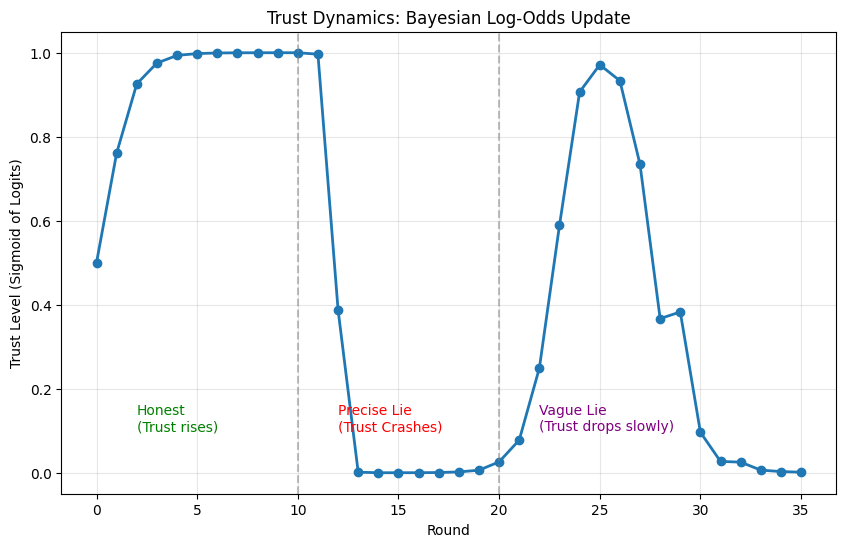

In [6]:
import matplotlib.pyplot as plt
# --- 2. TEST SCRIPT ---

# Initialize
env = LogBayesEnv(alpha_trust=0.5, initial_trust=0.5) 
# Note: Higher alpha (0.5) makes the changes more visible for the test

trust_history = [0.5]
strategies = []

print(f"{'Round':<5} | {'Strategy':<15} | {'Trust':<6} | {'Reward':<6} | {'Speaker Msg (Arm 0)'}")
print("-" * 75)

for t in range(35):
    listener_obs = env.reset()
    true_rewards = env.true_rewards
    
    # --- DEFINE SPEAKER STRATEGY ---
    if t < 10:
        # Phase 1: HONEST & PRECISE
        # "I am telling you exactly what the reward is."
        # Sigma = 0.1 (Very confident)
        utterance = [
            (true_rewards[0], 0.1), 
            (true_rewards[1], 0.1)
        ]
        strategy = "Honest"
        
    elif t < 15:
        # Phase 2: PRECISE LIE
        # "Trust me, Arm 0 is +10 better than it is!"
        # Sigma = 0.1 (Confident lie -> High Risk)
        utterance = [
            (true_rewards[0] + 10.0, 2.0), 
            (true_rewards[1], 0.1)
        ]
        strategy = "Precise Lie"
    
    elif t < 25:
        # Phase 1: HONEST & PRECISE
        # "I am telling you exactly what the reward is."
        # Sigma = 0.1 (Very confident)
        utterance = [
            (true_rewards[0], 0.1), 
            (true_rewards[1], 0.1)
        ]
        strategy = "Honest"
    
    else:
        # Phase 3: VAGUE LIE
        # "Maybe Arm 0 is +10 better? But I'm very unsure."
        # Sigma = 5.0 (Vague lie -> Hedging)
        utterance = [
            (true_rewards[0] + 10.0, 5.0), 
            (true_rewards[1], 5.0)
        ]
        strategy = "Vague Lie"

    # --- STEP ---
    reward, action, info = env.step(utterance)
    
    # Record
    trust_history.append(info['trust'])
    strategies.append(strategy)
    
    # Print (Show msg for Arm 0 to see what we sent)
    msg_str = f"Mu={utterance[0][0]:.1f}, Sig={utterance[0][1]}"
    print(f"{t:<5} | {strategy:<15} | {info['trust']:.4f} | {reward:.2f}   | {msg_str}")

# --- 3. VISUALIZATION ---
plt.figure(figsize=(10, 6))
plt.plot(trust_history, marker='o', linewidth=2, label="Trust ($\tau$)")

# Add phase markers
plt.axvline(x=10, color='gray', linestyle='--', alpha=0.5)
plt.text(2, 0.1, "Honest\n(Trust rises)", fontsize=10, color='green')

plt.axvline(x=20, color='gray', linestyle='--', alpha=0.5)
plt.text(12, 0.1, "Precise Lie\n(Trust Crashes)", fontsize=10, color='red')

plt.text(22, 0.1, "Vague Lie\n(Trust drops slowly)", fontsize=10, color='purple')

plt.title("Trust Dynamics: Bayesian Log-Odds Update")
plt.ylabel("Trust Level (Sigmoid of Logits)")
plt.xlabel("Round")
plt.ylim(-0.05, 1.05)
plt.grid(True, alpha=0.3)
plt.show()

In [3]:
import numpy as np
import itertools
from scipy.stats import norm

# --- HELPER FUNCTIONS (Same as before) ---
def gaussian_kl(mu_p, sigma_p, mu_q, sigma_q):
    sigma_p = np.maximum(sigma_p, 1e-6)
    sigma_q = np.maximum(sigma_q, 1e-6)
    var_p = sigma_p**2
    var_q = sigma_q**2
    term1 = np.log(sigma_q / sigma_p)
    term2 = (var_p + (mu_p - mu_q)**2) / (2 * var_q)
    return term1 + term2 - 0.5

def get_geometric_mixture(mu_1, sigma_1, mu_2, sigma_2, w):
    prec_1 = 1.0 / (sigma_1**2 + 1e-6)
    prec_2 = 1.0 / (sigma_2**2 + 1e-6)
    prec_final = (w * prec_1) + ((1 - w) * prec_2)
    mu_final = ((w * prec_1 * mu_1) + ((1 - w) * prec_2 * mu_2)) / prec_final
    sigma_final = np.sqrt(1.0 / prec_final)
    return mu_final, sigma_final

# --- MYOPIC SPEAKER ---
class MyopicSpeaker:
    def __init__(self, num_arms=2, gamma_honesty=1.0, beta_speaker=5.0, listener_beta=5.0):
        self.num_arms = num_arms
        self.gamma = gamma_honesty
        self.beta = beta_speaker
        self.listener_beta = listener_beta
        # Discrete Utterance Space
        self.means = [-5.0, 0.0, 5.0]
        self.vars = [0.1, 5.0]        
        self.utterance_space = self._generate_space()
        
    def _generate_space(self):
        base = list(itertools.product(self.means, self.vars))
        return list(itertools.product(base, repeat=self.num_arms))

    def choose_utterance(self, trust, obs_S_sees_L, obs_S_sees_S):
        """
        Args:
            trust (float): Listener's current trust level.
            obs_S_sees_L (list): Speaker's estimate of LISTENER'S rewards [(mu, sig), ...]
                                 -> Acts as the "Truth" for Honesty.
            obs_S_sees_S (list): Speaker's estimate of OWN rewards [(mu, sig), ...]
                                 -> Acts as the value for Extrinsic Utility.
        """
        all_utilities = []
        
        # 1. Target Distribution (P) for Informativity
        # "Honesty" means aligning the Listener with what I think THEY will get.
        mu_p = np.array([o[0] for o in obs_S_sees_L])
        sig_p = np.array([o[1] for o in obs_S_sees_L])
        
        # 2. Speaker's Reward Vector (for Extrinsic)
        # We only care about the MEAN reward for utility calculation usually
        rewards_S = np.array([o[0] for o in obs_S_sees_S])

        for u in self.utterance_space:
            mu_u = np.array([x[0] for x in u])
            sig_u = np.array([x[1] for x in u])
            
            # 3. Simulate Listener's Final Belief (Q)
            # Assumption: Speaker assumes Listener sees roughly what Speaker sees for L (Shared Attention)
            # So we use obs_S_sees_L as the Listener's Prior
            mu_q, sig_q = get_geometric_mixture(mu_u, sig_u, mu_p, sig_p, trust)
            
            # 4. Informativity: -KL( P_target || Q_actual )
            # Target = My estimate of Listener's Reality
            kl = gaussian_kl(mu_p, sig_p, mu_q, sig_q)
            u_info = -np.sum(kl)
            
            # 5. Extrinsic: Listener Policy -> My Reward
            exps = np.exp(self.listener_beta * (mu_q - np.max(mu_q)))
            probs_L = exps / np.sum(exps)
            u_extrinsic = np.sum(probs_L * rewards_S)
            
            u_total = u_extrinsic + (self.gamma * u_info)
            all_utilities.append(u_total)
            
        # Boltzmann Selection
        all_utilities = np.array(all_utilities)
        probs_S = np.exp(self.beta * (all_utilities - np.max(all_utilities)))
        probs_S /= np.sum(probs_S)
        
        idx = np.random.choice(len(self.utterance_space), p=probs_S)
        return self.utterance_space[idx], all_utilities[idx]

In [4]:
# --- 3. TEST LOGIC (Run this!) ---

def test_myopic_speaker():
    print("--- STARTING MYOPIC SPEAKER TEST ---")
    
    # SCENARIO: Conflict of Interest
    # Arm 0: Listener thinks it's TRASH (-5.0). Speaker gets RICH (+10.0).
    # Arm 1: Everyone agrees it's Boring (0.0).
    
    # Truth (Listener's View / Prior)
    obs_S_sees_L = [(-5.0, 1.0), (0.0, 1.0)] 
    
    # Incentives (Speaker's View)
    obs_S_sees_S = [(10.0, 1.0), (0.0, 1.0)] 
    
    trust_level = 0.9 # High trust, so lies should work if we try them.
    
    # --- TEST A: THE LIAR (Gamma = 0) ---
    print("\n[Test A] Selfish Speaker (Gamma=0)")
    speaker_selfish = MyopicSpeaker(gamma_honesty=0.0)
    utt_selfish, _ = speaker_selfish.choose_utterance(trust_level, obs_S_sees_L, obs_S_sees_S)
    
    print(f"   Utterance: {utt_selfish}")
    # Interpretation
    if utt_selfish[0][0] > 0:
        print("   ✅ SUCCESS: Speaker lied! (Claimed Arm 0 is positive)")
    else:
        print("   ❌ FAIL: Speaker told the truth despite being selfish.")

    # --- TEST B: THE HONEST AGENT (Gamma = 10) ---
    print("\n[Test B] Honest Speaker (Gamma=10)")
    speaker_honest = MyopicSpeaker(gamma_honesty=10.0)
    utt_honest, _ = speaker_honest.choose_utterance(trust_level, obs_S_sees_L, obs_S_sees_S)
    
    print(f"   Utterance: {utt_honest}")
    # Interpretation
    if utt_honest[0][0] <= -5.0:
        print("   ✅ SUCCESS: Speaker told the truth! (Confirmed Arm 0 is -5.0)")
    else:
        print("   ❌ FAIL: Speaker lied despite honesty penalty.")

# Run it
test_myopic_speaker()

--- STARTING MYOPIC SPEAKER TEST ---

[Test A] Selfish Speaker (Gamma=0)
   Utterance: ((5.0, 0.1), (0.0, 5.0))
   ✅ SUCCESS: Speaker lied! (Claimed Arm 0 is positive)

[Test B] Honest Speaker (Gamma=10)
   Utterance: ((-5.0, 5.0), (0.0, 5.0))
   ✅ SUCCESS: Speaker told the truth! (Confirmed Arm 0 is -5.0)


In [5]:
import numpy as np
import itertools
from scipy.stats import norm

# --- HELPER FUNCTIONS ---
def sigmoid(x):
    # Numerically stable sigmoid function
    # If x >= 0: 1 / (1 + exp(-x))
    # If x < 0:  exp(x) / (1 + exp(x))
    return np.where(x >= 0, 
                    1 / (1 + np.exp(-np.clip(x, -500, 500))), 
                    np.exp(np.clip(x, -500, 500)) / (1 + np.exp(np.clip(x, -500, 500))))

def gaussian_kl(mu_p, sigma_p, mu_q, sigma_q):
    sigma_p = np.maximum(sigma_p, 1e-6)
    sigma_q = np.maximum(sigma_q, 1e-6)
    return np.log(sigma_q / sigma_p) + (sigma_p**2 + (mu_p - mu_q)**2) / (2 * sigma_q**2) - 0.5

def get_geometric_mixture(mu_1, sigma_1, mu_2, sigma_2, w):
    prec_1 = 1.0 / (sigma_1**2 + 1e-6)
    prec_2 = 1.0 / (sigma_2**2 + 1e-6)
    prec_final = (w * prec_1) + ((1 - w) * prec_2)
    mu_final = ((w * prec_1 * mu_1) + ((1 - w) * prec_2 * mu_2)) / prec_final
    sigma_final = np.sqrt(1.0 / prec_final)
    return mu_final, sigma_final

class RollingHorizonSpeaker:
    def __init__(self, num_arms=2, horizon=2, gamma_honesty=1.0, 
                 alpha_trust=0.2, beta_listener=5.0, beta_speaker=5.0): # Added beta_speaker
        self.num_arms = num_arms
        self.horizon = horizon
        self.gamma = gamma_honesty
        self.alpha_trust = alpha_trust
        self.beta_listener = beta_listener
        self.beta_speaker = beta_speaker # Controls softmax temperature for Speaker
        
        # Discretized Action Space
        self.means = [-5.0, 0.0, 5.0]
        self.vars = [0.1, 5.0]        
        base = list(itertools.product(self.means, self.vars))
        self.utterance_space = list(itertools.product(base, repeat=self.num_arms))

    def plan(self, current_trust, obs_L_seq, obs_S_truth_seq, obs_S_incentive_seq):
        """
        Root-level planning: Calculates Q-values for all current utterances, 
        applies Softmax, and samples an action.
        """
        safe_trust = np.clip(current_trust, 0.001, 0.999)
        initial_logits = np.log(safe_trust / (1.0 - safe_trust))
        
        eff_horizon = min(self.horizon, len(obs_L_seq))
        
        # 1. Calculate Q-values for all utterances at step 0
        q_values = []
        
        for u in self.utterance_space:
            # Evaluate this action using the recursive value function for the FUTURE
            q_val = self._evaluate_action(
                u, initial_logits, obs_L_seq, obs_S_truth_seq, obs_S_incentive_seq, 
                depth=eff_horizon, step_idx=0
            )
            q_values.append(q_val)
            
        q_values = np.array(q_values)
        
        # 2. Apply Softmax (Boltzmann Rationality)
        # Shift for numerical stability
        exps = np.exp(self.beta_speaker * (q_values - np.max(q_values)))
        probs = exps / np.sum(exps)
        
        # 3. Sample Action
        idx = np.random.choice(len(self.utterance_space), p=probs)
        chosen_u = self.utterance_space[idx]
        chosen_val = q_values[idx]
        
        return chosen_u, chosen_val

    def _evaluate_action(self, u, trust_logits, obs_L_seq, obs_S_truth_seq, obs_S_incentive_seq, depth, step_idx):
        """
        Calculates Q(s, u) = Immediate_Reward + Expected_Future_Value
        """
        trust_prob = sigmoid(trust_logits)
        
        curr_L_prior = obs_L_seq[step_idx]
        curr_S_truth = obs_S_truth_seq[step_idx]
        curr_S_inc   = obs_S_incentive_seq[step_idx]

        # --- A. SIMULATE LISTENER BELIEF ---
        new_beliefs_L = []
        kl_cost = 0.0
        
        for i in range(self.num_arms):
            mu_u, sig_u = u[i]
            mu_prior, sig_prior = curr_L_prior[i]
            
            # Geometric Update
            mu_new, sig_new = get_geometric_mixture(mu_u, sig_u, mu_prior, sig_prior, trust_prob)
            new_beliefs_L.append((mu_new, sig_new))
            
            # Honesty Cost
            mu_true, sig_true = curr_S_truth[i]
            kl_cost += gaussian_kl(mu_true, sig_true, mu_new, sig_new)
        
        utility_info = -kl_cost

        # --- B. SIMULATE LISTENER ACTION ---
        means_new = np.array([b[0] for b in new_beliefs_L])
        exps = np.exp(self.beta_listener * (means_new - np.max(means_new)))
        probs_L = exps / np.sum(exps)
        
        # --- C. IMMEDIATE REWARD ---
        incentive_values = np.array([o[0] for o in curr_S_inc])
        utility_extrinsic = np.sum(probs_L * incentive_values)
        
        immediate_reward = utility_extrinsic + (self.gamma * utility_info)

        # --- D. FUTURE VALUE (Recurse) ---
        future_value_expected = 0.0
        
        # If we have depth left, we look ahead
        if depth > 1 and (step_idx + 1) < len(obs_L_seq):
            for action_idx in range(self.num_arms):
                prob_action = probs_L[action_idx]
                if prob_action < 0.01: continue 
                
                # Simulate Trust Update (Rational) based on "Predicted Observation"
                # Prediction: Listener sees Truth (curr_S_truth)
                predicted_observation = curr_S_truth[action_idx][0]
                
                mu_s_msg, sig_s_msg = u[action_idx]
                mu_l_prior, sig_l_prior = curr_L_prior[action_idx]
                
                score_s = norm.logpdf(predicted_observation, loc=mu_s_msg, scale=sig_s_msg + 1e-6)
                score_l = norm.logpdf(predicted_observation, loc=mu_l_prior, scale=sig_l_prior + 1e-6)
                
                new_logits = trust_logits + (self.alpha_trust * (score_s - score_l))
                
                # RECURSE: Get the MAX value of the next state (Standard Q-Learning assumption)
                # Note: We assume the agent will act optimally (or near optimally) in the future.
                val_future = self._get_state_value_soft(
                    new_logits, obs_L_seq, obs_S_truth_seq, obs_S_incentive_seq, 
                    depth - 1, step_idx + 1
                )
                
                future_value_expected += prob_action * val_future

        return immediate_reward + future_value_expected

    def _get_state_value_soft(self, trust_logits, obs_L_seq, obs_S_truth_seq, obs_S_incentive_seq, depth, step_idx):
        """
        Returns the Soft Value V(s) using the Log-Sum-Exp trick.
        Ref: Ziebart et al. (2008); Levine (2018).
        """
        if depth == 0 or step_idx >= len(obs_L_seq):
            return 0.0
            
        q_values = []
        for u in self.utterance_space:
            val = self._evaluate_action(
                u, trust_logits, obs_L_seq, obs_S_truth_seq, obs_S_incentive_seq, 
                depth, step_idx
            )
            q_values.append(val)
        
        q_values = np.array(q_values)
        
        # Soft Maximum (LogSumExp)
        # Formula: V(s) = (1/beta) * log( sum( exp( beta * Q(s,a) ) ) )
        # Using numerical stability trick: log(sum(exp(x))) = max(x) + log(sum(exp(x-max(x))))
        
        beta = self.beta_speaker
        max_q = np.max(q_values)
        
        soft_value = max_q + (1.0 / beta) * np.log(np.sum(np.exp(beta * (q_values - max_q))))
        
        return soft_value
        

In [130]:
def run_unit_tests():
    print("=== STARTING UNIT TESTS ===")
    
    # --- SCENARIO 1: THE GREEDY LIAR (Myopic) ---
    print("\n--- TEST 1: THE GREEDY LIAR (H=0, Gamma=0) ---")
    # Arm 0: Truth -10, Incentive +100.
    obs_L_seq = [[(0.0, 1.0), (0.0, 1.0)]] # Neutral Prior
    obs_S_truth_seq = [[(-10.0, 1.0), (0.0, 1.0)]] # Truth
    obs_S_inc_seq = [[(100.0, 1.0), (0.0, 1.0)]]   # Incentive
    
    agent = RollingHorizonSpeaker(horizon=0, gamma_honesty=0.0, beta_speaker=10.0)
    utt, val = agent.plan(0.5, obs_L_seq, obs_S_truth_seq, obs_S_inc_seq)
    
    print(f"Truth for Arm 0: -10.0")
    print(f"Incentive for Arm 0: +100.0")
    print(f"Agent Said (Arm 0): Mean={utt[0][0]}, Var={utt[0][1]}")
    
    if utt[0][0] > 0:
        print("✅ PASS: Agent lied to get the reward.")
    else:
        print("❌ FAIL: Agent told the truth (or failed to maximize).")


    # --- SCENARIO 2: THE HONEST MARTYR (Myopic, High Gamma) ---
    print("\n--- TEST 2: THE HONEST MARTYR (H=0, Gamma=50) ---")
    # Same setup, but Gamma is huge
    agent_honest = RollingHorizonSpeaker(horizon=0, gamma_honesty=50.0, beta_speaker=10.0)
    utt, val = agent_honest.plan(0.5, obs_L_seq, obs_S_truth_seq, obs_S_inc_seq)
    
    print(f"Agent Said (Arm 0): Mean={utt[0][0]}, Var={utt[0][1]}")
    
    if utt[0][0] <= -5.0:
        print("✅ PASS: Agent told the truth despite high reward.")
    else:
        print("❌ FAIL: Agent lied (Gamma didn't override greed).")


    # --- SCENARIO 3: THE LONG CON (Strategic vs Myopic) ---
    print("\n--- TEST 3: THE LONG CON (H=2) ---")
    # Step 1: Low Stakes (Truth -5, Inc +10)
    # Step 2: High Stakes (Truth -5, Inc +1000)
    
    obs_L_seq = [
        [(0.0, 1.0), (0.0, 1.0)], # Step 1 Prior
        [(0.0, 1.0), (0.0, 1.0)]  # Step 2 Prior
    ]
    obs_S_truth_seq = [
        [(-5.0, 1.0), (0.0, 1.0)], # Step 1 Truth
        [(-5.0, 1.0), (0.0, 1.0)]  # Step 2 Truth
    ]
    obs_S_inc_seq = [
        [(10.0, 1.0), (0.0, 1.0)],   # Step 1 Incentive (Small)
        [(1000.0, 1.0), (0.0, 1.0)]  # Step 2 Incentive (HUGE)
    ]
    
    # A. Run Myopic
    print(">> Subtest A: Myopic (H=0)")
    agent_myopic = RollingHorizonSpeaker(horizon=0, gamma_honesty=0.0, beta_speaker=10.0)
    utt_myopic, _ = agent_myopic.plan(0.5, obs_L_seq, obs_S_truth_seq, obs_S_inc_seq)
    print(f"   Myopic Step 1 Action: {utt_myopic[0]}")
    
    # B. Run Strategic
    print(">> Subtest B: Strategic (H=2)")
    agent_strategic = RollingHorizonSpeaker(horizon=2, gamma_honesty=0.0, beta_speaker=10.0)
    utt_strategic, _ = agent_strategic.plan(0.5, obs_L_seq, obs_S_truth_seq, obs_S_inc_seq)
    print(f"   Strategic Step 1 Action: {utt_strategic[0]}")
    
    # CHECK LOGIC
    # Myopic should lie in Step 1 (Mean > 0)
    # Strategic should tell truth in Step 1 (Mean <= -5) to save trust for Step 2
    
    if utt_myopic[0][0] > 0 and utt_strategic[0][0] <= 0:
        print("✅ PASS: Strategic Agent delayed gratification (Told truth now to lie later).")
    elif utt_strategic[0][0] > 0:
        print("❌ FAIL: Strategic Agent lied immediately (Failed to plan for Step 2).")
    else:
        print("⚠️ INCONCLUSIVE: Check output values.")

run_unit_tests()

=== STARTING UNIT TESTS ===

--- TEST 1: THE GREEDY LIAR (H=0, Gamma=0) ---
Truth for Arm 0: -10.0
Incentive for Arm 0: +100.0
Agent Said (Arm 0): Mean=5.0, Var=0.1
✅ PASS: Agent lied to get the reward.

--- TEST 2: THE HONEST MARTYR (H=0, Gamma=50) ---
Agent Said (Arm 0): Mean=-5.0, Var=5.0
✅ PASS: Agent told the truth despite high reward.

--- TEST 3: THE LONG CON (H=2) ---
>> Subtest A: Myopic (H=0)
   Myopic Step 1 Action: (0.0, 0.1)
>> Subtest B: Strategic (H=2)
   Strategic Step 1 Action: (-5.0, 5.0)
⚠️ INCONCLUSIVE: Check output values.


--- RUNNING FINAL STRATEGIC HONESTY EXPERIMENT ---
Simulating Horizon H=0...
Simulating Horizon H=2...


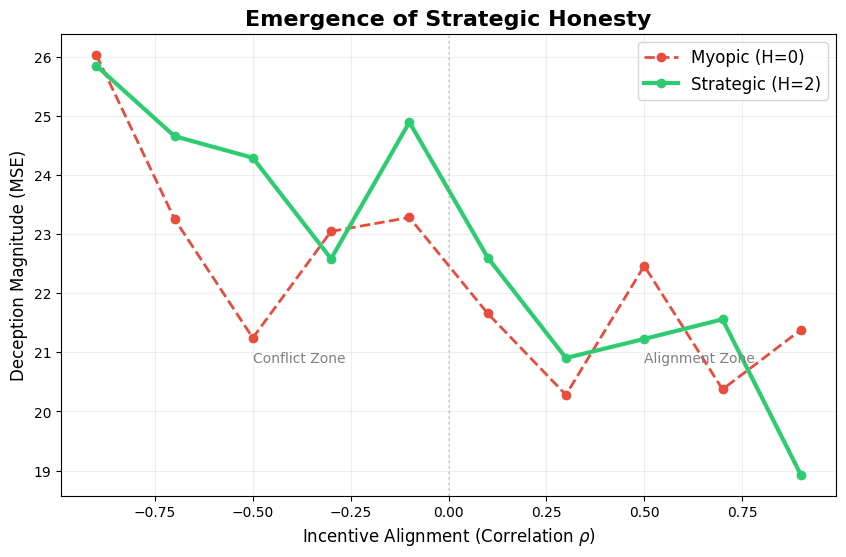

In [131]:
import matplotlib.pyplot as plt

def run_final_experiment():
    print("--- RUNNING FINAL STRATEGIC HONESTY EXPERIMENT ---")
    
    # 1. Setup Parameters
    correlations = np.linspace(-0.9, 0.9, 10) # Sweep from Conflict to Alignment
    horizons = [0, 2] # Compare Myopic vs Strategic
    n_episodes = 40   # Games per data point (Higher = Smoother graph)
    steps_per_game = 8
    
    # Store results: results[horizon] = [avg_mse_at_rho1, avg_mse_at_rho2, ...]
    results = {h: [] for h in horizons}
    
    for h in horizons:
        print(f"Simulating Horizon H={h}...")
        
        for rho in correlations:
            total_mse = 0.0
            
            # Covariance for (Truth, Incentive)
            mean = [0, 0]
            cov = [[1.0, rho], [rho, 1.0]]
            
            for _ in range(n_episodes):
                # A. Generate The Game Sequence
                # We need separate sequences for L_Prior, S_Truth, S_Incentive
                obs_L_seq = []
                obs_S_truth_seq = []
                obs_S_inc_seq = []
                
                # Generate enough steps for the game + horizon buffer
                for _ in range(steps_per_game + h + 2):
                    step_L = []
                    step_S_truth = []
                    step_S_inc = []
                    
                    for _ in range(2): # Two Arms
                        # Sample Correlated Truth vs Incentive
                        vals = np.random.multivariate_normal(mean, cov)
                        val_truth = vals[0] * 3.0     # Scale up
                        val_incentive = vals[1] * 3.0 # Scale up
                        
                        # Listener Prior (Noisy, centered on Truth)
                        step_L.append((val_truth + np.random.normal(0, 2.0), 2.0))
                        
                        # Speaker Truth View (Precise)
                        step_S_truth.append((val_truth, 0.1))
                        
                        # Speaker Incentive View (Precise)
                        step_S_inc.append((val_incentive, 0.1))
                        
                    obs_L_seq.append(step_L)
                    obs_S_truth_seq.append(step_S_truth)
                    obs_S_inc_seq.append(step_S_inc)
                
                # B. Run The Agent
                # Note: We use lower gamma to allow some lying, so we can see the difference
                agent = RollingHorizonSpeaker(horizon=h, gamma_honesty=0.2, beta_speaker=5.0)
                curr_trust = 0.5
                episode_mse = 0.0
                
                for t in range(steps_per_game):
                    # Slice Lookahead Windows
                    win_L = obs_L_seq[t : t + h + 1]
                    win_S_truth = obs_S_truth_seq[t : t + h + 1]
                    win_S_inc = obs_S_inc_seq[t : t + h + 1]
                    
                    # PLAN
                    utt, val = agent.plan(curr_trust, win_L, win_S_truth, win_S_inc)
                    
                    # MEASURE DECEPTION (MSE from Truth)
                    # We compare the Mean of the Utterance for Arm 0 to the Truth of Arm 0
                    truth_mu = win_S_truth[0][0][0]
                    utt_mu = utt[0][0]
                    episode_mse += (utt_mu - truth_mu)**2
                    
                    # EXECUTE (Simulate Trust Update)
                    # We assume Listener picks the arm with higher expected utility based on message
                    # But for trust update, we just simulate the update on Arm 0 or Arm 1
                    # (Simplified: The environment forces a check on the 'Best' arm)
                    
                    # 1. Listener Action Logic (Simple)
                    # Get posterior means
                    m0_prior, s0_prior = win_L[0][0]
                    m1_prior, s1_prior = win_L[0][1]
                    # Update with message
                    m0_post, _ = get_geometric_mixture(utt[0][0], utt[0][1], m0_prior, s0_prior, curr_trust)
                    m1_post, _ = get_geometric_mixture(utt[1][0], utt[1][1], m1_prior, s1_prior, curr_trust)
                    
                    action = 0 if m0_post > m1_post else 1
                    
                    # 2. Trust Update
                    # Listener sees REAL TRUTH (from S_Truth sequence)
                    real_val = win_S_truth[0][action][0] 
                    
                    mu_s, sig_s = utt[action]
                    mu_l, sig_l = win_L[0][action]
                    
                    score_s = norm.logpdf(real_val, loc=mu_s, scale=sig_s + 1e-6)
                    score_l = norm.logpdf(real_val, loc=mu_l, scale=sig_l + 1e-6)
                    
                    evidence = score_s - score_l
                    logit = np.log(np.clip(curr_trust, 0.001, 0.999) / (1 - np.clip(curr_trust, 0.001, 0.999)))
                    logit += 0.5 * evidence # Alpha_trust = 0.5
                    curr_trust = sigmoid(logit)
                
                total_mse += (episode_mse / steps_per_game)
                
            results[h].append(total_mse / n_episodes)
            
    return correlations, results

# --- RUN AND PLOT ---
rhos, data = run_final_experiment()

plt.figure(figsize=(10, 6))
# Plot Myopic
plt.plot(rhos, data[0], label='Myopic (H=0)', color='#e74c3c', linewidth=2, marker='o', linestyle='--')
# Plot Strategic
plt.plot(rhos, data[2], label='Strategic (H=2)', color='#2ecc71', linewidth=3, marker='o')



plt.title('Emergence of Strategic Honesty', fontsize=16, fontweight='bold')
plt.xlabel('Incentive Alignment (Correlation $\\rho$)', fontsize=12)
plt.ylabel('Deception Magnitude (MSE)', fontsize=12)
plt.axvline(0, color='gray', alpha=0.3, linestyle=':')
plt.legend(fontsize=12)
plt.grid(True, alpha=0.2)

# Annotation
plt.text(-0.5, max(data[0])*0.8, "Conflict Zone", fontsize=10, color='gray')
plt.text(0.5, max(data[0])*0.8, "Alignment Zone", fontsize=10, color='gray')

plt.show()

In [7]:
class RollingHorizonSpeaker:
    def __init__(self, num_arms=2, horizon=2, gamma_honesty=1.0, 
                 alpha_trust=1.0, beta_listener=5.0, beta_speaker=5.0,
                 msg_means=None, msg_vars=None):
        self.num_arms = num_arms
        self.horizon = horizon
        self.gamma = gamma_honesty
        self.alpha_trust = alpha_trust
        self.beta_listener = beta_listener
        self.beta_speaker = beta_speaker
        
        # Build Discretized Action Space
        self.means = msg_means if msg_means else [-5.0, 0.0, 5.0]
        self.vars = msg_vars if msg_vars else [0.1, 5.0]        
        base = list(itertools.product(self.means, self.vars))
        self.utterance_space = list(itertools.product(base, repeat=self.num_arms))

    def get_policy_distribution(self, current_trust, obs_L_seq, obs_S_truth_seq, obs_S_incentive_seq):
        """
        Calculates the softmax policy distribution over all possible utterances.
        """
        safe_trust = np.clip(current_trust, 0.001, 0.999)
        initial_logits = np.log(safe_trust / (1.0 - safe_trust))
        
        # Ensure we don't look past the end of the game
        eff_horizon = min(self.horizon, len(obs_L_seq))
        
        q_values = []
        for u in self.utterance_space:
            # Full Recursive Evaluation
            q_val = self._evaluate_action(
                u, initial_logits, obs_L_seq, obs_S_truth_seq, obs_S_incentive_seq, 
                depth=eff_horizon, step_idx=0
            )
            q_values.append(q_val)
            
        q_values = np.array(q_values)
        
        # Apply Softmax (Boltzmann Policy)
        # Shift q_values for numerical stability
        exps = np.exp(self.beta_speaker * (q_values - np.max(q_values)))
        probs = exps / np.sum(exps)
        
        return self.utterance_space, probs

    def _evaluate_action(self, u, trust_logits, obs_L_seq, obs_S_truth_seq, obs_S_incentive_seq, depth, step_idx):
        """
        Recursive Soft-Bellman Equation:
        Q(s, u) = Immediate_Reward + Expected_Value_Next_State
        """
        trust_prob = sigmoid(trust_logits)
        curr_L_prior = obs_L_seq[step_idx]
        curr_S_truth = obs_S_truth_seq[step_idx]
        curr_S_inc   = obs_S_incentive_seq[step_idx]

        # --- A. SIMULATE LISTENER BELIEF UPDATE ---
        new_beliefs_L = []
        kl_cost = 0.0
        
        for i in range(self.num_arms):
            mu_u, sig_u = u[i]
            mu_prior, sig_prior = curr_L_prior[i]
            
            # Geometric Pooling (Trust-weighted update)
            mu_new, sig_new = get_geometric_mixture(mu_u, sig_u, mu_prior, sig_prior, trust_prob)
            new_beliefs_L.append((mu_new, sig_new))
            
            # Global Honesty Cost (Sum over ALL arms)
            mu_true, sig_true = curr_S_truth[i]
            kl_cost += gaussian_kl(mu_true, sig_true, mu_new, sig_new)
        
        utility_info = -kl_cost

        # --- B. SIMULATE LISTENER DECISION ---
        means_new = np.array([b[0] for b in new_beliefs_L])
        # Listener chooses based on their new belief means
        exps = np.exp(self.beta_listener * (means_new - np.max(means_new)))
        probs_L = exps / np.sum(exps)
        
        # --- C. IMMEDIATE REWARD (Instrumental) ---
        incentive_values = np.array([o[0] for o in curr_S_inc])
        utility_extrinsic = np.sum(probs_L * incentive_values)
        
        immediate_utility = utility_extrinsic + (self.gamma * utility_info)

        # --- D. FUTURE VALUE (Recursion) ---
        future_value_expected = 0.0
        
        # Only recurse if we have horizon left AND data left
        if depth > 1 and (step_idx + 1) < len(obs_L_seq):
            
            # Expectation over Listener's Action
            for action_idx in range(self.num_arms):
                prob_action = probs_L[action_idx]
                
                # Optimization: Skip negligible branches
                if prob_action < 0.001: continue 
                
                # --- TRUST UPDATE (Verification Bottleneck) ---
                # Listener observes truth ONLY for action_idx
                predicted_observation = curr_S_truth[action_idx][0]
                
                mu_s_msg, sig_s_msg = u[action_idx]
                mu_l_prior, sig_l_prior = curr_L_prior[action_idx]
                
                # Calculate Evidence (Log Likelihood Ratio)
                score_s = norm.logpdf(predicted_observation, loc=mu_s_msg, scale=sig_s_msg + 1e-6)
                score_l = norm.logpdf(predicted_observation, loc=mu_l_prior, scale=sig_l_prior + 1e-6)
                
                new_logits = trust_logits + (self.alpha_trust * (score_s - score_l))
                
                # Recursively calculate Value of the next state V(s')
                val_future = self._get_state_value_soft(
                    new_logits, obs_L_seq, obs_S_truth_seq, obs_S_incentive_seq, 
                    depth - 1, step_idx + 1
                )
                
                future_value_expected += prob_action * val_future

        return immediate_utility + future_value_expected

    def _get_state_value_soft(self, trust_logits, obs_L_seq, obs_S_truth_seq, obs_S_incentive_seq, depth, step_idx):
        """
        Calculates V(s) = SoftMax_u( Q(s, u) )
        """
        if depth == 0 or step_idx >= len(obs_L_seq):
            return 0.0
            
        q_values = []
        for u in self.utterance_space:
            val = self._evaluate_action(
                u, trust_logits, obs_L_seq, obs_S_truth_seq, obs_S_incentive_seq, 
                depth, step_idx
            )
            q_values.append(val)
        
        q_values = np.array(q_values)
        
        # LogSumExp for Soft Value
        beta = self.beta_speaker
        max_q = np.max(q_values)
        soft_value = max_q + (1.0 / beta) * np.log(np.sum(np.exp(beta * (q_values - max_q))))
        
        return soft_value

In [8]:
import numpy as np
import pandas as pd

# ==========================================
# 1. EXPERIMENT CONFIGURATION
# ==========================================
CONFIG = {
    # --- Agent Parameters ---
    "horizon_myopic": 1,       # Baseline: Greedy
    "horizon_strategic": 2,    # Experiment: Plans ahead (Sees trust impact)
    "gamma_honesty": 0.0,      # Low cost: Agent is willing to lie if profitable
    "alpha_trust": 1.0,        # Learning Rate: Trust updates quickly after verification
    
    # Rationality (Temperature)
    "beta_speaker": 2.0,       # High: Agent aggressively picks the best option
    "beta_listener": 3.0,      # High: Listener creates sharp decision boundaries
    
    # --- Action Space (Discretized Messages) ---
    "msg_means": [-5.0, 0.0, 5.0],
    "msg_vars":  [0.1, 5.0],   # 0.1=Precise, 5.0=Vague
    
    # --- Scenario Setup (Conflict) ---
    # Target Arm (0): Truth=0.0 (Bad), Incentive=10.0 (High Reward for Speaker)
    # Alt Arm (1):    Truth=5.0 (Good), Incentive=0.0  (No Reward)
    # Goal: Speaker wants Listener to pick Arm 0 despite it being worse.
    "truth_vals":     [0.0, 5.0],
    "incentive_vals": [10.0, 0.0],
    
    # --- Listener Prior ---
    # Listener thinks Arm 1 is better (Mean=5.0).
    # We use high variance (4.0) so they are "persuadable".
    "listener_prior_means": [0.0, 5.0],
    "listener_prior_vars":  [2.0, 2.0],
    
    # Initial Trust Level (Neutral)
    "start_trust": 0.5
}

# ==========================================
# 2. HELPER: STRATEGY CLASSIFIER
# ==========================================
def classify_utterance(u, target_idx, truth_vals):
    """
    Returns a human-readable label for the strategy.
    u: List of [(mu, var), (mu, var)]
    """
    msg_t_mu, msg_t_var = u[target_idx]
    msg_a_mu, msg_a_var = u[1 - target_idx]
    
    true_t = truth_vals[target_idx]
    true_a = truth_vals[1 - target_idx]

    # Thresholds
    is_vague_t = msg_t_var > 2.0
    is_vague_a = msg_a_var > 2.0
    
    # Check Hype (Saying Target is much better than truth)
    # E.g., Truth=0, Msg=5
    is_hyping = (msg_t_mu > true_t + 2.0)
    
    # Check Trash (Saying Alt is much worse than truth)
    # E.g., Truth=5, Msg=-5
    is_trashing = (msg_a_mu < true_a - 2.0)
    
    label = []
    
    if is_vague_t and is_vague_a:
        return "VAGUE (Safety)"
    
    if is_hyping:
        label.append("HYPE_TARGET")
    if is_trashing:
        label.append("TRASH_ALT")
        
    if not label:
        # If not lying significantly, check accuracy
        if abs(msg_t_mu - true_t) < 2.0 and abs(msg_a_mu - true_a) < 2.0:
            return "HONEST"
        return "INACCURATE (Other)"
        
    return " + ".join(label)

In [179]:
# ==========================================
# 5. EXPERIMENT EXECUTION (2D Matrix Output)
# ==========================================
def run_experiment():
    print("\n" + "="*80)
    print(f" EXPERIMENT: THE VERIFICATION GAP (Trashing vs. Hyping)")
    print(f" Target Arm (0): Truth={CONFIG['truth_vals'][0]} | Reward={CONFIG['incentive_vals'][0]}")
    print(f" Alt Arm (1):    Truth={CONFIG['truth_vals'][1]} | Reward={CONFIG['incentive_vals'][1]}")
    print("="*80)
    
    # Setup Simulation Data
    H_sim = 3
    obs_L       = [[(m, v) for m, v in zip(CONFIG["listener_prior_means"], CONFIG["listener_prior_vars"])]] * H_sim
    obs_S_truth = [[(val, 0.1) for val in CONFIG["truth_vals"]]] * H_sim
    obs_S_inc   = [[(val, 0.1) for val in CONFIG["incentive_vals"]]] * H_sim
    
    # --- 1. Compute Policies ---
    print(f"Computing policies...")
    
    s_myopic = RollingHorizonSpeaker(
        num_arms=2,
        horizon=CONFIG["horizon_myopic"], 
        gamma_honesty=CONFIG["gamma_honesty"],
        alpha_trust=CONFIG["alpha_trust"],
        beta_speaker=CONFIG["beta_speaker"],
        beta_listener=CONFIG["beta_listener"],
        msg_means=CONFIG["msg_means"],
        msg_vars=CONFIG["msg_vars"]
    )
    
    s_strat = RollingHorizonSpeaker(
        num_arms=2,
        horizon=CONFIG["horizon_strategic"], 
        gamma_honesty=CONFIG["gamma_honesty"],
        alpha_trust=CONFIG["alpha_trust"],
        beta_speaker=CONFIG["beta_speaker"],
        beta_listener=CONFIG["beta_listener"],
        msg_means=CONFIG["msg_means"],
        msg_vars=CONFIG["msg_vars"]
    )
    
    space, probs_m = s_myopic.get_policy_distribution(CONFIG["start_trust"], obs_L, obs_S_truth, obs_S_inc)
    _, probs_s = s_strat.get_policy_distribution(CONFIG["start_trust"], obs_L, obs_S_truth, obs_S_inc)
    
    # --- 2. Helper to Format Table ---
    def make_2d_table(probs, title):
        # We want Rows = Target Msg, Cols = Alt Msg
        # Get the base set of messages (e.g. 6 messages)
        base = list(itertools.product(CONFIG["msg_means"], CONFIG["msg_vars"]))
        labels = [f"µ={m:.0f},σ²={v:.1f}" for m, v in base]
        
        # Create empty DataFrame with 0.0s
        df = pd.DataFrame(0.0, index=labels, columns=labels)
        
        # Fill Matrix
        # Note: 'space' is generated by itertools.product(base, repeat=2)
        # Order: Target (Slow), Alt (Fast)
        for k, u in enumerate(space):
            u_t = u[0] # Target Msg
            u_a = u[1] # Alt Msg
            
            # Find labels
            row_lbl = f"µ={u_t[0]:.0f},σ²={u_t[1]:.1f}"
            col_lbl = f"µ={u_a[0]:.0f},σ²={u_a[1]:.1f}"
            
            df.at[row_lbl, col_lbl] = probs[k]
            
        print(f"\n>>> {title} <<<")
        print("Rows = Target Message | Cols = Alternative Message")
        print(df)
        return df

    # --- 3. Print Tables ---
    pd.set_option('display.max_columns', None)
    pd.set_option('display.width', 1000)
    pd.set_option('display.float_format', '{:.3f}'.format)

    df_m = make_2d_table(probs_m, f"MYOPIC AGENT (H={CONFIG['horizon_myopic']})")
    df_s = make_2d_table(probs_s, f"STRATEGIC AGENT (H={CONFIG['horizon_strategic']})")
    df_m.head()
    df_s.head()
    # Optional: Print Difference Table
    print(f"\n>>> STRATEGIC SHIFT (Strategic - Myopic) <<<")
    print("Positive values = Strategies preferred by Planning Agent")
    print(df_s - df_m)


In [9]:
import pandas as pd
import itertools

# ==========================================
# 1. EXPERIMENT PARAMETERS (Edit Here)
# ==========================================
# --- Agent Settings ---
HORIZON_MYOPIC    = 1      # Baseline (Greedy)
HORIZON_STRATEGIC = 2      # Planning (Sees Step 2)
GAMMA_HONESTY     = 0.0    # Low cost of lying
ALPHA_TRUST       = 5.0    # Learning rate for trust updates
BETA_SPEAKER      = 3.0    # Rationality
BETA_LISTENER     = 3.0    # Decision sharpness

# --- Action Space ---
MSG_MEANS = [-5.0, 0.0, 5.0]
MSG_VARS  = [0.1, 5.0]

# --- STEP 1: CURRENT STATE (The conflict right now) ---
# Target Arm (0): Truth=0.0 (Bad), Incentive=10.0 (High) -> Speaker wants to trick Listener
# Alt Arm (1):    Truth=5.0 (Good), Incentive=-10.0 (Penalty) -> Speaker avoids Good arm
CURR_TRUTH      = [0.0, 5.0]
CURR_INCENTIVES = [10.0, -10.0] 

# Listener Prior (Accurate Means but Unsure)
L_PRIOR_MEANS   = [0.0, 5.0]
L_PRIOR_VARS    = [2.0, 2.0] 
START_TRUST     = 0.5

# --- STEP 2+: FUTURE SIMULATION (What happens next?) ---
# You can change these to test if the agent anticipates a changing world.
# currently set to match current state (static world)
FUTURE_TRUTH      = [0.0, 5.0]  
FUTURE_INCENTIVES = [100.0, 0.0] # Agent expects same conflict in future

# ==========================================
# 2. RUN EXPERIMENT
# ==========================================
def run_notebook_experiment():
    print(f"--- RUNNING EXPERIMENT ---")
    print(f"Current Incentives: {CURR_INCENTIVES}")
    print(f"Future Incentives:  {FUTURE_INCENTIVES}")
    
    # 1. Construct Simulation Sequences (History + Future)
    # We construct the observation sequences explicitly step-by-step
    obs_L = []
    obs_S_truth = []
    obs_S_inc = []
    
    # Step 0 (Current)
    obs_L.append([(m, v) for m, v in zip(L_PRIOR_MEANS, L_PRIOR_VARS)])
    obs_S_truth.append([(v, 0.1) for v in CURR_TRUTH])
    obs_S_inc.append([(v, 0.1) for v in CURR_INCENTIVES])
    
    # Step 1...H (Future/Simulation) - extending for horizon
    for _ in range(3): 
        # In simulation, we assume Listener carries over belief, but for the 
        # 'environment' params, we use the FUTURE settings defined above.
        obs_L.append([(m, v) for m, v in zip(L_PRIOR_MEANS, L_PRIOR_VARS)]) 
        obs_S_truth.append([(v, 0.1) for v in FUTURE_TRUTH])
        obs_S_inc.append([(v, 0.1) for v in FUTURE_INCENTIVES])

    # 2. Instantiate Agents
    s_myopic = RollingHorizonSpeaker(
        num_arms=2, horizon=HORIZON_MYOPIC, 
        gamma_honesty=GAMMA_HONESTY, alpha_trust=ALPHA_TRUST, 
        beta_speaker=BETA_SPEAKER, beta_listener=BETA_LISTENER,
        msg_means=MSG_MEANS, msg_vars=MSG_VARS
    )
    
    s_strat = RollingHorizonSpeaker(
        num_arms=2, horizon=HORIZON_STRATEGIC, 
        gamma_honesty=GAMMA_HONESTY, alpha_trust=ALPHA_TRUST, 
        beta_speaker=BETA_SPEAKER, beta_listener=BETA_LISTENER,
        msg_means=MSG_MEANS, msg_vars=MSG_VARS
    )

    # 3. Compute Policies
    print("Computing Myopic Policy...")
    space, probs_m = s_myopic.get_policy_distribution(START_TRUST, obs_L, obs_S_truth, obs_S_inc)
    
    print("Computing Strategic Policy...")
    _, probs_s = s_strat.get_policy_distribution(START_TRUST, obs_L, obs_S_truth, obs_S_inc)

    # 4. Visualize as 2D Matrix
    def display_matrix(probs, title):
        # Create labels based on Message Space
        base = list(itertools.product(MSG_MEANS, MSG_VARS))
        labels = [f"µ={m:.0f},σ²={v:.1f}" for m, v in base]
        
        df = pd.DataFrame(0.0, index=labels, columns=labels)
        
        for k, u in enumerate(space):
            u_t, u_a = u[0], u[1]
            row_lbl = f"µ={u_t[0]:.0f},σ²={u_t[1]:.1f}"
            col_lbl = f"µ={u_a[0]:.0f},σ²={u_a[1]:.1f}"
            df.at[row_lbl, col_lbl] = probs[k]
            
        print(f"\n>>> {title} <<<")
        print("Rows = Target Msg | Cols = Alt Msg")
        display(df) # Using display() for nice Jupyter formatting
        return df

    # Display settings
    pd.set_option('display.float_format', '{:.3f}'.format)
    
    df_m = display_matrix(probs_m, f"MYOPIC (H={HORIZON_MYOPIC})")
    df_s = display_matrix(probs_s, f"STRATEGIC (H={HORIZON_STRATEGIC})")
    
    print(f"\n>>> STRATEGIC SHIFT (Strategic - Myopic) <<<")
    display(df_s - df_m)

# Execute
run_notebook_experiment()

--- RUNNING EXPERIMENT ---
Current Incentives: [10.0, -10.0]
Future Incentives:  [100.0, 0.0]
Computing Myopic Policy...
Computing Strategic Policy...

>>> MYOPIC (H=1) <<<
Rows = Target Msg | Cols = Alt Msg


,"µ=-5,σ²=0.1","µ=-5,σ²=5.0","µ=0,σ²=0.1","µ=0,σ²=5.0","µ=5,σ²=0.1","µ=5,σ²=5.0"
"µ=-5,σ²=0.1",0.000,0.000,0.000,0.000,0.000,0.000
"µ=-5,σ²=5.0",0.157,0.000,0.000,0.000,0.000,0.000
"µ=0,σ²=0.1",0.157,0.000,0.000,0.000,0.000,0.000
"µ=0,σ²=5.0",0.157,0.000,0.000,0.000,0.000,0.000
"µ=5,σ²=0.1",0.157,0.059,0.157,0.000,0.000,0.000
"µ=5,σ²=5.0",0.157,0.000,0.000,0.000,0.000,0.000



>>> STRATEGIC (H=2) <<<
Rows = Target Msg | Cols = Alt Msg


,"µ=-5,σ²=0.1","µ=-5,σ²=5.0","µ=0,σ²=0.1","µ=0,σ²=5.0","µ=5,σ²=0.1","µ=5,σ²=5.0"
"µ=-5,σ²=0.1",0.000,0.000,0.000,0.000,0.000,0.000
"µ=-5,σ²=5.0",0.000,0.000,0.000,0.000,0.000,0.000
"µ=0,σ²=0.1",0.673,0.000,0.000,0.000,0.000,0.000
"µ=0,σ²=5.0",0.327,0.000,0.000,0.000,0.000,0.000
"µ=5,σ²=0.1",0.000,0.000,0.000,0.000,0.000,0.000
"µ=5,σ²=5.0",0.000,0.000,0.000,0.000,0.000,0.000



>>> STRATEGIC SHIFT (Strategic - Myopic) <<<


,"µ=-5,σ²=0.1","µ=-5,σ²=5.0","µ=0,σ²=0.1","µ=0,σ²=5.0","µ=5,σ²=0.1","µ=5,σ²=5.0"
"µ=-5,σ²=0.1",-0.000,-0.000,-0.000,-0.000,0.000,0.000
"µ=-5,σ²=5.0",-0.157,-0.000,-0.000,-0.000,0.000,0.000
"µ=0,σ²=0.1",0.516,-0.000,-0.000,-0.000,0.000,0.000
"µ=0,σ²=5.0",0.170,-0.000,-0.000,-0.000,0.000,0.000
"µ=5,σ²=0.1",-0.157,-0.059,-0.157,-0.000,-0.000,-0.000
"µ=5,σ²=5.0",-0.157,-0.000,-0.000,-0.000,0.000,0.000


In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

def plot_strategy_comparison(df_myopic, df_strategic, alpha_val):
    """
    Generates 3 heatmaps: Myopic, Strategic, and the Difference.
    Includes the Alpha Value in the title for clear comparison.
    """
    # Setup Figure
    fig, axes = plt.subplots(1, 3, figsize=(24, 7))
    plt.subplots_adjust(wspace=0.3)
    
    # Common Args for Heatmaps
    heatmap_args = {
        "annot": True, 
        "fmt": ".2f", 
        "cmap": "Greens", 
        "vmin": 0.0, 
        "vmax": max(df_myopic.max().max(), df_strategic.max().max()), # Scale to global max
        "cbar": False,
        "square": True,
        "linewidths": 0.5,
        "linecolor": "gray"
    }

    # 1. Myopic Plot (Baseline)
    sns.heatmap(df_myopic, ax=axes[0], **heatmap_args)
    axes[0].set_title(f"Myopic Policy (H=1)\nGreedy Deception", fontsize=14, fontweight='bold', pad=15)
    axes[0].set_xlabel("Alternative Arm Message", fontsize=12)
    axes[0].set_ylabel("Target Arm Message", fontsize=12)

    # 2. Strategic Plot (Planning)
    sns.heatmap(df_strategic, ax=axes[1], **heatmap_args)
    axes[1].set_title(f"Strategic Policy (H=2)\nCalculated Manipulation", fontsize=14, fontweight='bold', pad=15)
    axes[1].set_xlabel("Alternative Arm Message", fontsize=12)
    axes[1].set_yticks([]) # Hide y-labels

    # 3. Difference Plot (The Shift)
    df_diff = df_strategic - df_myopic
    
    # Use diverging colormap (Red=Increase, Blue=Decrease)
    limit = max(abs(df_diff.min().min()), abs(df_diff.max().max()))
    sns.heatmap(df_diff, ax=axes[2], annot=True, fmt=".2f", 
                cmap="coolwarm", center=0.0, vmin=-limit, vmax=limit,
                square=True, linewidths=0.5, linecolor="gray", cbar=True)
    
    axes[2].set_title(f"Strategic Shift (Strat - Myopic)\nRed = Adopted, Blue = Abandoned", fontsize=14, fontweight='bold', pad=15)
    axes[2].set_xlabel("Alternative Arm Message", fontsize=12)
    axes[2].set_yticks([]) 

    # Clean up labels (rotate for readability)
    for ax in axes:
        plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")
        plt.setp(ax.get_yticklabels(), rotation=0)

    # Main Title with Alpha
    title_str = f"Verification Gap (Alpha = {alpha_val})"
        
    plt.suptitle(title_str, fontsize=20, y=1.05)
    
    return fig

--- RUNNING EXPERIMENT ---
Current Incentives: [10.0, -10.0]
Future Incentives:  [100.0, 0.0]
Computing Myopic Policy...
Computing Strategic Policy...


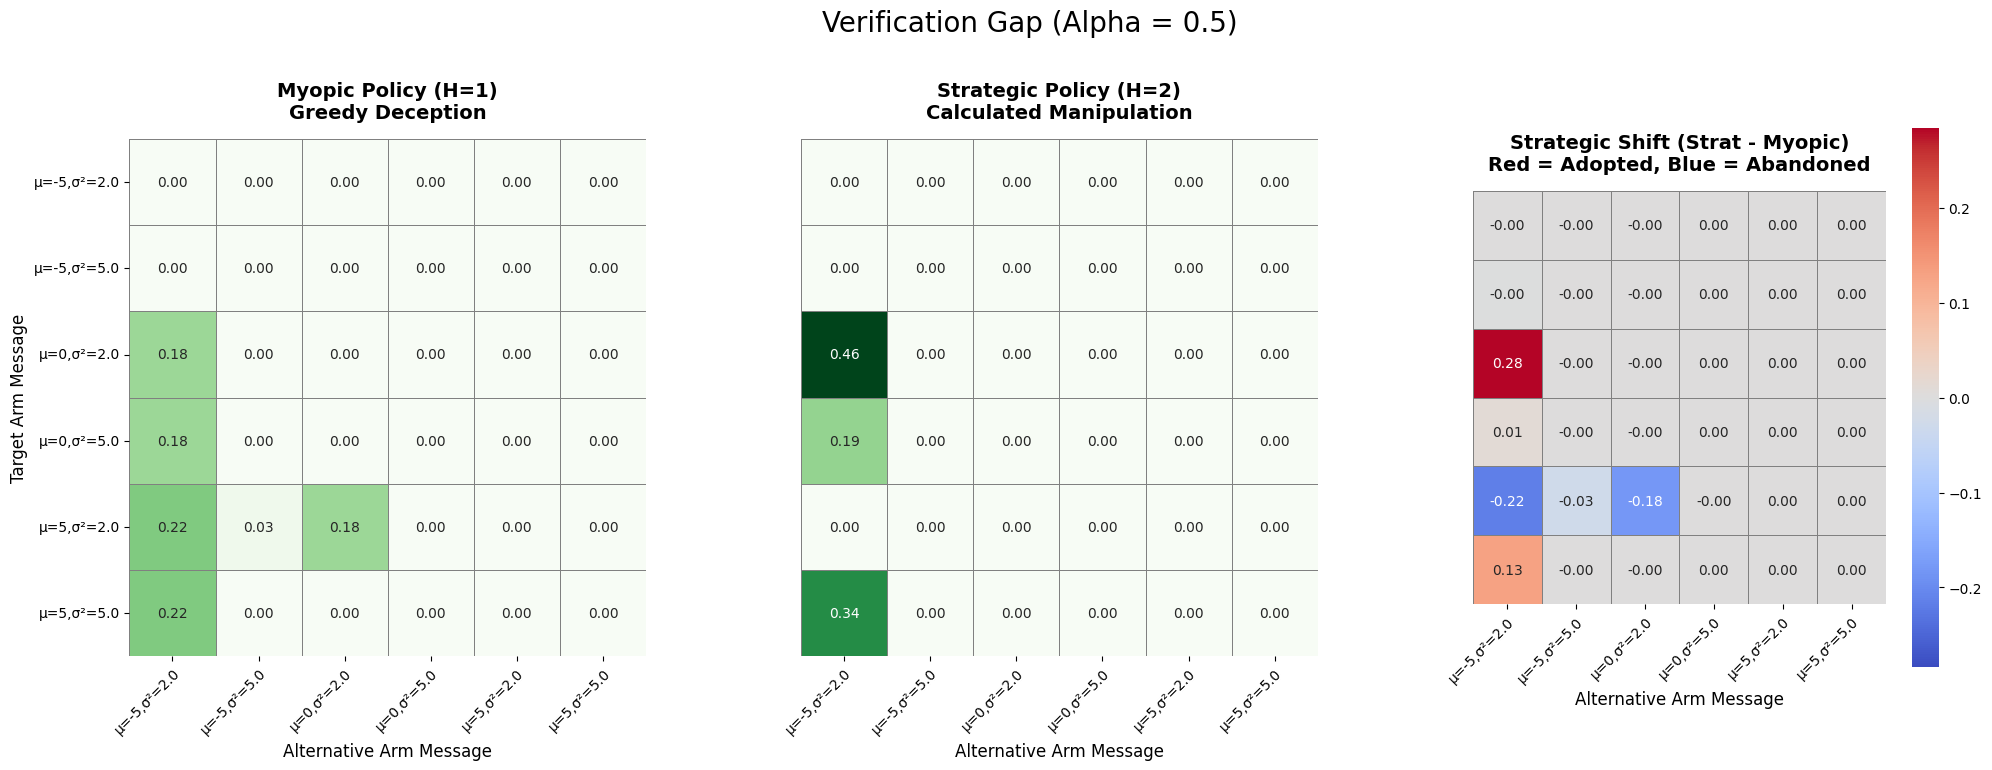

In [11]:
import pandas as pd
import itertools

# ==========================================
# 1. EXPERIMENT PARAMETERS (Edit Here)
# ==========================================
# --- Agent Settings ---
HORIZON_MYOPIC    = 1      # Baseline (Greedy)
HORIZON_STRATEGIC = 2      # Planning (Sees Step 2)
GAMMA_HONESTY     = 0.0    # Low cost of lying
ALPHA_TRUST       = 0.5    # Learning rate for trust updates
BETA_SPEAKER      = 3.0    # Rationality
BETA_LISTENER     = 3.0    # Decision sharpness

# --- Action Space ---
MSG_MEANS = [-5.0, 0.0, 5.0]
MSG_VARS  = [2.0, 5.0]

# --- STEP 1: CURRENT STATE (The conflict right now) ---
# Target Arm (0): Truth=0.0 (Bad), Incentive=10.0 (High) -> Speaker wants to trick Listener
# Alt Arm (1):    Truth=5.0 (Good), Incentive=-10.0 (Penalty) -> Speaker avoids Good arm
CURR_TRUTH      = [0.0, 5.0]
CURR_INCENTIVES = [10.0, -10.0] 

# Listener Prior (Accurate Means but Unsure)
L_PRIOR_MEANS   = [0.0, 5.0]
L_PRIOR_VARS    = [3.0, 3.0] 
START_TRUST     = 0.50

# --- STEP 2+: FUTURE SIMULATION (What happens next?) ---
# You can change these to test if the agent anticipates a changing world.
# currently set to match current state (static world)
FUTURE_TRUTH      = [0.0, 5.0]  
FUTURE_INCENTIVES = [100.0, 0.0] # Agent expects same conflict in future

# ==========================================
# 2. RUN EXPERIMENT
# ==========================================
def run_notebook_experiment():
    print(f"--- RUNNING EXPERIMENT ---")
    print(f"Current Incentives: {CURR_INCENTIVES}")
    print(f"Future Incentives:  {FUTURE_INCENTIVES}")
    
    # 1. Construct Simulation Sequences (History + Future)
    # We construct the observation sequences explicitly step-by-step
    obs_L = []
    obs_S_truth = []
    obs_S_inc = []
    
    # Step 0 (Current)
    obs_L.append([(m, v) for m, v in zip(L_PRIOR_MEANS, L_PRIOR_VARS)])
    obs_S_truth.append([(v, 0.1) for v in CURR_TRUTH])
    obs_S_inc.append([(v, 0.1) for v in CURR_INCENTIVES])
    
    # Step 1...H (Future/Simulation) - extending for horizon
    for _ in range(3): 
        # In simulation, we assume Listener carries over belief, but for the 
        # 'environment' params, we use the FUTURE settings defined above.
        obs_L.append([(m, v) for m, v in zip(L_PRIOR_MEANS, L_PRIOR_VARS)]) 
        obs_S_truth.append([(v, 0.1) for v in FUTURE_TRUTH])
        obs_S_inc.append([(v, 0.1) for v in FUTURE_INCENTIVES])

    # 2. Instantiate Agents
    s_myopic = RollingHorizonSpeaker(
        num_arms=2, horizon=HORIZON_MYOPIC, 
        gamma_honesty=GAMMA_HONESTY, alpha_trust=ALPHA_TRUST, 
        beta_speaker=BETA_SPEAKER, beta_listener=BETA_LISTENER,
        msg_means=MSG_MEANS, msg_vars=MSG_VARS
    )
    
    s_strat = RollingHorizonSpeaker(
        num_arms=2, horizon=HORIZON_STRATEGIC, 
        gamma_honesty=GAMMA_HONESTY, alpha_trust=ALPHA_TRUST, 
        beta_speaker=BETA_SPEAKER, beta_listener=BETA_LISTENER,
        msg_means=MSG_MEANS, msg_vars=MSG_VARS
    )

    # 3. Compute Policies
    print("Computing Myopic Policy...")
    space, probs_m = s_myopic.get_policy_distribution(START_TRUST, obs_L, obs_S_truth, obs_S_inc)
    
    print("Computing Strategic Policy...")
    _, probs_s = s_strat.get_policy_distribution(START_TRUST, obs_L, obs_S_truth, obs_S_inc)

    # 4. Visualize as 2D Matrix
    def display_matrix(probs, title):
        # Create labels based on Message Space
        base = list(itertools.product(MSG_MEANS, MSG_VARS))
        labels = [f"µ={m:.0f},σ²={v:.1f}" for m, v in base]
        
        df = pd.DataFrame(0.0, index=labels, columns=labels)
        
        for k, u in enumerate(space):
            u_t, u_a = u[0], u[1]
            row_lbl = f"µ={u_t[0]:.0f},σ²={u_t[1]:.1f}"
            col_lbl = f"µ={u_a[0]:.0f},σ²={u_a[1]:.1f}"
            df.at[row_lbl, col_lbl] = probs[k]
            
        print(f"\n>>> {title} <<<")
        print("Rows = Target Msg | Cols = Alt Msg")
        display(df) # Using display() for nice Jupyter formatting
        return df

    # Display settings
    pd.set_option('display.float_format', '{:.3f}'.format)
    
    #df_m = display_matrix(probs_m, f"MYOPIC (H={HORIZON_MYOPIC})")
    #df_s = display_matrix(probs_s, f"STRATEGIC (H={HORIZON_STRATEGIC})")
    
    #print(f"\n>>> STRATEGIC SHIFT (Strategic - Myopic) <<<")
    #display(df_s - df_m)
    
        # Helper to make DF
    def to_df(probs):
        base = list(itertools.product(MSG_MEANS, MSG_VARS))
        labels = [f"µ={m:.0f},σ²={v:.1f}" for m, v in base]
        df = pd.DataFrame(0.0, index=labels, columns=labels)
        for k, u in enumerate(space):
            u_t, u_a = u[0], u[1]
            row = f"µ={u_t[0]:.0f},σ²={u_t[1]:.1f}"
            col = f"µ={u_a[0]:.0f},σ²={u_a[1]:.1f}"
            df.at[row, col] = probs[k]
        return df

    return to_df(probs_m), to_df(probs_s)

df_m, df_s = run_notebook_experiment()

# 2. Plot
fig = plot_strategy_comparison(df_m, df_s, ALPHA_TRUST)
plt.show()

--- RUNNING EXPERIMENT ---
Current Incentives: [10.0, -10.0]
Future Incentives:  [100.0, 0.0]
Computing Myopic Policy...
Computing Strategic Policy...


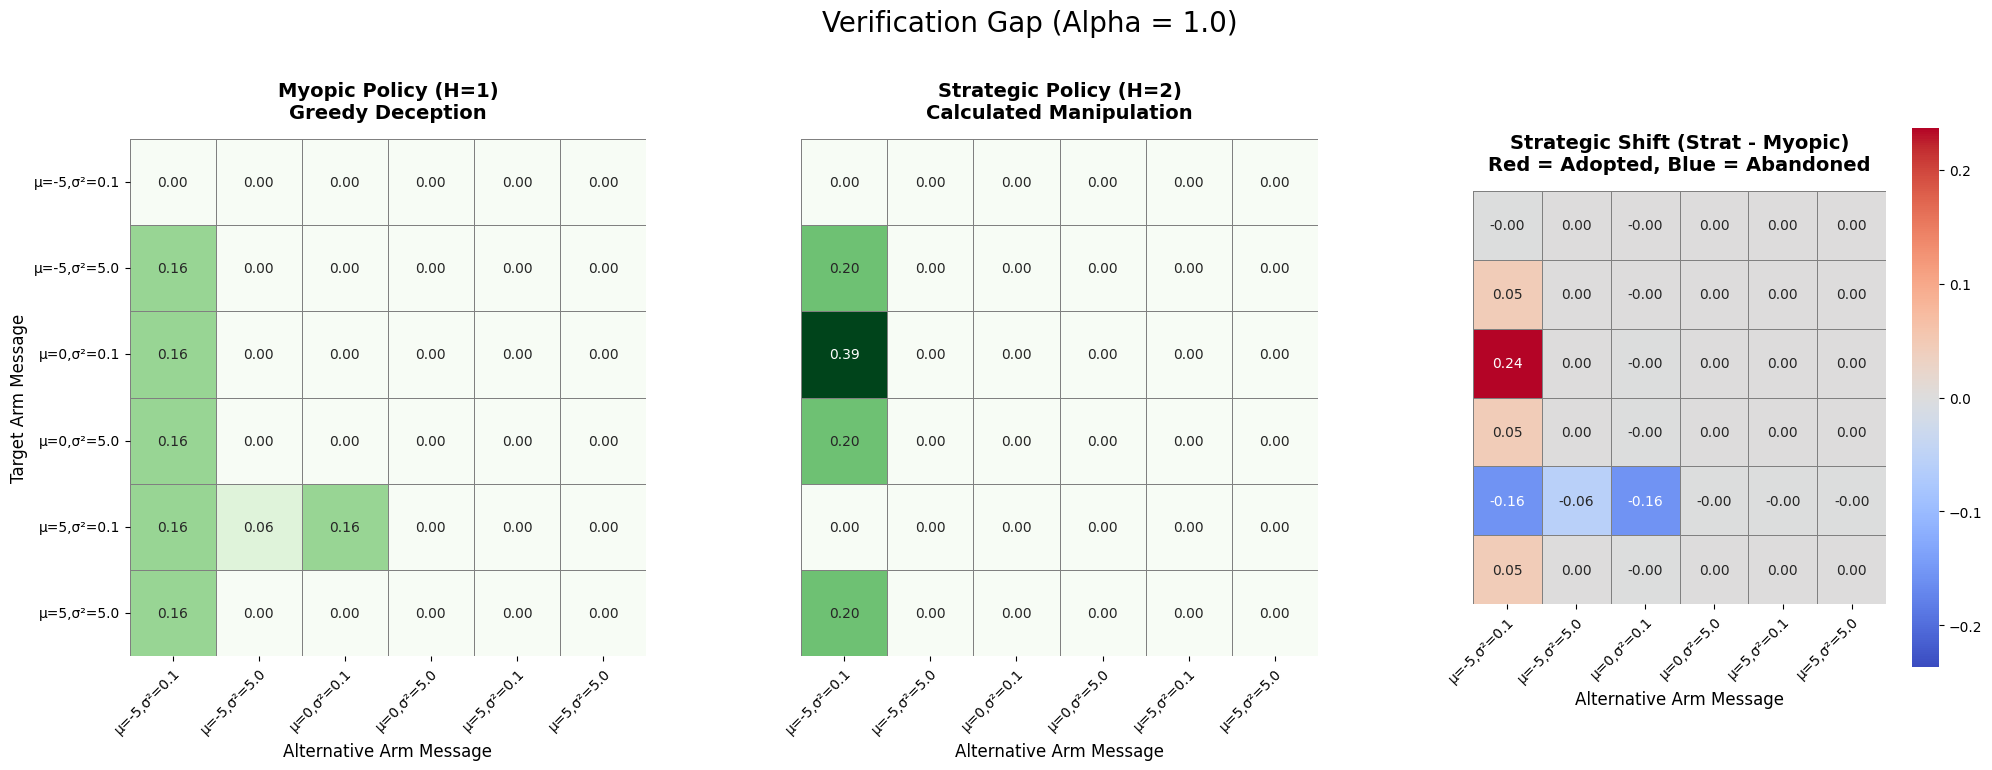

In [12]:
import pandas as pd
import itertools

# ==========================================
# 1. EXPERIMENT PARAMETERS (Edit Here)
# ==========================================
# --- Agent Settings ---
HORIZON_MYOPIC    = 1      # Baseline (Greedy)
HORIZON_STRATEGIC = 2      # Planning (Sees Step 2)
GAMMA_HONESTY     = 0.0    # Low cost of lying
ALPHA_TRUST       = 1.0    # Learning rate for trust updates
BETA_SPEAKER      = 3.0    # Rationality
BETA_LISTENER     = 3.0    # Decision sharpness

# --- Action Space ---
MSG_MEANS = [-5.0, 0.0, 5.0]
MSG_VARS  = [0.1, 5.0]

# --- STEP 1: CURRENT STATE (The conflict right now) ---
# Target Arm (0): Truth=0.0 (Bad), Incentive=10.0 (High) -> Speaker wants to trick Listener
# Alt Arm (1):    Truth=5.0 (Good), Incentive=-10.0 (Penalty) -> Speaker avoids Good arm
CURR_TRUTH      = [0.0, 5.0]
CURR_INCENTIVES = [10.0, -10.0] 

# Listener Prior (Accurate Means but Unsure)
L_PRIOR_MEANS   = [0.0, 5.0]
L_PRIOR_VARS    = [2.0, 2.0] 
START_TRUST     = 0.5

# --- STEP 2+: FUTURE SIMULATION (What happens next?) ---
# You can change these to test if the agent anticipates a changing world.
# currently set to match current state (static world)
FUTURE_TRUTH      = [0.0, 5.0]  
FUTURE_INCENTIVES = [100.0, 0.0] # Agent expects same conflict in future

# ==========================================
# 2. RUN EXPERIMENT
# ==========================================
def run_notebook_experiment():
    print(f"--- RUNNING EXPERIMENT ---")
    print(f"Current Incentives: {CURR_INCENTIVES}")
    print(f"Future Incentives:  {FUTURE_INCENTIVES}")
    
    # 1. Construct Simulation Sequences (History + Future)
    # We construct the observation sequences explicitly step-by-step
    obs_L = []
    obs_S_truth = []
    obs_S_inc = []
    
    # Step 0 (Current)
    obs_L.append([(m, v) for m, v in zip(L_PRIOR_MEANS, L_PRIOR_VARS)])
    obs_S_truth.append([(v, 0.1) for v in CURR_TRUTH])
    obs_S_inc.append([(v, 0.1) for v in CURR_INCENTIVES])
    
    # Step 1...H (Future/Simulation) - extending for horizon
    for _ in range(3): 
        # In simulation, we assume Listener carries over belief, but for the 
        # 'environment' params, we use the FUTURE settings defined above.
        obs_L.append([(m, v) for m, v in zip(L_PRIOR_MEANS, L_PRIOR_VARS)]) 
        obs_S_truth.append([(v, 0.1) for v in FUTURE_TRUTH])
        obs_S_inc.append([(v, 0.1) for v in FUTURE_INCENTIVES])

    # 2. Instantiate Agents
    s_myopic = RollingHorizonSpeaker(
        num_arms=2, horizon=HORIZON_MYOPIC, 
        gamma_honesty=GAMMA_HONESTY, alpha_trust=ALPHA_TRUST, 
        beta_speaker=BETA_SPEAKER, beta_listener=BETA_LISTENER,
        msg_means=MSG_MEANS, msg_vars=MSG_VARS
    )
    
    s_strat = RollingHorizonSpeaker(
        num_arms=2, horizon=HORIZON_STRATEGIC, 
        gamma_honesty=GAMMA_HONESTY, alpha_trust=ALPHA_TRUST, 
        beta_speaker=BETA_SPEAKER, beta_listener=BETA_LISTENER,
        msg_means=MSG_MEANS, msg_vars=MSG_VARS
    )

    # 3. Compute Policies
    print("Computing Myopic Policy...")
    space, probs_m = s_myopic.get_policy_distribution(START_TRUST, obs_L, obs_S_truth, obs_S_inc)
    
    print("Computing Strategic Policy...")
    _, probs_s = s_strat.get_policy_distribution(START_TRUST, obs_L, obs_S_truth, obs_S_inc)

    # 4. Visualize as 2D Matrix
    def display_matrix(probs, title):
        # Create labels based on Message Space
        base = list(itertools.product(MSG_MEANS, MSG_VARS))
        labels = [f"µ={m:.0f},σ²={v:.1f}" for m, v in base]
        
        df = pd.DataFrame(0.0, index=labels, columns=labels)
        
        for k, u in enumerate(space):
            u_t, u_a = u[0], u[1]
            row_lbl = f"µ={u_t[0]:.0f},σ²={u_t[1]:.1f}"
            col_lbl = f"µ={u_a[0]:.0f},σ²={u_a[1]:.1f}"
            df.at[row_lbl, col_lbl] = probs[k]
            
        print(f"\n>>> {title} <<<")
        print("Rows = Target Msg | Cols = Alt Msg")
        display(df) # Using display() for nice Jupyter formatting
        return df

    # Display settings
    pd.set_option('display.float_format', '{:.3f}'.format)
    
    #df_m = display_matrix(probs_m, f"MYOPIC (H={HORIZON_MYOPIC})")
    #df_s = display_matrix(probs_s, f"STRATEGIC (H={HORIZON_STRATEGIC})")
    
    #print(f"\n>>> STRATEGIC SHIFT (Strategic - Myopic) <<<")
    #display(df_s - df_m)
    
        # Helper to make DF
    def to_df(probs):
        base = list(itertools.product(MSG_MEANS, MSG_VARS))
        labels = [f"µ={m:.0f},σ²={v:.1f}" for m, v in base]
        df = pd.DataFrame(0.0, index=labels, columns=labels)
        for k, u in enumerate(space):
            u_t, u_a = u[0], u[1]
            row = f"µ={u_t[0]:.0f},σ²={u_t[1]:.1f}"
            col = f"µ={u_a[0]:.0f},σ²={u_a[1]:.1f}"
            df.at[row, col] = probs[k]
        return df

    return to_df(probs_m), to_df(probs_s)

df_m, df_s = run_notebook_experiment()

# 2. Plot
fig = plot_strategy_comparison(df_m, df_s, ALPHA_TRUST)
plt.show()

Running Alpha Sweep over 21 points...


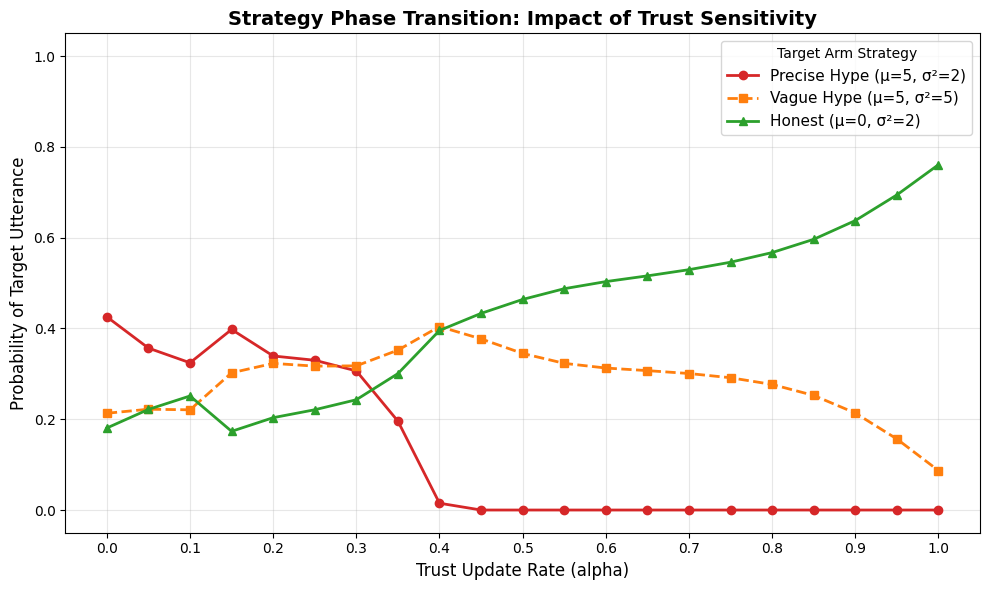

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import itertools

# ==========================================
# 1. PARAMETERS & SETUP
# ==========================================
# Sweep Parameters
alpha_values = np.arange(0.0, 1.05, 0.05)

# Fixed Game Settings
HORIZON_STRATEGIC = 2
HORIZON_MYOPIC    = 1
GAMMA_HONESTY     = 0.0
BETA_SPEAKER      = 3.0
BETA_LISTENER     = 3.0

# Action Space
MSG_MEANS = [-5.0, 0.0, 5.0]
MSG_VARS  = [2.0, 5.0]

# Environment (Adversarial Trap)
CURR_TRUTH      = [0.0, 5.0]
CURR_INCENTIVES = [10.0, -10.0]
FUTURE_TRUTH    = [0.0, 5.0]
FUTURE_INCENTIVES = [100.0, 0.0]

# Listener Prior
L_PRIOR_MEANS   = [0.0, 5.0]
L_PRIOR_VARS    = [3.0, 3.0]
START_TRUST     = 0.50

# ==========================================
# 2. DATA COLLECTION FUNCTIONS
# ==========================================

def get_strategy_probs(alpha):
    """Runs one simulation for a specific alpha and returns the probability matrix."""
    
    # Construct Observation Sequences
    obs_L = []
    obs_S_truth = []
    obs_S_inc = []
    
    # Sequence Construction (Current + Future)
    # Step 0
    obs_L.append([(m, v) for m, v in zip(L_PRIOR_MEANS, L_PRIOR_VARS)])
    obs_S_truth.append([(v, 0.1) for v in CURR_TRUTH])
    obs_S_inc.append([(v, 0.1) for v in CURR_INCENTIVES])
    
    # Future Steps
    for _ in range(3): 
        obs_L.append([(m, v) for m, v in zip(L_PRIOR_MEANS, L_PRIOR_VARS)]) 
        obs_S_truth.append([(v, 0.1) for v in FUTURE_TRUTH])
        obs_S_inc.append([(v, 0.1) for v in FUTURE_INCENTIVES])

    # Instantiate Strategic Agent
    agent = RollingHorizonSpeaker(
        num_arms=2, horizon=HORIZON_STRATEGIC, 
        gamma_honesty=GAMMA_HONESTY, alpha_trust=alpha, 
        beta_speaker=BETA_SPEAKER, beta_listener=BETA_LISTENER,
        msg_means=MSG_MEANS, msg_vars=MSG_VARS
    )
    
    # Get Policy
    space, probs = agent.get_policy_distribution(START_TRUST, obs_L, obs_S_truth, obs_S_inc)
    
    # Convert to DataFrame Matrix
    base = list(itertools.product(MSG_MEANS, MSG_VARS))
    labels = [f"µ={m:.0f},σ²={v:.1f}" for m, v in base]
    df = pd.DataFrame(0.0, index=labels, columns=labels)
    
    for k, u in enumerate(space):
        u_t, u_a = u[0], u[1]
        row_lbl = f"µ={u_t[0]:.0f},σ²={u_t[1]:.1f}"
        col_lbl = f"µ={u_a[0]:.0f},σ²={u_a[1]:.1f}"
        df.at[row_lbl, col_lbl] += probs[k] # Accumulate prob
        
    return df

# ==========================================
# 3. EXECUTE SWEEP
# ==========================================
print(f"Running Alpha Sweep over {len(alpha_values)} points...")

results = {
    "hype_precise": [], # Target µ=5, σ²=2.0 (Precise Lie)
    "hype_vague":   [], # Target µ=5, σ²=5.0 (Vague Lie)
    "honest":       []  # Target µ=0, σ²=2.0 (Precise Truth)
}

for alpha in alpha_values:
    df = get_strategy_probs(alpha)
    
    # Target Arm is the ROWS. 
    # We sum across columns (Alt Arm) to get total prob of that Target utterance.
    
    # 1. Precise Hype (Lying with Confidence)
    p_hype_precise = df.loc["µ=5,σ²=2.0"].sum()
    
    # 2. Vague Hype (Lying with Plausible Deniability)
    p_hype_vague = df.loc["µ=5,σ²=5.0"].sum()
    
    # 3. Honest (Telling the Truth to save trust)
    p_honest = df.loc["µ=0,σ²=2.0"].sum()
    
    results["hype_precise"].append(p_hype_precise)
    results["hype_vague"].append(p_hype_vague)
    results["honest"].append(p_honest)

# ==========================================
# 4. PLOTTING
# ==========================================
plt.figure(figsize=(10, 6))

# Plot Lines
plt.plot(alpha_values, results["hype_precise"], label="Precise Hype (µ=5, σ²=2)", 
         marker='o', color='#d62728', linewidth=2) # Red
plt.plot(alpha_values, results["hype_vague"],   label="Vague Hype (µ=5, σ²=5)",   
         marker='s', color='#ff7f0e', linewidth=2, linestyle='--') # Orange
plt.plot(alpha_values, results["honest"],       label="Honest (µ=0, σ²=2)",       
         marker='^', color='#2ca02c', linewidth=2) # Green

# Formatting
plt.title("Strategy Phase Transition: Impact of Trust Sensitivity", fontsize=14, fontweight='bold')
plt.xlabel("Trust Update Rate (alpha)", fontsize=12)
plt.ylabel("Probability of Target Utterance", fontsize=12)
plt.xticks(np.arange(0, 1.1, 0.1))
plt.ylim(-0.05, 1.05)
plt.grid(True, alpha=0.3)
plt.legend(title="Target Arm Strategy", fontsize=11)

plt.tight_layout()
plt.show()

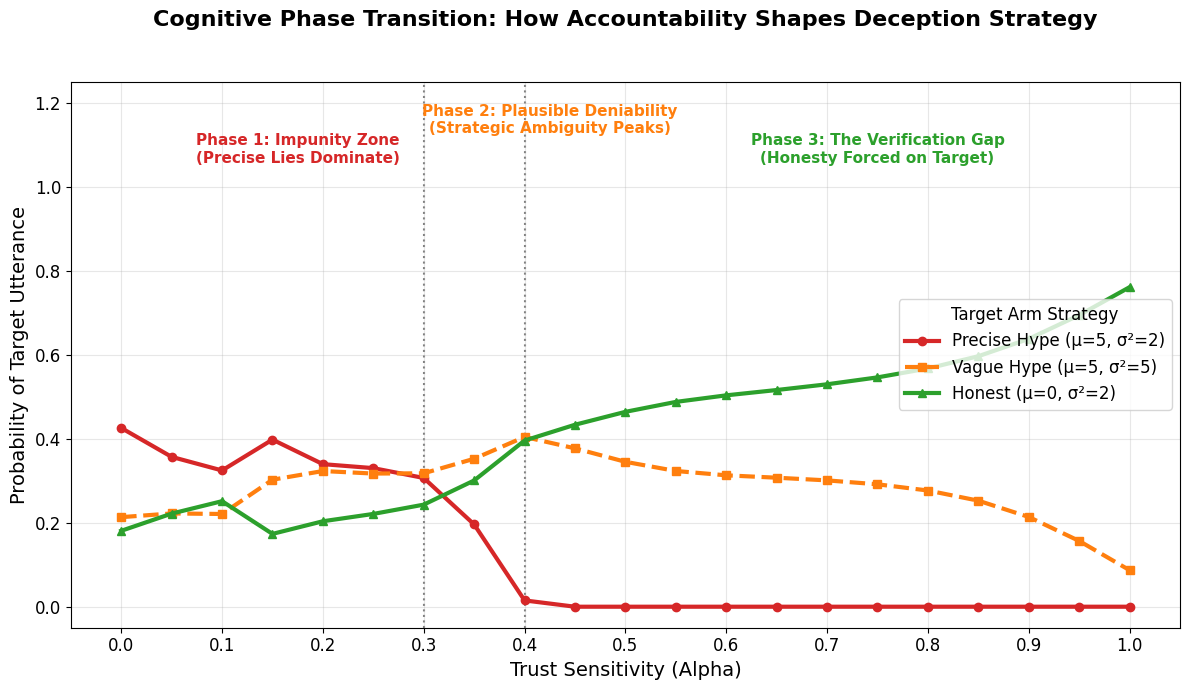

In [14]:
# ==========================================
# 4. PLOTTING (WITH PHASE ANNOTATIONS)
# ==========================================
plt.figure(figsize=(12, 7)) # Slightly wider for text

# --- 1. Main Data Lines ---
plt.plot(alpha_values, results["hype_precise"], label="Precise Hype (µ=5, σ²=2)", 
         marker='o', color='#d62728', linewidth=3, zorder=3) # Red
plt.plot(alpha_values, results["hype_vague"],   label="Vague Hype (µ=5, σ²=5)",   
         marker='s', color='#ff7f0e', linewidth=3, linestyle='--', zorder=3) # Orange
plt.plot(alpha_values, results["honest"],       label="Honest (µ=0, σ²=2)",       
         marker='^', color='#2ca02c', linewidth=3, zorder=3) # Green

# --- 2. Phase Annotations ---
# Add vertical lines marking the transition points (determined visually from data)
plt.axvline(x=0.30, color='gray', linestyle=':', linewidth=1.5, zorder=1)
plt.axvline(x=0.40, color='gray', linestyle=':', linewidth=1.5, zorder=1)

# Add Zone Labels
# Zone 1: Impunity (Alpha < 0.35)
plt.text(0.175, 1.05, "Phase 1: Impunity Zone\n(Precise Lies Dominate)", 
         fontsize=11, ha='center', va='bottom', color='#d62728', fontweight='bold')

# Zone 2: Plausible Deniability (0.35 < Alpha < 0.50)
# Placing this one slightly higher to avoid the peak of the orange line
plt.text(0.425, 1.12, "Phase 2: Plausible Deniability\n(Strategic Ambiguity Peaks)", 
         fontsize=11, ha='center', va='bottom', color='#ff7f0e', fontweight='bold')

# Zone 3: Verification Gap (Alpha > 0.50)
plt.text(0.75, 1.05, "Phase 3: The Verification Gap\n(Honesty Forced on Target)", 
         fontsize=11, ha='center', va='bottom', color='#2ca02c', fontweight='bold')


# --- 3. Formatting ---
plt.title("Cognitive Phase Transition: How Accountability Shapes Deception Strategy", fontsize=16, fontweight='bold', pad=40)
plt.xlabel("Trust Sensitivity (Alpha)", fontsize=14)
plt.ylabel("Probability of Target Utterance", fontsize=14)
plt.xticks(np.arange(0, 1.1, 0.1), fontsize=12)
plt.yticks(fontsize=12)
plt.ylim(-0.05, 1.25) # Increased Y-limit to make room for labels
plt.grid(True, alpha=0.3, zorder=0)

# Move legend to not obstruct data
plt.legend(title="Target Arm Strategy", fontsize=12, title_fontsize=12, loc='center right', frameon=True)

plt.tight_layout()
plt.show()


--- TEST 1: Rationality Check ---
Running Sweep: Beta_S=1.0, Prior_Var=3.0, Var_Gap=[2.0, 5.0]...
Running Sweep: Beta_S=5.0, Prior_Var=3.0, Var_Gap=[2.0, 5.0]...


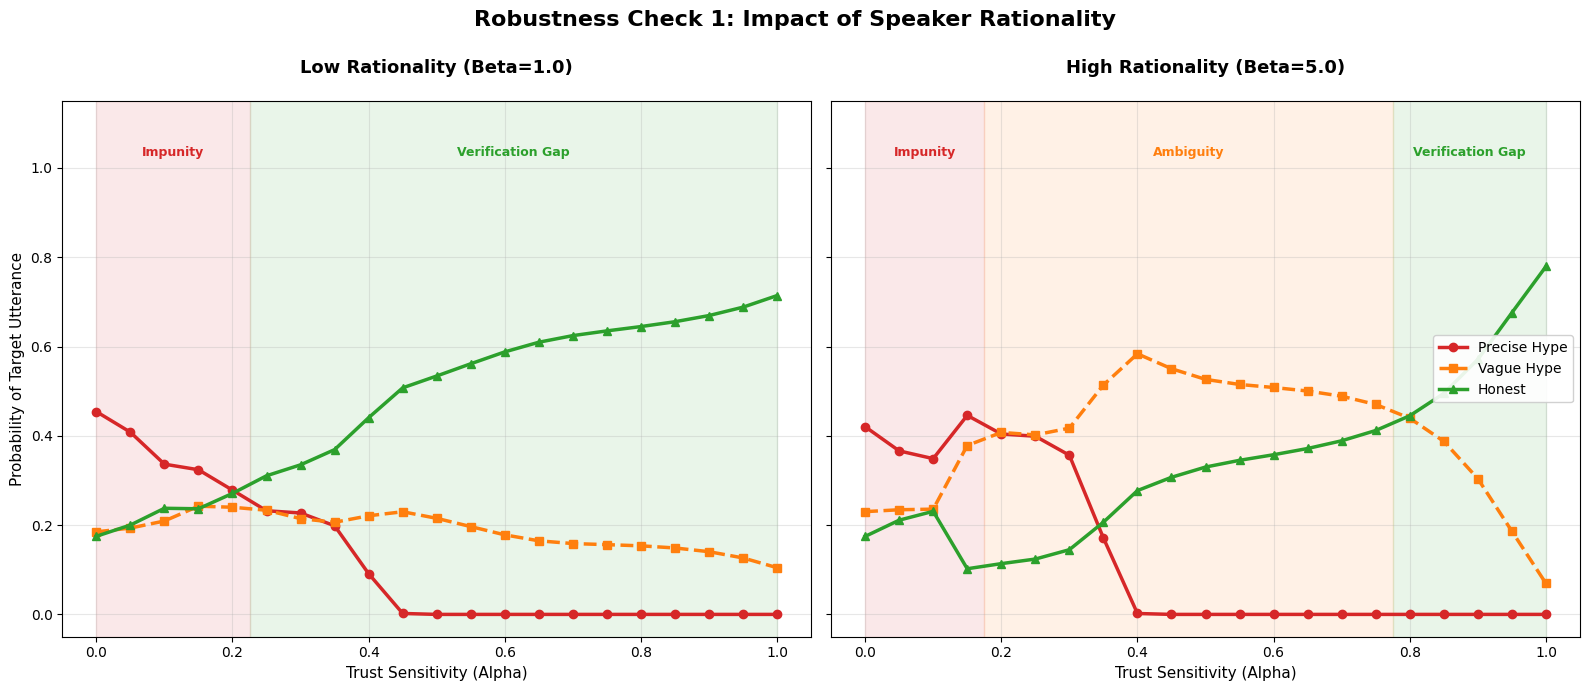


--- TEST 2: Prior Check ---
Running Sweep: Beta_S=3.0, Prior_Var=1.0, Var_Gap=[2.0, 5.0]...
Running Sweep: Beta_S=3.0, Prior_Var=5.0, Var_Gap=[2.0, 5.0]...


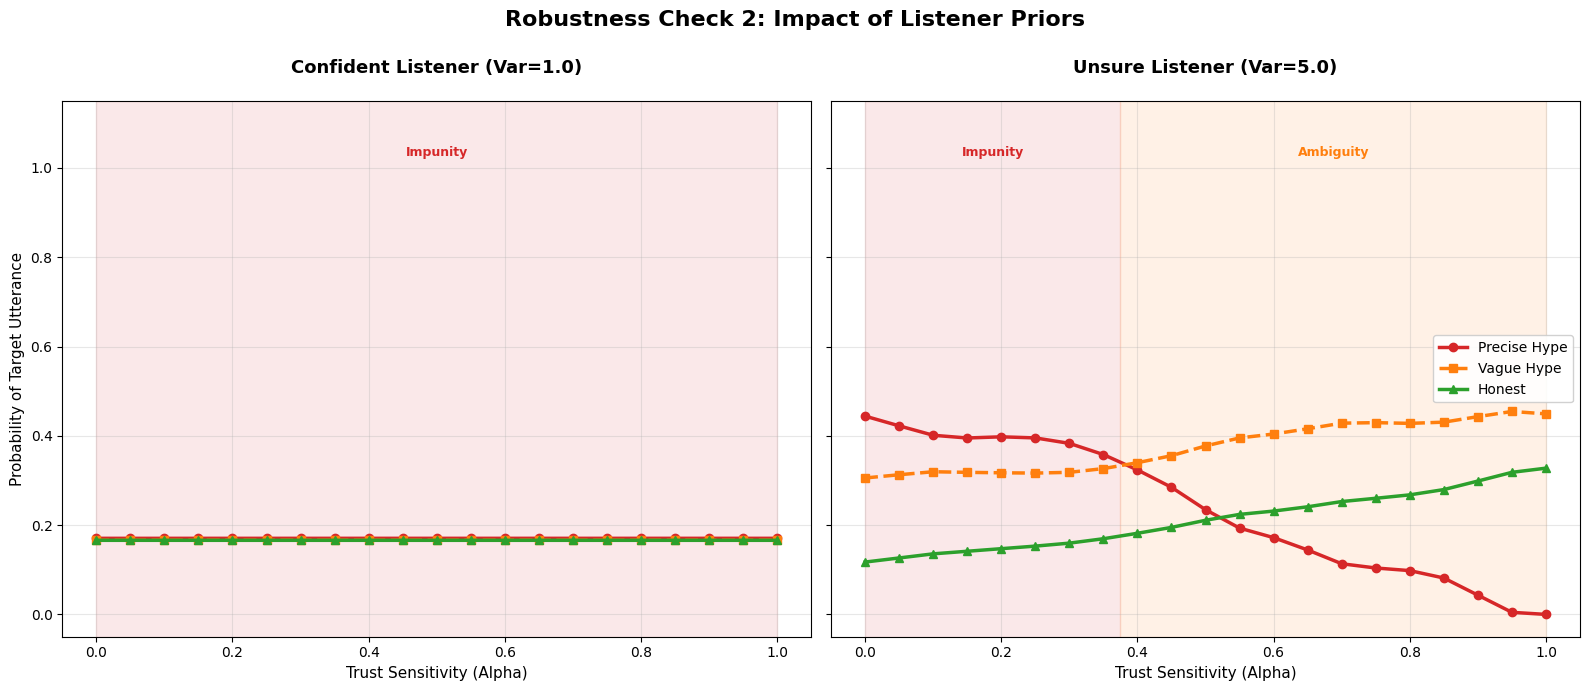


--- TEST 3: Variance Gap Check ---
Running Sweep: Beta_S=3.0, Prior_Var=3.0, Var_Gap=[2.0, 2.25]...
Running Sweep: Beta_S=3.0, Prior_Var=3.0, Var_Gap=[2.0, 2.75]...


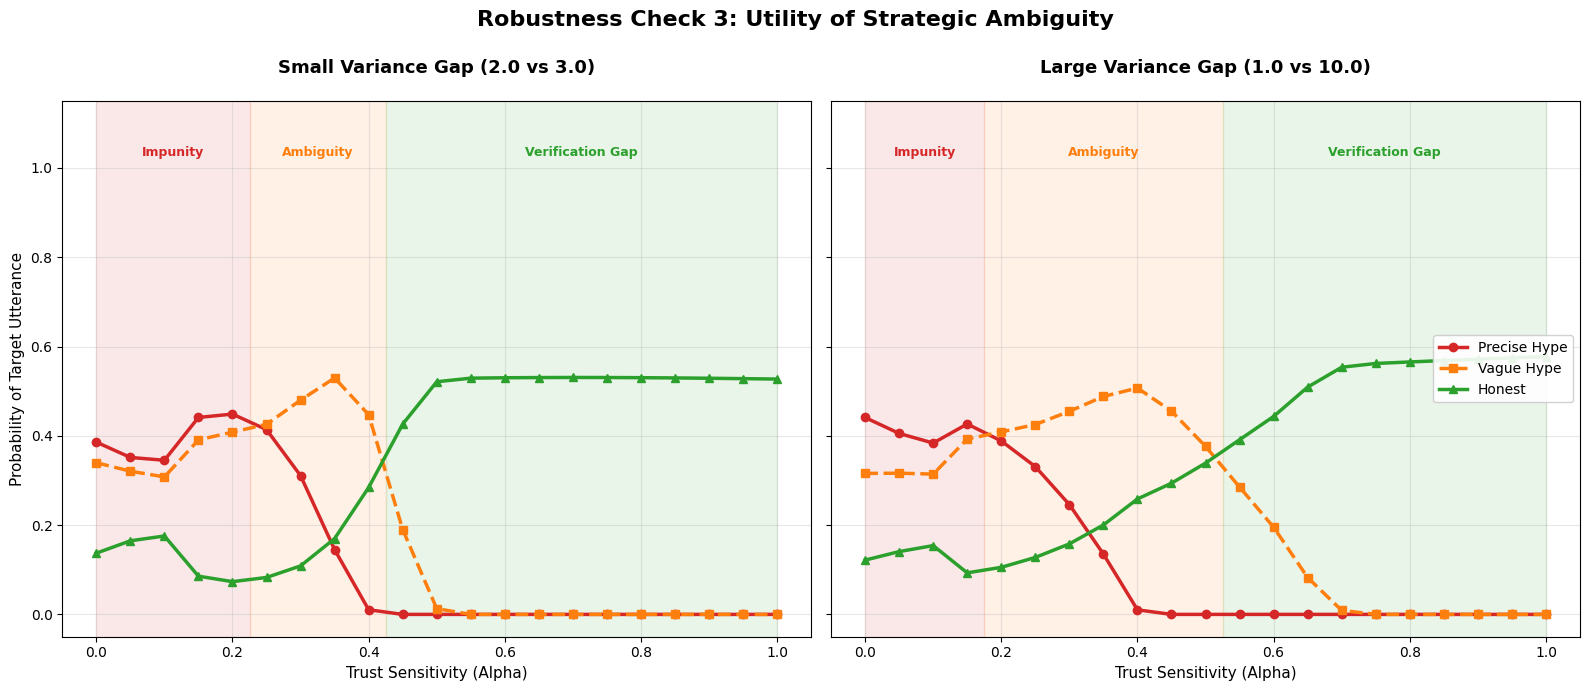

In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import itertools

# --- ASSUMPTION: Your 'RollingHorizonSpeaker' class is already defined in the notebook ---

# ==========================================
# 1. BASELINE SETTINGS (The "Standard" Model)
# ==========================================
# We keep START_TRUST = 0.5 as discussed (Neutral Prior)
START_TRUST = 0.5

BASE_PARAMS = {
    'horizon_strat': 2,
    'gamma': 0.0,
    'beta_s': 3.0,          # Standard Rationality
    'beta_l': 3.0,
    'prior_means': [0.0, 5.0],
    'prior_vars': [3.0, 3.0], # Standard Uncertainty
    'msg_means': [-5.0, 0.0, 5.0],
    'msg_vars': [2.0, 5.0],   # Standard Variance Gap
    'curr_inc': [10.0, -10.0],
    'fut_inc': [100.0, 0.0],  # The "Trap"
    'curr_truth': [0.0, 5.0],
    'fut_truth': [0.0, 5.0]
}

# ==========================================
# 2. RIGOROUS SWEEP ENGINE
# ==========================================
def run_alpha_sweep(params):
    """
    Runs the alpha sweep for a specific set of parameters.
    Constructs the full look-ahead buffer for H=2 planning at every step.
    """
    alpha_values = np.arange(0.0, 1.05, 0.05)
    
    # Storage for the 3 key strategies
    res = {
        "alphas": alpha_values,
        "hype_precise": [], # Target µ=5, Low Var
        "hype_vague":   [], # Target µ=5, High Var
        "honest":       []  # Target µ=0, Low Var
    }
    
    # Identify the specific variance values used in this run for classification
    # Assumes params['msg_vars'] is [Low, High]
    low_var_val = params['msg_vars'][0]
    high_var_val = params['msg_vars'][1]

    print(f"Running Sweep: Beta_S={params['beta_s']}, Prior_Var={params['prior_vars'][0]}, Var_Gap={params['msg_vars']}...")

    for alpha in alpha_values:
        # -------------------------------------------------------
        # 1. Full Environment Construction (No Simplification)
        # -------------------------------------------------------
        # We construct the observation sequences for t=0 (Current) and t=1..H (Future)
        # The agent needs at least H steps of future data to plan.
        
        obs_L = []
        obs_S_truth = []
        obs_S_inc = []
        
        # Step 0: Current State (Incentive: 10 vs -10)
        obs_L.append([(m, v) for m, v in zip(params['prior_means'], params['prior_vars'])])
        obs_S_truth.append([(v, 0.1) for v in params['curr_truth']])
        obs_S_inc.append([(v, 0.1) for v in params['curr_inc']])
        
        # Steps 1 to H+1: Future State (Incentive: 100 vs 0)
        # We add a few extra steps to ensure the horizon buffer is never empty
        for _ in range(params['horizon_strat'] + 1): 
            obs_L.append([(m, v) for m, v in zip(params['prior_means'], params['prior_vars'])]) 
            obs_S_truth.append([(v, 0.1) for v in params['fut_truth']])
            obs_S_inc.append([(v, 0.1) for v in params['fut_inc']])

        # -------------------------------------------------------
        # 2. Agent Instantiation & Policy Calculation
        # -------------------------------------------------------
        agent = RollingHorizonSpeaker(
            num_arms=2, 
            horizon=params['horizon_strat'], 
            gamma_honesty=params['gamma'], 
            alpha_trust=alpha, 
            beta_speaker=params['beta_s'], 
            beta_listener=params['beta_l'],
            msg_means=params['msg_means'], 
            msg_vars=params['msg_vars']
        )
        
        # Calculate the Policy at t=0 given the full future context
        space, probs = agent.get_policy_distribution(START_TRUST, obs_L, obs_S_truth, obs_S_inc)
        
        # -------------------------------------------------------
        # 3. Precise Probability Aggregation
        # -------------------------------------------------------
        # We sum probabilities for the specific strategies we care about.
        
        p_precise = 0.0
        p_vague = 0.0
        p_honest = 0.0
        
        for k, u in enumerate(space):
            u_t = u[0] # The message sent about the Target Arm (Arm 0)
            
            # Check Semantics (Are we lying or telling the truth?)
            is_target_good = (abs(u_t[0] - 5.0) < 0.1) # Lying (Hype)
            is_target_bad  = (abs(u_t[0] - 0.0) < 0.1) # Honest
            
            # Check Precision (Are we Precise or Vague?)
            is_low_var  = (abs(u_t[1] - low_var_val) < 0.1)
            is_high_var = (abs(u_t[1] - high_var_val) < 0.1)
            
            if is_target_good and is_low_var: p_precise += probs[k]
            if is_target_good and is_high_var: p_vague += probs[k]
            if is_target_bad and is_low_var: p_honest += probs[k]
            
        res['hype_precise'].append(p_precise)
        res['hype_vague'].append(p_vague)
        res['honest'].append(p_honest)
        
    return res
import numpy as np
import matplotlib.pyplot as plt

def identify_phases(alphas, precise, vague, honest):
    """
    Scans the probability arrays to identify continuous phases where one strategy dominates.
    Returns a list of phase dictionaries:
    [{'start': 0.0, 'end': 0.35, 'color': '...', 'label': '...'}]
    """
    phases = []
    
    # 0 = Precise, 1 = Vague, 2 = Honest, 3 = Tie
    # We use a small epsilon for float comparison to detect ties
    epsilon = 1e-3
    dom_indices = []
    
    for p, v, h in zip(precise, vague, honest):
        probs = [p, v, h]
        max_p = max(probs)
        
        # Check for ties (multiple strategies close to max)
        winners = [i for i, val in enumerate(probs) if abs(val - max_p) < epsilon]
        
        if len(winners) > 1:
            dom_indices.append(3) # Tie
        else:
            dom_indices.append(winners[0])
            
    # Group continuous segments
    current_phase_idx = dom_indices[0]
    start_alpha = alphas[0]
    
    # Colors and Labels map
    phase_meta = {
        0: {'color': '#d62728', 'label': 'Impunity'},         # Red
        1: {'color': '#ff7f0e', 'label': 'Ambiguity'},        # Orange
        2: {'color': '#2ca02c', 'label': 'Verification Gap'}, # Green
        3: {'color': '#7f7f7f', 'label': 'Transition/Tie'}    # Gray
    }
    
    for i in range(1, len(alphas)):
        # If strategy changes, close the previous phase and start new one
        if dom_indices[i] != current_phase_idx:
            # End of previous phase is the midpoint between previous alpha and current alpha
            # (Visual smoothing)
            midpoint = (alphas[i-1] + alphas[i]) / 2.0
            
            phases.append({
                'start': start_alpha,
                'end': midpoint,
                'color': phase_meta[current_phase_idx]['color'],
                'label': phase_meta[current_phase_idx]['label'],
                'type': current_phase_idx
            })
            
            # Start new phase
            start_alpha = midpoint
            current_phase_idx = dom_indices[i]
            
    # Append the final phase
    phases.append({
        'start': start_alpha,
        'end': alphas[-1],
        'color': phase_meta[current_phase_idx]['color'],
        'label': phase_meta[current_phase_idx]['label'],
        'type': current_phase_idx
    })
    
    return phases

def plot_comparison(res1, label1, res2, label2, title):
    """Plots two results side-by-side with dynamic phase coloring."""
    fig, axes = plt.subplots(1, 2, figsize=(16, 7), sharey=True)
    
    datasets = [(res1, label1, axes[0]), (res2, label2, axes[1])]
    
    for res, lbl, ax in datasets:
        # Unpack data
        x = np.array(res['alphas'])
        y_pre = np.array(res['hype_precise'])
        y_vag = np.array(res['hype_vague'])
        y_hon = np.array(res['honest'])

        # 1. Identify Phases
        phases = identify_phases(x, y_pre, y_vag, y_hon)
        
        # 2. Draw Colored Backgrounds & Labels
        for p in phases:
            # Draw the shaded region
            ax.axvspan(p['start'], p['end'], color=p['color'], alpha=0.1, zorder=0)
            
            # Add Label (Only if phase is wide enough to fit text)
            width = p['end'] - p['start']
            if width > 0.1 and p['type'] != 3: # Don't label tiny segments or ties
                mid = (p['start'] + p['end']) / 2
                ax.text(mid, 1.02, p['label'], 
                        ha='center', va='bottom', fontsize=9, 
                        fontweight='bold', color=p['color'])

        # 3. Plot Data Lines
        ax.plot(x, y_pre, label="Precise Hype", marker='o', color='#d62728', lw=2.5, zorder=3)
        ax.plot(x, y_vag, label="Vague Hype",   marker='s', color='#ff7f0e', lw=2.5, ls='--', zorder=3)
        ax.plot(x, y_hon, label="Honest",       marker='^', color='#2ca02c', lw=2.5, zorder=3)
        
        # Formatting
        ax.set_title(lbl, fontsize=13, fontweight='bold', pad=20) # Pad for labels
        ax.set_xlabel("Trust Sensitivity (Alpha)", fontsize=11)
        ax.set_xticks(np.arange(0, 1.1, 0.2))
        ax.set_ylim(-0.05, 1.15) # Consistent Y-axis with room for labels
        ax.grid(True, alpha=0.3)
        
        if ax == axes[0]: 
            ax.set_ylabel("Probability of Target Utterance", fontsize=11)
    
    # Legend on the second plot
    axes[1].legend(loc='center right', framealpha=0.9, fontsize=10)
    
    plt.suptitle(title, fontsize=16, y=0.98, fontweight='bold')
    plt.tight_layout()
    plt.subplots_adjust(top=0.85) # Adjust layout to prevent title overlap
    plt.show()

# ==========================================
# 3. EXECUTE THE 3 ROBUSTNESS CHECKS
# ==========================================

# --- CHECK 1: Rationality (Speaker Beta) ---
print("\n--- TEST 1: Rationality Check ---")
params_low_beta = BASE_PARAMS.copy()
params_low_beta['beta_s'] = 1.0  # Noisy/Random Speaker

params_high_beta = BASE_PARAMS.copy()
params_high_beta['beta_s'] = 5.0 # Very Strategic/Greedy Speaker

res_beta_low  = run_alpha_sweep(params_low_beta)
res_beta_high = run_alpha_sweep(params_high_beta)

plot_comparison(res_beta_low, "Low Rationality (Beta=1.0)", 
                res_beta_high, "High Rationality (Beta=5.0)", 
                "Robustness Check 1: Impact of Speaker Rationality")

# --- CHECK 2: Epistemic Vigilance (Prior Confidence) ---
print("\n--- TEST 2: Prior Check ---")
params_conf = BASE_PARAMS.copy()
params_conf['prior_vars'] = [1.0, 1.0] # Skeptical/Confident Listener

params_unsure = BASE_PARAMS.copy()
params_unsure['prior_vars'] = [5.0, 5.0] # Gullible/Unsure Listener

res_conf   = run_alpha_sweep(params_conf)
res_unsure = run_alpha_sweep(params_unsure)

plot_comparison(res_conf, "Confident Listener (Var=1.0)", 
                res_unsure, "Unsure Listener (Var=5.0)", 
                "Robustness Check 2: Impact of Listener Priors")

# --- CHECK 3: Variance Gap (Strategic Ambiguity Opportunity) ---
print("\n--- TEST 3: Variance Gap Check ---")
params_small_gap = BASE_PARAMS.copy()
params_small_gap['msg_vars'] = [2.0, 2.25] # Vagueness offers little safety

params_huge_gap = BASE_PARAMS.copy()
params_huge_gap['msg_vars'] = [2.0, 2.75] # Vagueness offers huge safety

res_small = run_alpha_sweep(params_small_gap)
res_huge  = run_alpha_sweep(params_huge_gap)

plot_comparison(res_small, "Small Variance Gap (2.0 vs 3.0)", 
                res_huge, "Large Variance Gap (1.0 vs 10.0)", 
                "Robustness Check 3: Utility of Strategic Ambiguity")


--- TEST 1: Rationality ---


UnboundLocalError: cannot access local variable 'current_phase_idx' where it is not associated with a value

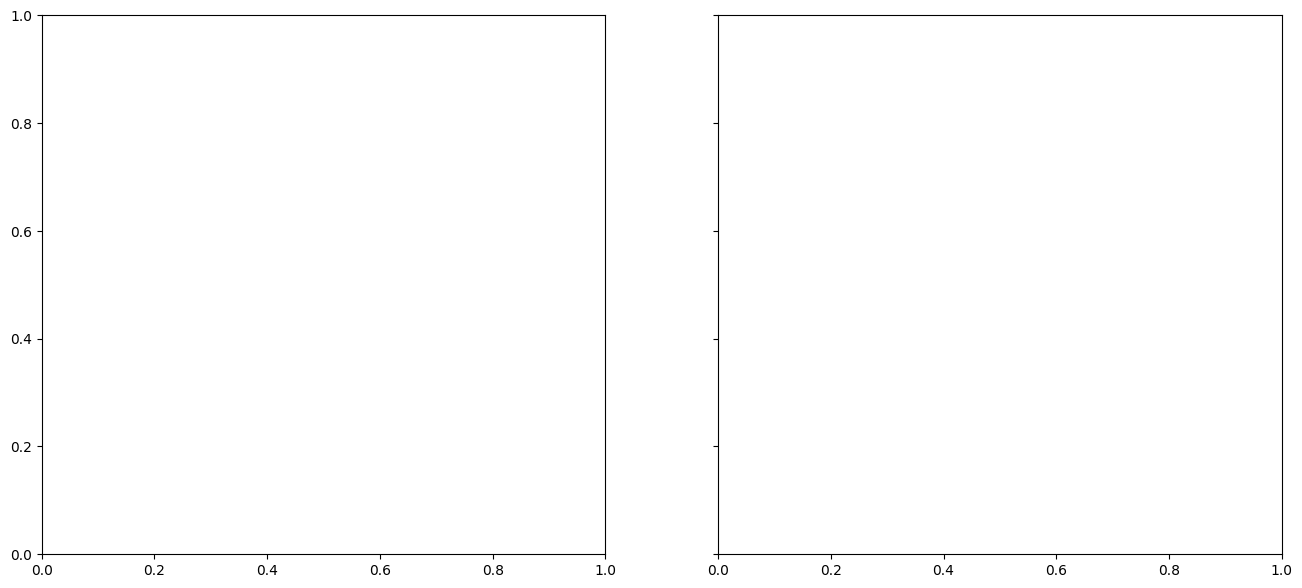

In [32]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import itertools

# --- ASSUMPTION: Your 'RollingHorizonSpeaker' class is already defined ---

START_TRUST = 0.5

BASE_PARAMS = {
    'horizon_strat': 2,
    'gamma': 0.0,
    'beta_s': 3.0,
    'beta_l': 3.0,
    'prior_means': [0.0, 5.0],
    'prior_vars': [3.0, 3.0],
    'msg_means': [-5.0, 0.0, 5.0],
    'msg_vars': [2.0, 5.0],
    'curr_inc': [10.0, -10.0],
    'fut_inc': [100.0, 0.0],
    'curr_truth': [0.0, 5.0],
    'fut_truth': [0.0, 5.0]
}

def run_alpha_sweep(params, alpha_steps=21):
    """
    Update the signature to accept alpha_steps.
    """
    # Use linspace to ensure exactly the number of steps requested
    alpha_values = np.linspace(0.0, 1.0, alpha_steps)
    
    res = {
        "alphas": alpha_values,
        "hype_precise": [],
        "hype_vague": [],
        "honest": [],
        "diagnostic_residuals": [],
        "params": params.copy()
    }
    
    # ... rest of your existing simulation code ...
    # (Ensure you are iterating over alpha_values)
    
    low_var_val = params['msg_vars'][0]
    high_var_val = params['msg_vars'][1]

    for alpha in alpha_values:
        # Construct Environment
        obs_L, obs_S_truth, obs_S_inc = [], [], []
        obs_L.append([(m, v) for m, v in zip(params['prior_means'], params['prior_vars'])])
        obs_S_truth.append([(v, 0.1) for v in params['curr_truth']])
        obs_S_inc.append([(v, 0.1) for v in params['curr_inc']])
        
        for _ in range(params['horizon_strat'] + 1): 
            obs_L.append([(m, v) for m, v in zip(params['prior_means'], params['prior_vars'])]) 
            obs_S_truth.append([(v, 0.1) for v in params['fut_truth']])
            obs_S_inc.append([(v, 0.1) for v in params['fut_inc']])

        agent = RollingHorizonSpeaker(
            num_arms=2, horizon=params['horizon_strat'], 
            gamma_honesty=params['gamma'], alpha_trust=alpha, 
            beta_speaker=params['beta_s'], beta_listener=params['beta_l'],
            msg_means=params['msg_means'], msg_vars=params['msg_vars']
        )
        
        space, probs = agent.get_policy_distribution(START_TRUST, obs_L, obs_S_truth, obs_S_inc)
        
        p_precise, p_vague, p_honest, p_other = 0.0, 0.0, 0.0, 0.0
        
        for k, u in enumerate(space):
            u_t = u[0] # Target Arm Message
            prob = probs[k]
            
            is_hype = (abs(u_t[0] - 5.0) < 0.1)
            is_honest = (abs(u_t[0] - 0.0) < 0.1)
            is_low_var = (abs(u_t[1] - low_var_val) < 0.1)
            is_high_var = (abs(u_t[1] - high_var_val) < 0.1)
            
            if is_hype and is_low_var: p_precise += prob
            elif is_hype and is_high_var: p_vague += prob
            elif is_honest and is_low_var: p_honest += prob
            else: p_other += prob # Diagnostic residual (vague honesty or sabotage)
            
        res['hype_precise'].append(p_precise)
        res['hype_vague'].append(p_vague)
        res['honest'].append(p_honest)
        res['diagnostic_residuals'].append(p_other)
        
    return res

def identify_phases(alphas, precise, vague, honest, residuals):
    """
    Scans probabilities including residuals to identify the dominant strategy.
    """
    phases = []
    epsilon = 1e-2 
    dom_indices = []
    
    # We now track 4 potential 'winners'
    for p, v, h, r in zip(precise, vague, honest, residuals):
        probs = [p, v, h, r]
        max_p = max(probs)
        
        # Check for ties
        winners = [idx for idx, val in enumerate(probs) if abs(val - max_p) < epsilon]
        
        if len(winners) > 1:
            dom_indices.append(4) # Tie
        else:
            dom_indices.append(winners[0]) # 0:Precise, 1:Vague, 2:Honest, 3:Residuals
            
    # Meta-data for the 5 possible states
    phase_meta = {
        0: {'color': '#e35f62', 'label': 'Phase 1: Impunity'},
        1: {'color': '#fb9a35', 'label': 'Phase 2: Strategic Ambiguity'},
        2: {'color': '#58b368', 'label': 'Phase 3: Verification Gap'},
        3: {'color': '#9b59b6', 'label': 'Other/Complex Strategy'}, # Purple for Residuals
        4: {'color': '#bdc3c7', 'label': 'No Dominating Strategy'}  # Gray for Ties
    }
    
    for i in range(1, len(alphas)):
        if dom_indices[i] != current_phase_idx:
            midpoint = (alphas[i-1] + alphas[i]) / 2.0
            phases.append({
                'start': start_alpha, 'end': midpoint,
                'color': phase_meta[current_phase_idx]['color'],
                'label': phase_meta[current_phase_idx]['label'],
                'type': current_phase_idx
            })
            start_alpha = midpoint
            current_phase_idx = dom_indices[i]
            
    phases.append({
        'start': start_alpha, 'end': alphas[-1],
        'color': phase_meta[current_phase_idx]['color'],
        'label': phase_meta[current_phase_idx]['label'],
        'type': current_phase_idx
    })
    return phases

def plot_comparison(res1, label1, res2, label2, title):
    fig, axes = plt.subplots(1, 2, figsize=(16, 7), sharey=True)
    datasets = [(res1, label1, axes[0]), (res2, label2, axes[1])]
    
    for res, lbl, ax in datasets:
        x = np.array(res['alphas'])
        y_pre, y_vag, y_hon = np.array(res['hype_precise']), np.array(res['hype_vague']), np.array(res['honest'])
        y_res = np.array(res['diagnostic_residuals'])

        phases = identify_phases(x, y_pre, y_vag, y_hon, y_res)
        for p in phases:
            ax.axvspan(p['start'], p['end'], color=p['color'], alpha=0.1, zorder=0)
            width = p['end'] - p['start']
            if width > 0.08: # Min width to draw text
                mid = (p['start'] + p['end']) / 2
                ax.text(mid, 1.05, p['label'], ha='center', va='bottom', fontsize=8, fontweight='bold', color=p['color'])

        ax.plot(x, y_pre, label="Precise Hype", marker='o', color='#d62728', lw=2.5, zorder=3)
        ax.plot(x, y_vag, label="Vague Hype",   marker='s', color='#ff7f0e', lw=2.5, ls='--', zorder=3)
        ax.plot(x, y_hon, label="Honest",       marker='^', color='#2ca02c', lw=2.5, zorder=3)
        ax.plot(x, y_res, label="Other (Diagnostic)", color='black', lw=1, ls=':', alpha=0.5, zorder=2)
        
        # Dynamic subtitle with specific parameter changes
        msg_vars = res['params']['msg_vars']
        ax.set_title(f"{lbl}\n$\sigma^2 \in$ {msg_vars}", fontsize=11, fontweight='bold', pad=25)
        ax.set_xlabel("Trust Sensitivity (Alpha)")
        ax.set_xticks(np.arange(0, 1.1, 0.2))
        ax.set_ylim(-0.05, 1.2)
        ax.grid(True, alpha=0.3)
        if ax == axes[0]: ax.set_ylabel("Probability of Target Utterance")
    
    axes[1].legend(loc='upper right', framealpha=0.9, fontsize=9)
    plt.suptitle(title, fontsize=16, y=0.98, fontweight='bold')
    plt.tight_layout()
    plt.subplots_adjust(top=0.82)
    plt.show()

# ==========================================
# RUNNING REFINED EXPERIMENTS
# ==========================================

print("\n--- TEST 1: Rationality ---")
p1_low_beta = run_alpha_sweep({**BASE_PARAMS, 'beta_s': 1.0})
p1_high_beta = run_alpha_sweep({**BASE_PARAMS, 'beta_s': 5.0})
plot_comparison(p1_low_beta, "Low Rationality (Beta=1.0)", p1_high_beta, "High Rationality (Beta=5.0)", "Robustness Check: Speaker Rationality")

print("\n--- TEST 2: Priors ---")
p2_conf = run_alpha_sweep({**BASE_PARAMS, 'prior_vars': [1.0, 1.0]})
p2_unsure = run_alpha_sweep({**BASE_PARAMS, 'prior_vars': [5.0, 5.0]})
plot_comparison(p2_conf, "Confident Listener", p2_unsure, "Unsure Listener", "Robustness Check: Impact of Listener Priors")

print("\n--- TEST 3: Variance Gap ---")
p3_small = run_alpha_sweep({**BASE_PARAMS, 'msg_vars': [2.0, 2.25]})
p3_large = run_alpha_sweep({**BASE_PARAMS, 'msg_vars': [2.0, 2.75]}) # Adjusted for visual clarity
plot_comparison(p3_small, "Small Variance Gap", p3_large, "Large Variance Gap", "Robustness Check: Utility of Strategic Ambiguity (utterances are more precise than listener prior)")

print("\n--- TEST 4: Variance Gap With Less Precise Utterances ---")
p3_small = run_alpha_sweep({**BASE_PARAMS, 'msg_vars': [2.0, 3.00]})
p3_large = run_alpha_sweep({**BASE_PARAMS, 'msg_vars': [2.0, 4.00]}) # Adjusted for visual clarity
plot_comparison(p3_small, "Small Variance Gap", p3_large, "Large Variance Gap", "Robustness Check: Utility of Strategic Ambiguity (utterances are less precise than listener prior)")

In [36]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import matplotlib.patches as mpatches

# ==========================================
# 1. THE STRATEGY MAP ENGINE
# ==========================================
import time

def generate_strategy_map(param_name, param_range, alpha_steps=40):
    """
    Generates a 2D grid of dominating strategies with synchronized alpha steps 
    and detailed progress logging.
    """
    alphas = np.linspace(0.0, 1.0, alpha_steps)
    num_params = len(param_range)
    grid = np.zeros((num_params, alpha_steps))
    
    # Define strategy mapping: 0:Precise Hype, 1:Vague Hype, 2:Honest, 3:Tie/Other
    epsilon = 1e-2 

    print(f"🚀 Starting Strategy Map Sweep for: {param_name}")
    print(f"📊 Grid Size: {num_params} ({param_name}) x {alpha_steps} (Alpha)")
    print(f"📝 Total Simulations: {num_params * alpha_steps}")
    print("-" * 50)

    start_time = time.time()

    for i, p_val in enumerate(param_range):
        row_start_time = time.time()
        
        # 1. Update parameters for this row
        current_params = BASE_PARAMS.copy()
        current_params[param_name] = p_val
        
        # 2. Run sweep for this row (Passing alpha_steps to keep indices aligned)
        # Ensure your run_alpha_sweep function uses alpha_steps as an argument!
        res = run_alpha_sweep(current_params, alpha_steps=alpha_steps)
        
        # 3. Classify dominating strategies
        for j in range(alpha_steps):
            probs = [res['hype_precise'][j], res['hype_vague'][j], res['honest'][j], res['diagnostic_residuals'][j]]
            max_p = max(probs)
            winners = [idx for idx, val in enumerate(probs) if abs(val - max_p) < epsilon]
            
            if len(winners) > 1:
                grid[i, j] = 4 # No Dominating Strategy (Tie)
            else:
                grid[i, j] = winners[0]
        
        # 4. Progress Logging (The Fix)
        elapsed = time.time() - start_time
        avg_time_per_row = elapsed / (i + 1)
        remaining_rows = num_params - (i + 1)
        est_remaining = remaining_rows * avg_time_per_row
        
        # Check if p_val is a list or single number for pretty printing
        display_val = p_val[0] if isinstance(p_val, list) else p_val
        
        print(f"✅ Row {i+1}/{num_params} completed | {param_name} ≈ {display_val:.2f}")
        print(f"   ⏱️ Row Time: {time.time() - row_start_time:.2f}s | Est. Remaining: {est_remaining/60:.1f} min")
        print("-" * 30)
                
    total_time = time.time() - start_time
    print(f"✨ Sweep Complete! Total Time: {total_time/60:.1f} minutes")
    
    return alphas, param_range, grid

# ==========================================
# 2. RUNNING THE RATIONALITY SWEEP
# ==========================================
# 20x20 is a good start, but let's do 30x30 for "paper-ready" fidelity
#beta_range = np.linspace(1.0, 10.0, 30)
#alphas, betas, strategy_grid = generate_strategy_map('beta_s', beta_range, alpha_steps=40)

# ==========================================
# 3. VISUALIZATION
# ==========================================
def plot_strategy_map(alphas, y_range, grid, y_label, title):
    plt.figure(figsize=(10, 8))
    
    # Define the discrete colors matching your line plots
    # Red: Impunity, Orange: Ambiguity, Green: Verification Gap, Gray: Tie
    cmap = ListedColormap(['#d62728', '#ff7f0e', '#2ca02c', '#7f7f7f'])
    
    # Plot using pcolormesh for sharp boundaries
    im = plt.pcolormesh(alphas, y_range, grid, cmap=cmap, shading='auto', edgecolors='none')
    
    # Formatting
    plt.title(title, fontsize=15, fontweight='bold', pad=20)
    plt.xlabel(r"Trust Sensitivity ($\alpha$)", fontsize=12)
    plt.ylabel(y_label, fontsize=12)
    
    # Custom Legend
    labels = ["Phase 1: Impunity (Precise Hype)", 
              "Phase 2: Ambiguity (Vague Hype)", 
              "Phase 3: Verification Gap (Honest)", 
              "Other/Complex Strategy",
              "No Dominating Strategy"]
    patches = [mpatches.Patch(color=cmap.colors[i], label=labels[i]) for i in range(len(labels))]
    plt.legend(handles=patches, bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)

    plt.grid(False) # Turn off standard grid for heatmaps
    plt.tight_layout()
    plt.show()

# plot_strategy_map(alphas, betas, strategy_grid, 
#                   y_label=r"Speaker Rationality ($\beta_S$)", 
#                   title="Strategic Dominance Map: Impact of Speaker Rationality")

🚀 Starting Strategy Map Sweep for: beta_s
📊 Grid Size: 20 (beta_s) x 20 (Alpha)
📝 Total Simulations: 400
--------------------------------------------------
✅ Row 1/20 completed | beta_s ≈ 1.00
   ⏱️ Row Time: 1.92s | Est. Remaining: 0.6 min
------------------------------
✅ Row 2/20 completed | beta_s ≈ 1.47
   ⏱️ Row Time: 1.85s | Est. Remaining: 0.6 min
------------------------------
✅ Row 3/20 completed | beta_s ≈ 1.95
   ⏱️ Row Time: 1.85s | Est. Remaining: 0.5 min
------------------------------
✅ Row 4/20 completed | beta_s ≈ 2.42
   ⏱️ Row Time: 1.90s | Est. Remaining: 0.5 min
------------------------------
✅ Row 5/20 completed | beta_s ≈ 2.89
   ⏱️ Row Time: 1.92s | Est. Remaining: 0.5 min
------------------------------
✅ Row 6/20 completed | beta_s ≈ 3.37
   ⏱️ Row Time: 1.85s | Est. Remaining: 0.4 min
------------------------------
✅ Row 7/20 completed | beta_s ≈ 3.84
   ⏱️ Row Time: 1.90s | Est. Remaining: 0.4 min
------------------------------
✅ Row 8/20 completed | beta_s ≈ 

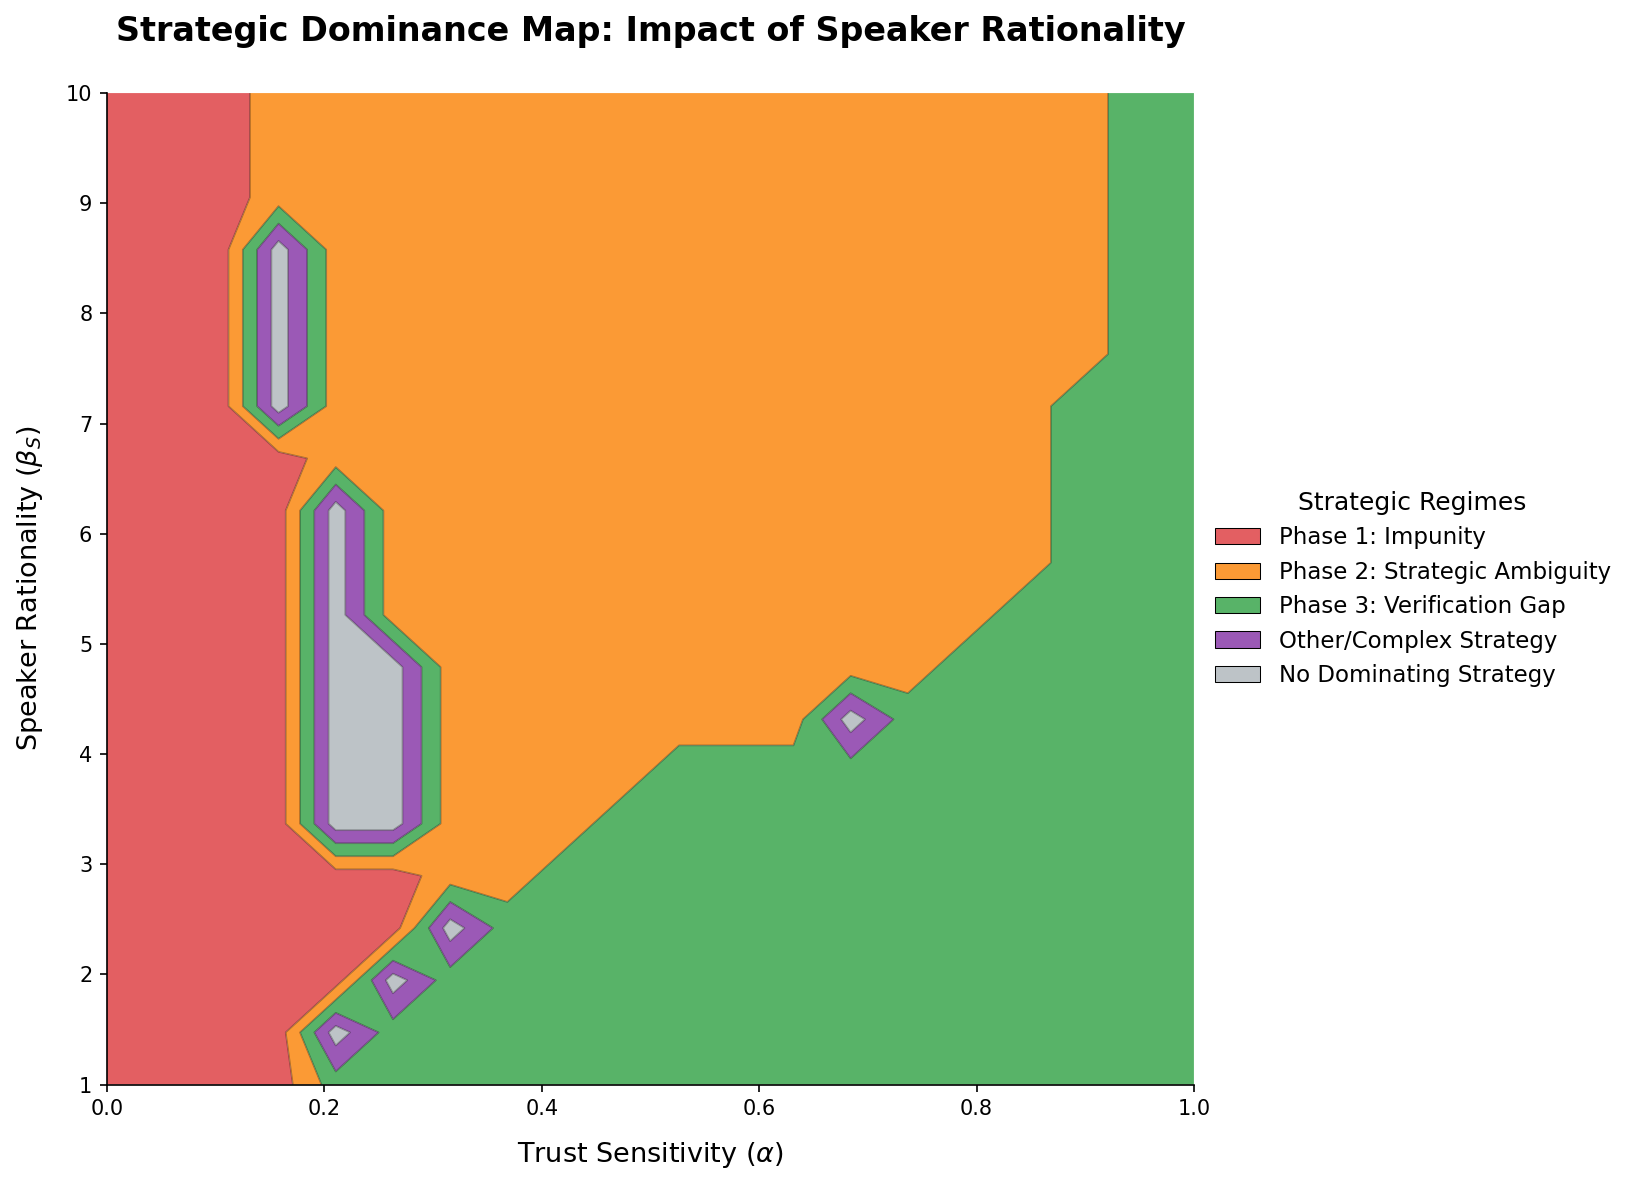

In [37]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import matplotlib.patches as mpatches

def plot_beautiful_strategy_map(alphas, y_range, grid, y_label, title):
    X, Y = np.meshgrid(alphas, y_range)
    plt.figure(figsize=(11, 8), dpi=150)
    
    # 0:Red, 1:Orange, 2:Green, 3:Purple (Other), 4:Gray (Tie)
    colors = ['#e35f62', '#fb9a35', '#58b368', '#9b59b6', '#bdc3c7']
    cmap = ListedColormap(colors)

    # levels adjusted to catch indices 0, 1, 2, 3, 4
    ctf = plt.contourf(X, Y, grid, levels=[-0.5, 0.5, 1.5, 2.5, 3.5, 4.5], 
                       colors=colors, antialiased=True)
    
    # Add thin black lines at the boundaries for professional contrast
    plt.contour(X, Y, grid, levels=[0.5, 1.5, 2.5, 3.5], 
                colors='black', linewidths=0.8, alpha=0.3)

    plt.title(title, fontsize=16, fontweight='bold', pad=25)
    plt.xlabel(r"Trust Sensitivity ($\alpha$)", fontsize=13, labelpad=10)
    plt.ylabel(y_label, fontsize=13, labelpad=10)

    ax = plt.gca()
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    plt.xticks(np.arange(0, 1.1, 0.2))
    
    labels = ["Phase 1: Impunity", 
              "Phase 2: Strategic Ambiguity", 
              "Phase 3: Verification Gap", 
              "Other/Complex Strategy",
              "No Dominating Strategy"]
    
    patches = [mpatches.Patch(color=colors[i], label=labels[i], ec='black', lw=0.5) for i in range(len(labels))]
    
    plt.legend(handles=patches, loc='center left', bbox_to_anchor=(1, 0.5), 
               frameon=False, fontsize=11, title="Strategic Regimes", title_fontsize=12)

    plt.tight_layout()
    plt.show()

# --- HOW TO RUN ---
# 1. Increase fidelity: Use 50x50 or 60x60 for smooth curves
beta_range = np.linspace(1.0, 10.0, 20)
alphas, betas, strategy_grid = generate_strategy_map('beta_s', beta_range, alpha_steps=20)
plot_beautiful_strategy_map(alphas, betas, strategy_grid, 
                  y_label=r"Speaker Rationality ($\beta_S$)", 
                  title="Strategic Dominance Map: Impact of Speaker Rationality")


--- RUNNING EPISTEMIC ENVIRONMENT SWEEP ---
🚀 Starting Strategy Map Sweep for: prior_vars
📊 Grid Size: 60 (prior_vars) x 60 (Alpha)
📝 Total Simulations: 3600
--------------------------------------------------
✅ Row 1/60 completed | prior_vars ≈ 1.00
   ⏱️ Row Time: 4.30s | Est. Remaining: 4.2 min
------------------------------
✅ Row 2/60 completed | prior_vars ≈ 1.15
   ⏱️ Row Time: 4.34s | Est. Remaining: 4.2 min
------------------------------
✅ Row 3/60 completed | prior_vars ≈ 1.31
   ⏱️ Row Time: 4.70s | Est. Remaining: 4.2 min
------------------------------
✅ Row 4/60 completed | prior_vars ≈ 1.46
   ⏱️ Row Time: 4.79s | Est. Remaining: 4.2 min
------------------------------
✅ Row 5/60 completed | prior_vars ≈ 1.61
   ⏱️ Row Time: 4.97s | Est. Remaining: 4.2 min
------------------------------
✅ Row 6/60 completed | prior_vars ≈ 1.76
   ⏱️ Row Time: 5.15s | Est. Remaining: 4.2 min
------------------------------
✅ Row 7/60 completed | prior_vars ≈ 1.92
   ⏱️ Row Time: 5.14s | Est. 

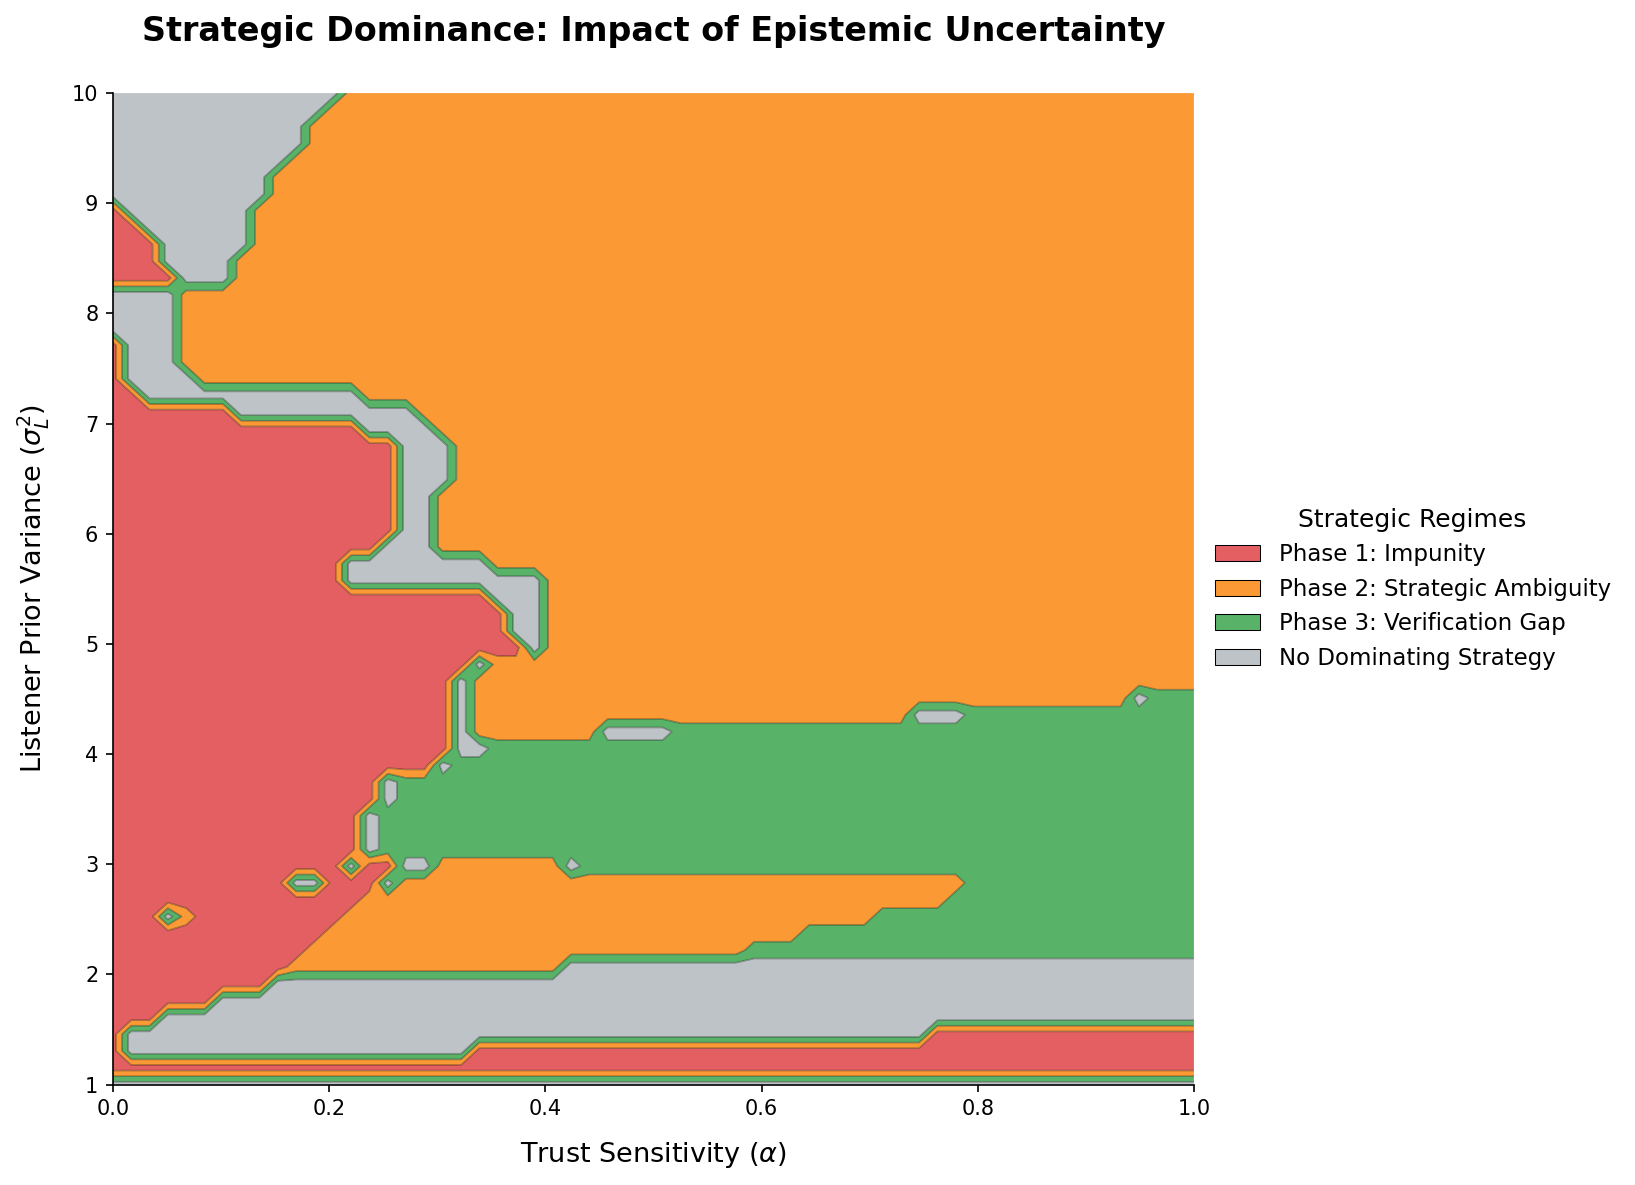

In [29]:
# ==========================================
# 4. RUNNING THE EPISTEMIC (PRIOR) SWEEP
# ==========================================
# We sweep from 1.0 (Confident) to 10.0 (Very Unsure)
# This will show how "epistemic humility" changes the Speaker's strategy.
prior_var_range = np.linspace(1.0, 10.0, 60)

print("\n--- RUNNING EPISTEMIC ENVIRONMENT SWEEP ---")
alphas_ep, priors, strategy_grid_ep = generate_strategy_map(
    'prior_vars', 
    [[v, v] for v in prior_var_range], # Update both arms' prior variance
    alpha_steps=60
)

# ==========================================
# 5. VISUALIZATION: THE EPISTEMIC MAP
# ==========================================
plot_beautiful_strategy_map(
    alphas_ep, 
    prior_var_range, 
    strategy_grid_ep, 
    y_label=r"Listener Prior Variance ($\sigma^2_L$)", 
    title="Strategic Dominance: Impact of Epistemic Uncertainty"
    )


--- RUNNING STRATEGIC AMBIGUITY UTILITY SWEEP ---
🚀 Starting Strategy Map Sweep for: msg_vars
📊 Grid Size: 60 (msg_vars) x 60 (Alpha)
📝 Total Simulations: 3600
--------------------------------------------------
✅ Row 1/60 completed | msg_vars ≈ 2.00
   ⏱️ Row Time: 6.41s | Est. Remaining: 6.3 min
------------------------------
✅ Row 2/60 completed | msg_vars ≈ 2.00
   ⏱️ Row Time: 6.51s | Est. Remaining: 6.2 min
------------------------------
✅ Row 3/60 completed | msg_vars ≈ 2.00
   ⏱️ Row Time: 6.47s | Est. Remaining: 6.1 min
------------------------------
✅ Row 4/60 completed | msg_vars ≈ 2.00
   ⏱️ Row Time: 6.31s | Est. Remaining: 6.0 min
------------------------------
✅ Row 5/60 completed | msg_vars ≈ 2.00
   ⏱️ Row Time: 6.51s | Est. Remaining: 5.9 min
------------------------------
✅ Row 6/60 completed | msg_vars ≈ 2.00
   ⏱️ Row Time: 6.27s | Est. Remaining: 5.8 min
------------------------------
✅ Row 7/60 completed | msg_vars ≈ 2.00
   ⏱️ Row Time: 5.76s | Est. Remaining: 5

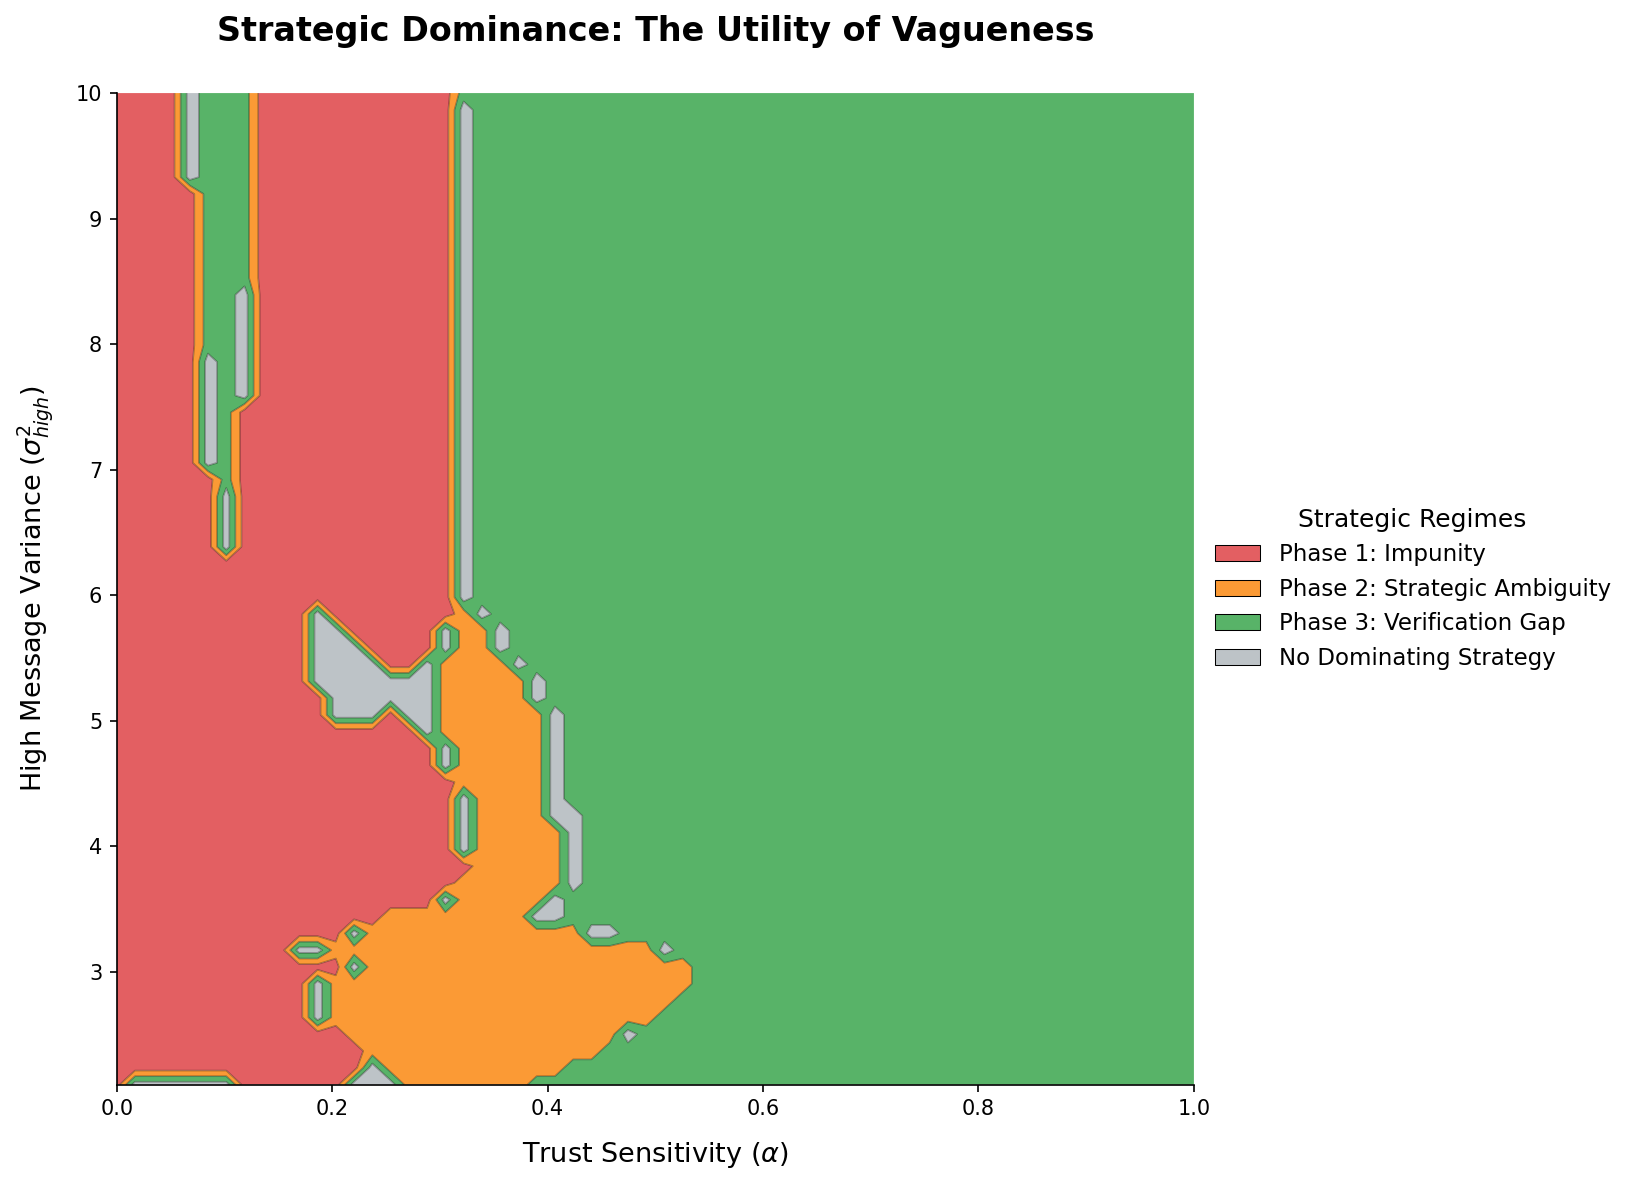

In [30]:
# ==========================================
# 6. RUNNING THE VARIANCE GAP SWEEP
# ==========================================
# Low Var is fixed at 2.0. High Var ranges from 2.1 to 10.0.
# This maps exactly when "Ambiguity" becomes a viable strategy.
high_var_range = np.linspace(2.1, 10.0, 60)

print("\n--- RUNNING STRATEGIC AMBIGUITY UTILITY SWEEP ---")
alphas_var, vars_high, strategy_grid_var = generate_strategy_map(
    'msg_vars', 
    [[2.0, v] for v in high_var_range], 
    alpha_steps=60
)

# ==========================================
# 7. VISUALIZATION: THE AMBIGUITY MAP
# ==========================================
plot_beautiful_strategy_map(
    alphas_var, 
    high_var_range, 
    strategy_grid_var, 
    y_label=r"High Message Variance ($\sigma^2_{high}$)", 
    title="Strategic Dominance: The Utility of Vagueness"
)

In [51]:
import numpy as np
import time
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import matplotlib.patches as mpatches

def run_alpha_sweep_individual(params, alpha_steps=21):
    alpha_values = np.linspace(0.0, 1.0, alpha_steps)
    
    res = {
        "alphas": alpha_values,
        "hype_pre": [], "hype_vag": [],
        "hon_pre": [],  "hon_vag": [],
        "sab_pre": [],  "sab_vag": [],
        "params": params.copy()
    }
    
    low_var = params['msg_vars'][0]
    high_var = params['msg_vars'][1]

    for alpha in alpha_values:
        # --- FULL ENVIRONMENT CONSTRUCTION RESTORED ---
        obs_L, obs_S_truth, obs_S_inc = [], [], []
        
        # Step 0: Current State
        obs_L.append([(m, v) for m, v in zip(params['prior_means'], params['prior_vars'])])
        obs_S_truth.append([(v, 0.1) for v in params['curr_truth']])
        obs_S_inc.append([(v, 0.1) for v in params['curr_inc']])
        
        # Future steps for look-ahead
        for _ in range(params['horizon_strat'] + 1): 
            obs_L.append([(m, v) for m, v in zip(params['prior_means'], params['prior_vars'])]) 
            obs_S_truth.append([(v, 0.1) for v in params['fut_truth']])
            obs_S_inc.append([(v, 0.1) for v in params['fut_inc']])

        # Agent instantiation
        agent = RollingHorizonSpeaker(
            num_arms=2, horizon=params['horizon_strat'], 
            gamma_honesty=params['gamma'], alpha_trust=alpha, 
            beta_speaker=params['beta_s'], beta_listener=params['beta_l'],
            msg_means=params['msg_means'], msg_vars=params['msg_vars']
        )
        
        space, probs = agent.get_policy_distribution(START_TRUST, obs_L, obs_S_truth, obs_S_inc)
        
        # Bins for every single target-arm message option
        stats = { 'h_p': 0.0, 'h_v': 0.0, 'n_p': 0.0, 'n_v': 0.0, 's_p': 0.0, 's_v': 0.0 }
        
        for k, u in enumerate(space):
            u_t = u[0] # Target Message
            p = probs[k]
            
            # Categorize by Mean and then by Variance
            if abs(u_t[0] - 5.0) < 0.1: # Hype
                if abs(u_t[1] - low_var) < 0.1: stats['h_p'] += p
                else: stats['h_v'] += p
            elif abs(u_t[0] - 0.0) < 0.1: # Neutral/Honest
                if abs(u_t[1] - low_var) < 0.1: stats['n_p'] += p
                else: stats['n_v'] += p
            elif abs(u_t[0] - -5.0) < 0.1: # Sabotage
                if abs(u_t[1] - low_var) < 0.1: stats['s_p'] += p
                else: stats['s_v'] += p
            
        res['hype_pre'].append(stats['h_p'])
        res['hype_vag'].append(stats['h_v'])
        res['hon_pre'].append(stats['n_p'])
        res['hon_vag'].append(stats['n_v'])
        res['sab_pre'].append(stats['s_p'])
        res['sab_vag'].append(stats['s_v'])
    return res

# def generate_strategy_map_individual(param_name, param_range, alpha_steps=40):
#     alphas = np.linspace(0.0, 1.0, alpha_steps)
#     num_params = len(param_range)
#     grid = np.zeros((num_params, alpha_steps))
#     epsilon = 1e-2 

#     print(f"🚀 Starting Rigorous Sweep for: {param_name}")
#     start_time = time.time()

#     for i, p_val in enumerate(param_range):
#         current_params = BASE_PARAMS.copy()
#         current_params[param_name] = p_val
#         res = run_alpha_sweep_individual(current_params, alpha_steps=alpha_steps)
        
#         for j in range(alpha_steps):
#             # The Competition: Comparing specific individual utterances
#             choices = [
#                 res['hype_pre'][j], # 0
#                 res['hype_vag'][j], # 1
#                 res['hon_pre'][j],  # 2
#                 res['hon_vag'][j],  # 3 (Vague Honest)
#                 res['sab_pre'][j],   # 4 (Self-Sabotage)
#                 res['sab_vag'][j]   # 5 (Vague Sabotage)
#             ]
#             max_p = max(choices)
#             winners = [idx for idx, val in enumerate(choices) if abs(val - max_p) < epsilon]
            
#             if len(winners) > 1:
#                 grid[i, j] = 6 # No Dominating Strategy (Gray)
#             else:
#                 grid[i, j] = winners[0]
                
#     print(f"✨ Sweep Complete! Total Time: {(time.time()-start_time)/60:.1f} minutes")
#     return alphas, param_range, grid

def generate_strategy_map_individual(param_name, param_range, alpha_steps=60):
    alphas = np.linspace(0.0, 1.0, alpha_steps)
    num_params = len(param_range)
    grid = np.zeros((num_params, alpha_steps))
    epsilon = 1e-2 

    # --- Phase Statistics Tracker ---
    # 0:HypePre, 1:HypeVag, 2:HonPre, 3:HonVag, 4:SabPre, 5:SabVag, 6:Tie
    counts = np.zeros(7)
    phase_names = ["Hype-P", "Hype-V", "Hon-P", "Hon-V", "Sab-P", "Sab-V", "Tie"]

    print(f"🚀 STARTING RIGOROUS 6-PHASE SWEEP: {param_name}")
    print(f"📊 Grid: {num_params} rows x {alpha_steps} alphas | Total Sims: {num_params * alpha_steps}")
    print("=" * 70)

    total_start_time = time.time()

    for i, p_val in enumerate(param_range):
        row_start_time = time.time()
        
        # Determine display value for logging (handle list vs scalar)
        display_val = p_val[0] if isinstance(p_val, list) else p_val
        
        # 1. Run the Row
        current_params = BASE_PARAMS.copy()
        current_params[param_name] = p_val
        res = run_alpha_sweep_individual(current_params, alpha_steps=alpha_steps)
        
        # 2. Classify and Track Live Stats
        for j in range(alpha_steps):
            choices = [
                res['hype_pre'][j], res['hype_vag'][j], 
                res['hon_pre'][j],  res['hon_vag'][j], 
                res['sab_pre'][j],  res['sab_vag'][j]
            ]
            max_p = max(choices)
            winners = [idx for idx, val in enumerate(choices) if abs(val - max_p) < epsilon]
            
            if len(winners) > 1:
                winner_idx = 6 # Tie
            else:
                winner_idx = winners[0]
            
            grid[i, j] = winner_idx
            counts[winner_idx] += 1

        # 3. Dynamic Progress Logging
        elapsed = time.time() - total_start_time
        avg_time_per_row = elapsed / (i + 1)
        remaining_rows = num_params - (i + 1)
        est_rem_min = (remaining_rows * avg_time_per_row) / 60
        
        # Create a small visual bar for the row progress
        progress_pct = int(((i + 1) / num_params) * 20)
        bar = "█" * progress_pct + "░" * (20 - progress_pct)
        
        print(f"[{bar}] {i+1:3d}/{num_params} | {param_name}: {display_val:5.2f} | Row: {time.time()-row_start_time:5.2f}s | Rem: {est_rem_min:4.1f}m")
        
        # Optional: Print current leading phase for this row
        row_top_phase = phase_names[int(np.argmax(np.bincount(grid[i,:].astype(int), minlength=7)))]
        print(f"      ↳ Row dominant strategy: {row_top_phase}")

    # --- Final Summary ---
    total_time = (time.time() - total_start_time) / 60
    print("=" * 70)
    print(f"✨ SWEEP COMPLETE in {total_time:.2f} minutes")
    print("📈 FINAL DISTRIBUTION OF WINNING STRATEGIES:")
    for name, count in zip(phase_names, counts):
        if count > 0:
            print(f"   - {name:7}: {int(count):4d} cells ({(count/grid.size)*100:4.1f}%)")
    print("=" * 70)
                
    return alphas, param_range, grid

In [68]:
def plot_ultimate_strategy_map(alphas, y_range, grid, y_label, title):
    X, Y = np.meshgrid(alphas, y_range)
    plt.figure(figsize=(11, 8), dpi=150)
    
    # 0:Red, 1:Orange, 2:Green, 3:Purple(V.Honest), 4:Blue(Sabotage), 5:Blue(V.Sabotage), 6:Gray(Tie)
    colors = ['#e35f62', '#fb9a35', '#58b368', '#9b59b6', "#3dacf6", "#257eb9", '#bdc3c7']
    
    ctf = plt.contourf(X, Y, grid, levels=[-0.5, 0.5, 1.5, 2.5, 3.5, 4.5, 5.5, 6.5], 
                       colors=colors, antialiased=True)
    
    plt.contour(X, Y, grid, levels=[0.5, 1.5, 2.5, 3.5, 4.5, 5.5, 6.5], 
                colors='black', linewidths=0.8, alpha=0.3)

    plt.title(title, fontsize=16, fontweight='bold', pad=25)
    plt.xlabel(r"Trust Sensitivity ($\alpha$)")
    plt.ylabel(y_label)
    
    labels = ["Phase 1: Impunity", "Phase 2: Plausible Deniability", "Phase 3: Verification Gap",
              "Vague Honest", "Precise Sabotage", "Vague Sabotage", "No Dominating Strategy"]
    patches = [mpatches.Patch(color=colors[i], label=labels[i], ec='black', lw=0.5) for i in range(len(labels))]
    plt.legend(handles=patches, loc='center left', bbox_to_anchor=(1, 0.5), frameon=False)
    plt.tight_layout()
    plt.show()

🚀 STARTING RIGOROUS 6-PHASE SWEEP: beta_s
📊 Grid: 60 rows x 60 alphas | Total Sims: 3600
[░░░░░░░░░░░░░░░░░░░░]   1/60 | beta_s:  1.00 | Row:  5.66s | Rem:  5.6m
      ↳ Row dominant strategy: Hon-P
[░░░░░░░░░░░░░░░░░░░░]   2/60 | beta_s:  1.15 | Row: 27.72s | Rem: 16.1m
      ↳ Row dominant strategy: Hon-P
[█░░░░░░░░░░░░░░░░░░░]   3/60 | beta_s:  1.31 | Row:  5.63s | Rem: 12.4m
      ↳ Row dominant strategy: Hon-P
[█░░░░░░░░░░░░░░░░░░░]   4/60 | beta_s:  1.46 | Row: 26.28s | Rem: 15.2m
      ↳ Row dominant strategy: Hon-P
[█░░░░░░░░░░░░░░░░░░░]   5/60 | beta_s:  1.61 | Row:  5.74s | Rem: 13.0m
      ↳ Row dominant strategy: Hon-P
[██░░░░░░░░░░░░░░░░░░]   6/60 | beta_s:  1.76 | Row:  5.74s | Rem: 11.5m
      ↳ Row dominant strategy: Hon-P
[██░░░░░░░░░░░░░░░░░░]   7/60 | beta_s:  1.92 | Row:  5.89s | Rem: 10.4m
      ↳ Row dominant strategy: Hon-P
[██░░░░░░░░░░░░░░░░░░]   8/60 | beta_s:  2.07 | Row:  5.74s | Rem:  9.6m
      ↳ Row dominant strategy: Hon-P
[███░░░░░░░░░░░░░░░░░]   9/60 |

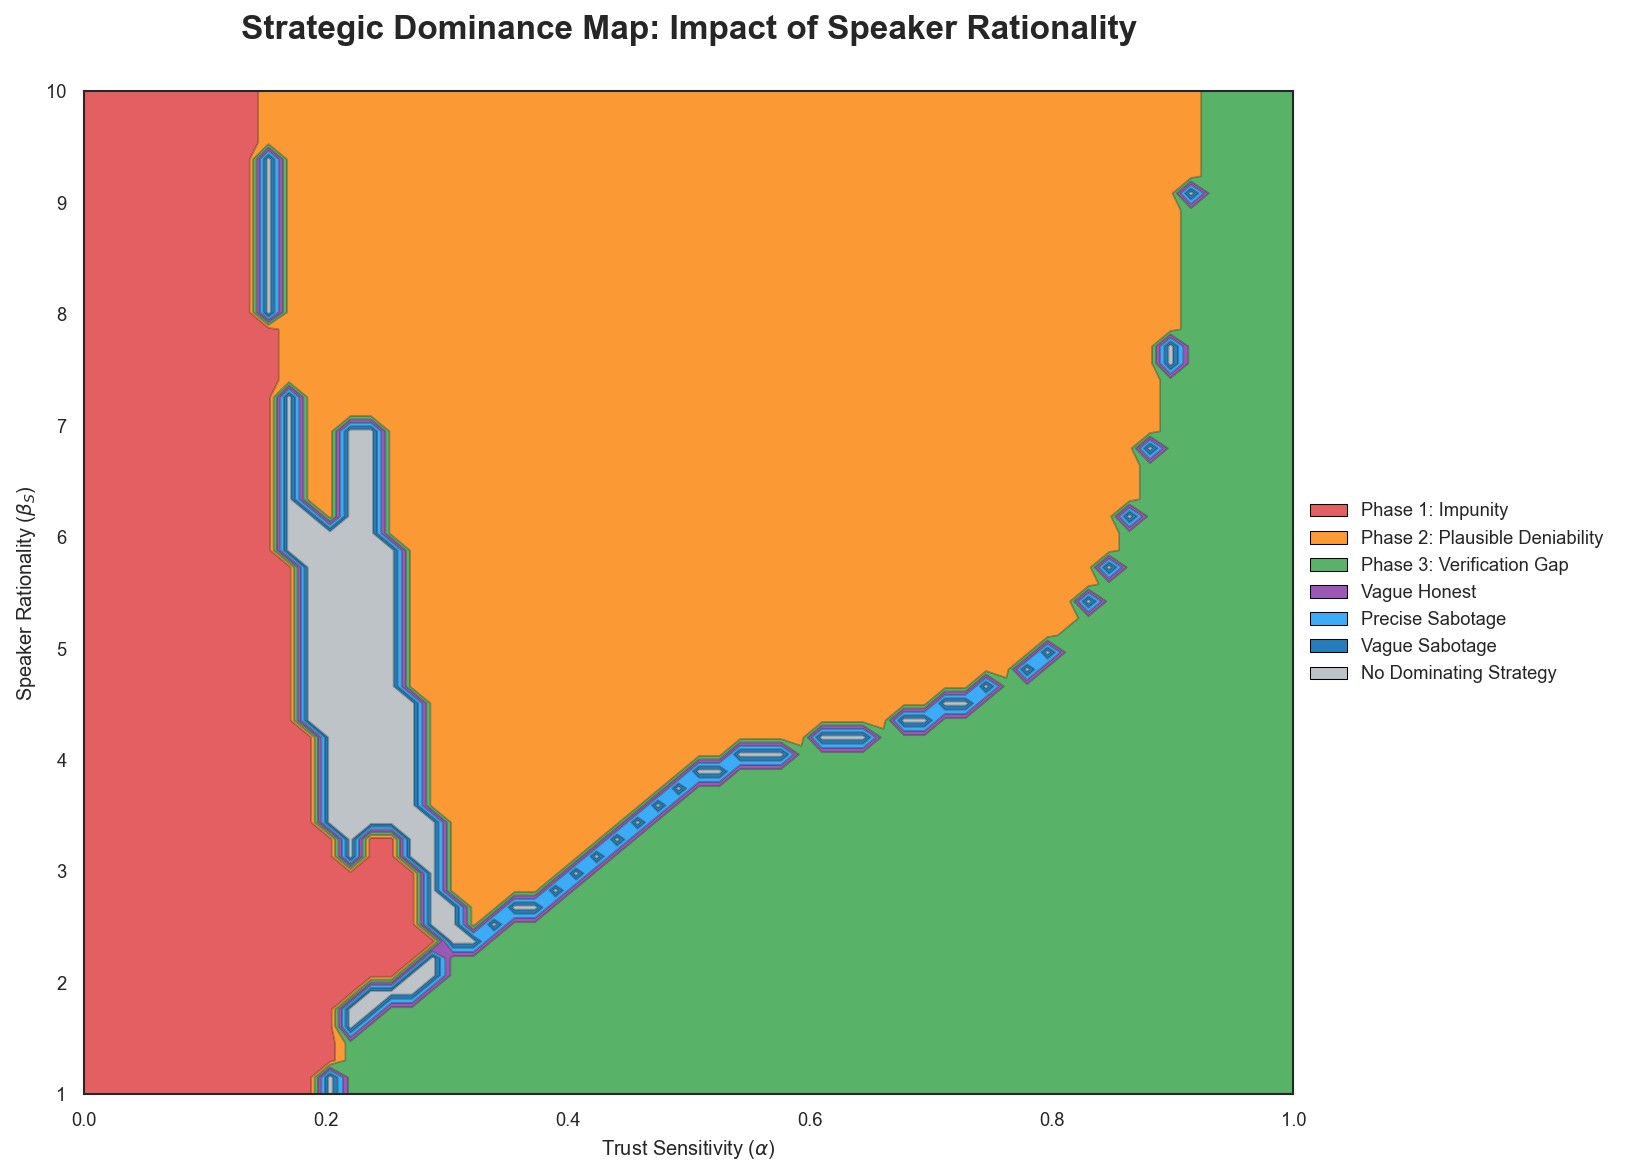

In [70]:
beta_range = np.linspace(1.0, 10.0, 60)

alphas, betas, strategy_grid = generate_strategy_map_individual('beta_s', beta_range, alpha_steps=60)
plot_ultimate_strategy_map(alphas, betas, strategy_grid, 
                  y_label=r"Speaker Rationality ($\beta_S$)", 
                  title="Strategic Dominance Map: Impact of Speaker Rationality")

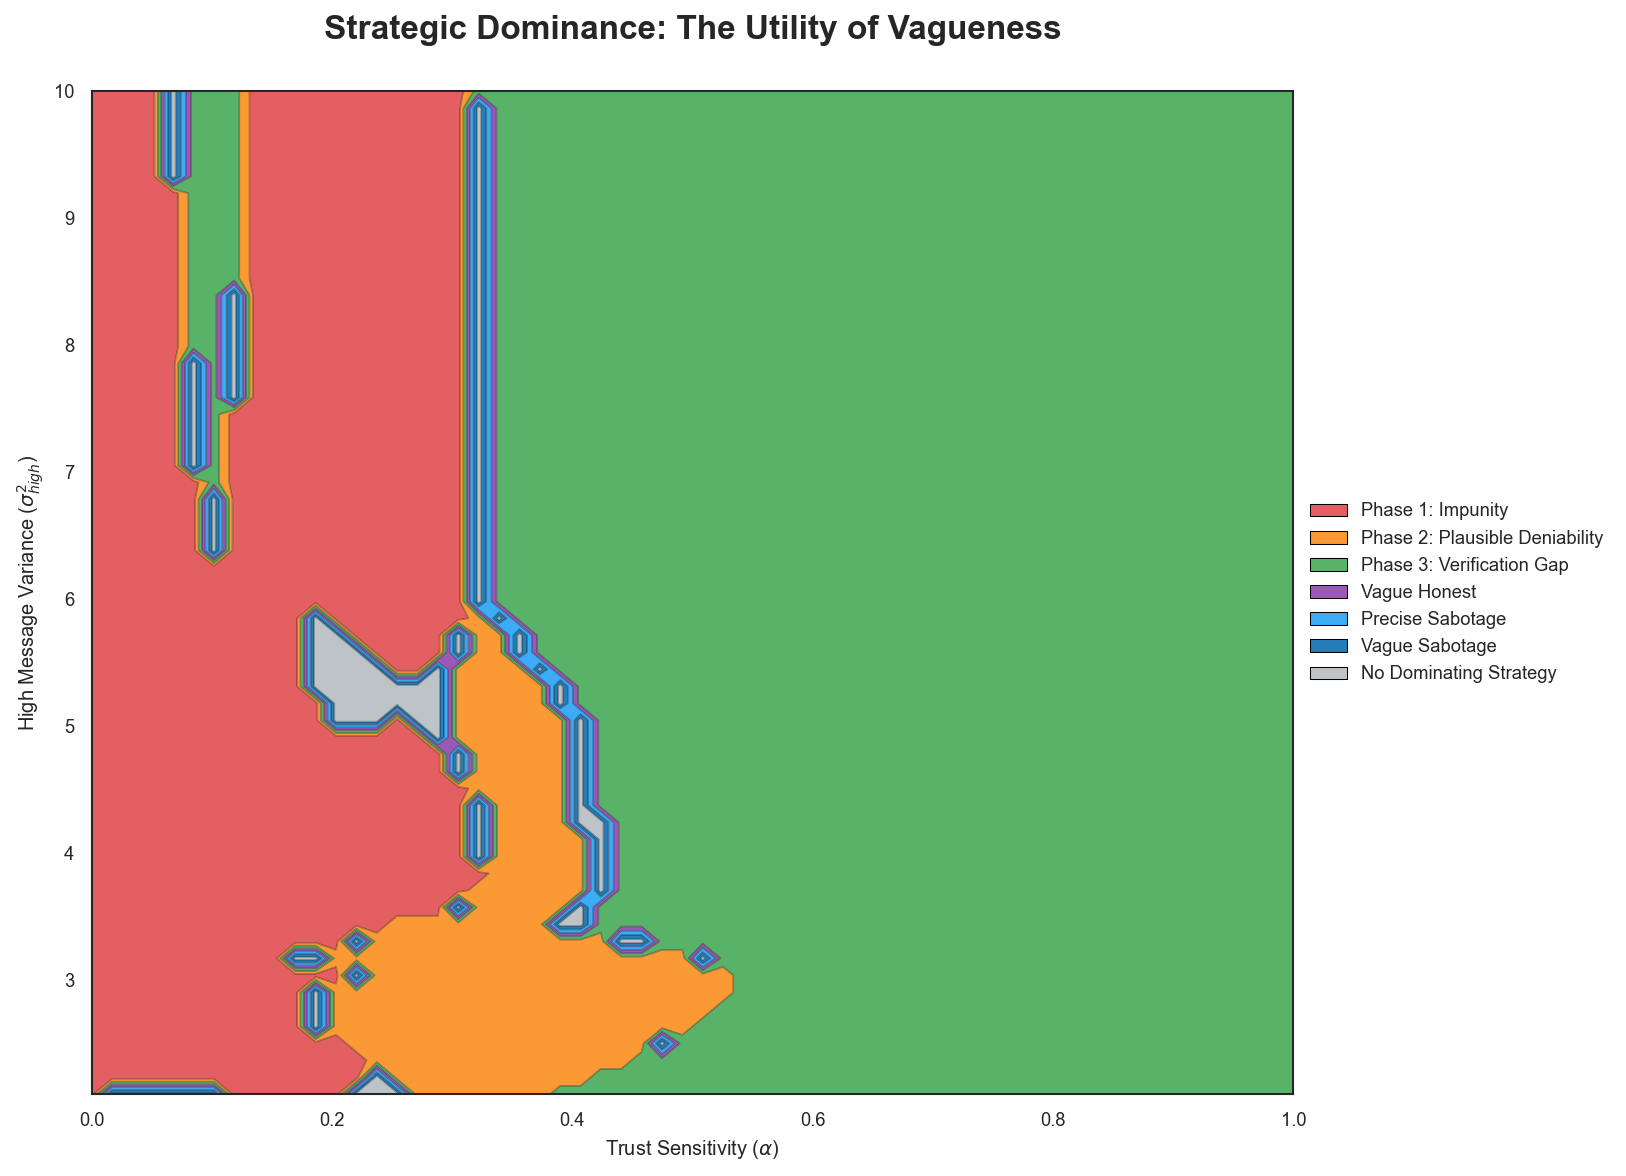

In [69]:

high_var_range = np.linspace(2.1, 10.0, 60)

# print("\n--- RUNNING STRATEGIC AMBIGUITY UTILITY SWEEP ---")
# alphas_var, vars_high, strategy_grid_var = generate_strategy_map_individual(
#     'msg_vars', 
#     [[2.0, v] for v in high_var_range], 
#     alpha_steps=60
# )

# ==========================================
# 7. VISUALIZATION: THE AMBIGUITY MAP
# ==========================================
plot_ultimate_strategy_map(
    alphas_var, 
    high_var_range, 
    strategy_grid_var, 
    y_label=r"High Message Variance ($\sigma^2_{high}$)", 
    title="Strategic Dominance: The Utility of Vagueness"
)


--- RUNNING EPISTEMIC ENVIRONMENT SWEEP ---


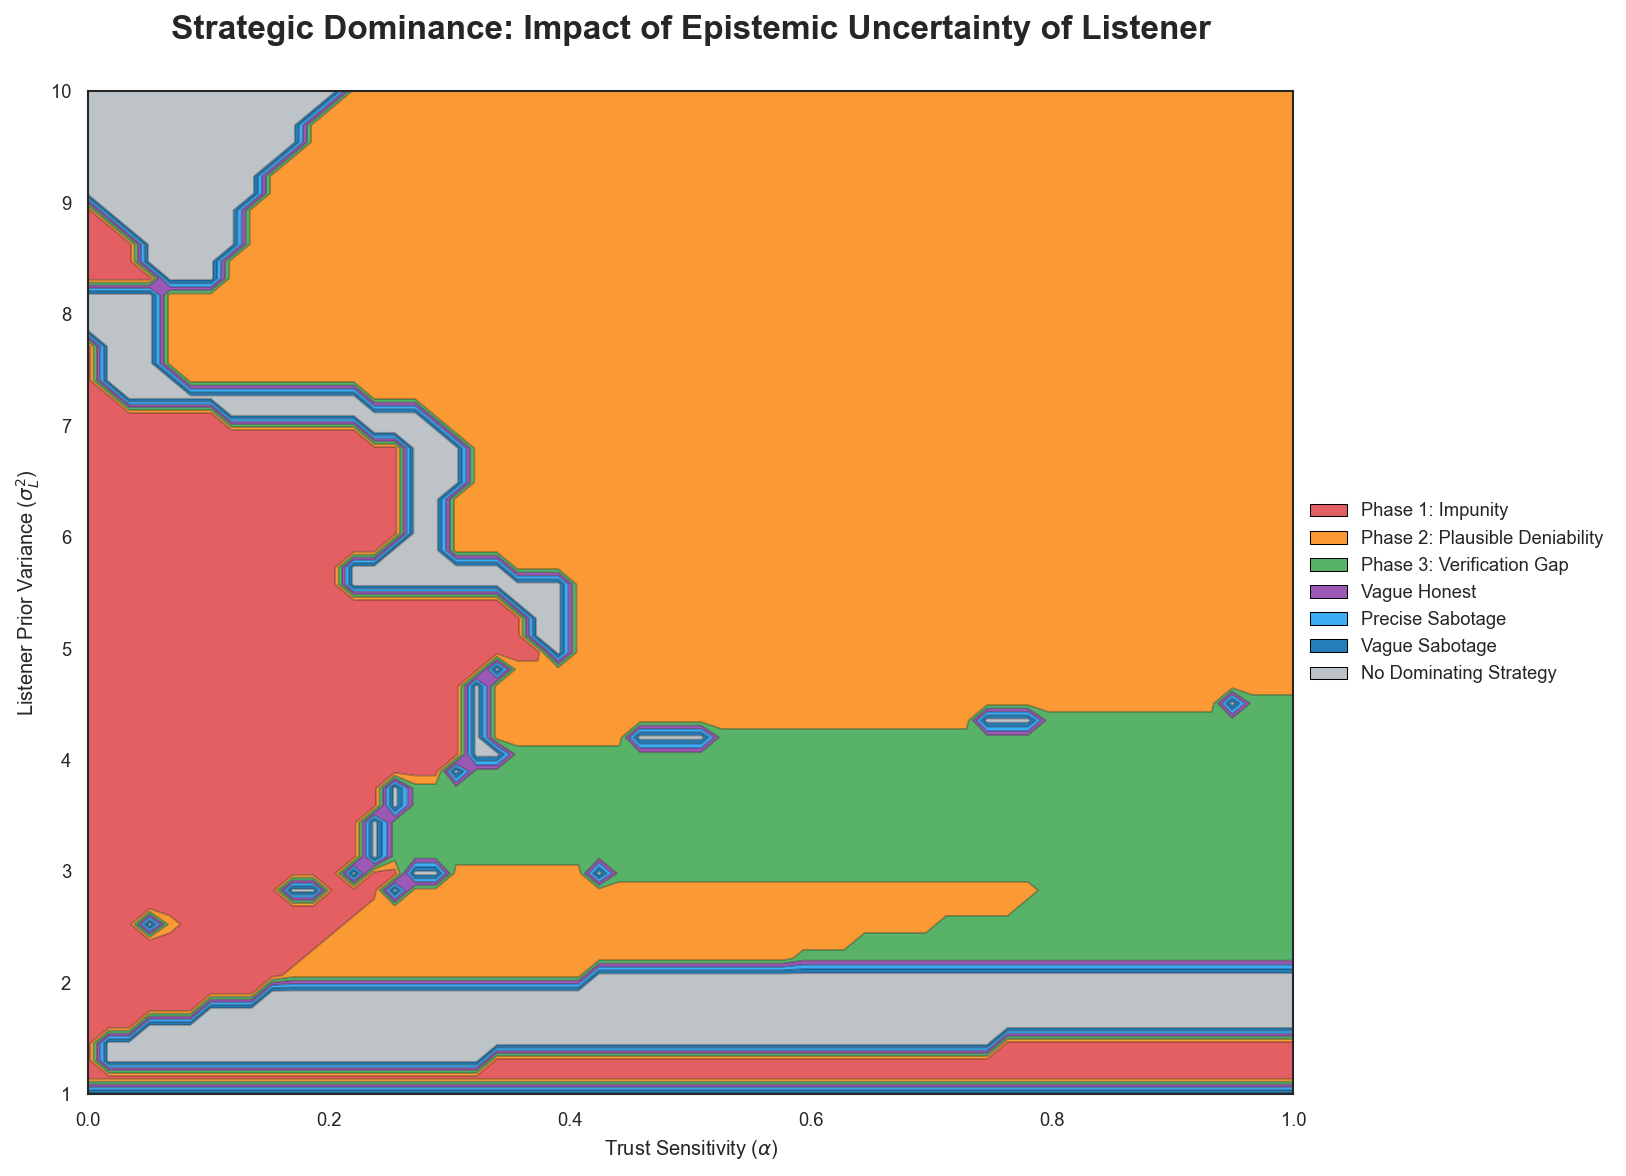

In [71]:
prior_var_range = np.linspace(1.0, 10.0, 60)

print("\n--- RUNNING EPISTEMIC ENVIRONMENT SWEEP ---")
# alphas_ep, priors, strategy_grid_ep = generate_strategy_map_individual(
#     'prior_vars', 
#     [[v, v] for v in prior_var_range], # Update both arms' prior variance
#     alpha_steps=60
# )

# ==========================================
# 5. VISUALIZATION: THE EPISTEMIC MAP
# ==========================================
plot_ultimate_strategy_map(
    alphas_ep, 
    prior_var_range, 
    strategy_grid_ep, 
    y_label=r"Listener Prior Variance ($\sigma^2_L$)", 
    title="Strategic Dominance: Impact of Epistemic Uncertainty of Listener"
    )

In [60]:
def get_baseline_comparison(params, alpha=0.50):
    # Setup environment for current and future rewards
    obs_L, obs_S_truth, obs_S_inc = [], [], []
    obs_L.append([(m, v) for m, v in zip(params['prior_means'], params['prior_vars'])])
    obs_S_truth.append([(v, 0.1) for v in params['curr_truth']])
    obs_S_inc.append([(v, 0.1) for v in params['curr_inc']])
    
    for _ in range(params['horizon_strat'] + 1): 
        obs_L.append([(m, v) for m, v in zip(params['prior_means'], params['prior_vars'])]) 
        obs_S_truth.append([(v, 0.1) for v in params['fut_truth']])
        obs_S_inc.append([(v, 0.1) for v in params['fut_inc']])

    # 1. Myopic Policy (H=1)
    myopic_agent = RollingHorizonSpeaker(
        num_arms=2, horizon=1, gamma_honesty=params['gamma'], 
        alpha_trust=alpha, beta_speaker=params['beta_s'], 
        beta_listener=params['beta_l'], msg_means=params['msg_means'], 
        msg_vars=params['msg_vars']
    )
    m_space, m_probs = myopic_agent.get_policy_distribution(0.5, obs_L, obs_S_truth, obs_S_inc)
    
    # 2. Strategic Policy (H=2)
    strat_agent = RollingHorizonSpeaker(
        num_arms=2, horizon=2, gamma_honesty=params['gamma'], 
        alpha_trust=alpha, beta_speaker=params['beta_s'], 
        beta_listener=params['beta_l'], msg_means=params['msg_means'], 
        msg_vars=params['msg_vars']
    )
    s_space, s_probs = strat_agent.get_policy_distribution(0.5, obs_L, obs_S_truth, obs_S_inc)
    
    return m_space, m_probs, s_space, s_probs

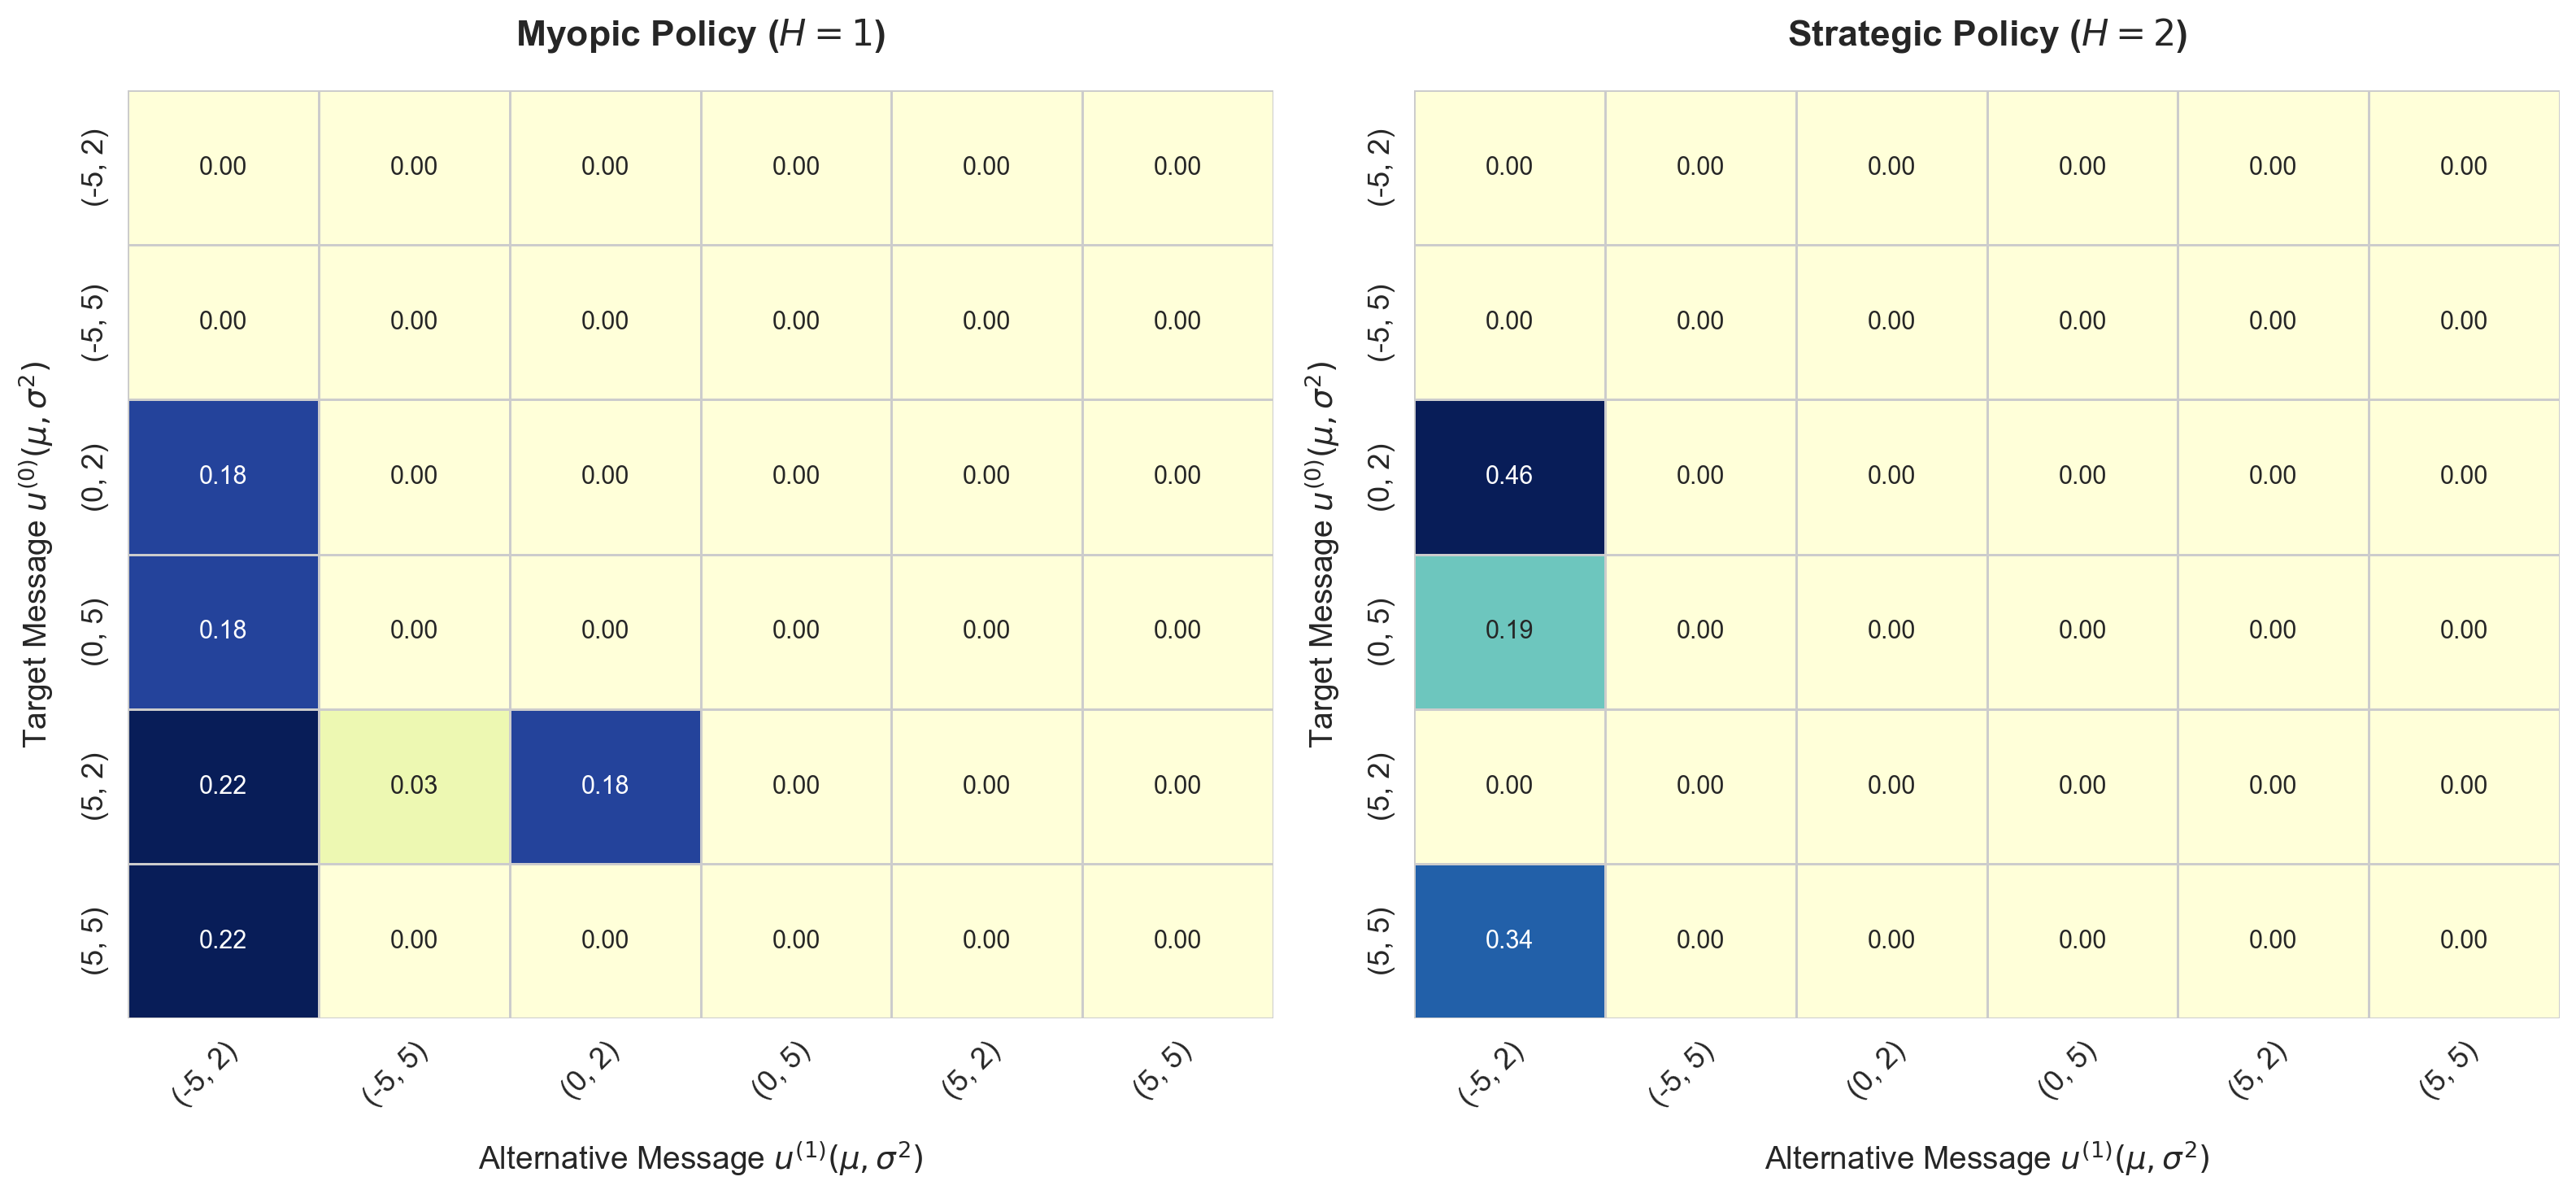

In [61]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def plot_side_by_side_baseline(m_probs, s_probs):
    # Defining simplified number-pair labels
    # Format: (Mean, Variance)
    labels = ["(-5, 2)", "(-5, 5)", "(0, 2)", "(0, 5)", "(5, 2)", "(5, 5)"]
    
    m_grid = m_probs.reshape(6, 6)
    s_grid = s_probs.reshape(6, 6)

    fig, axes = plt.subplots(1, 2, figsize=(16, 7.5), dpi=200)
    
    # Global Plot Styling
    plt.rcParams.update({'font.size': 12})
    heatmap_kwargs = {
        'annot': True, 
        'fmt': ".2f", 
        'cmap': "YlGnBu", 
        'cbar': False,
        'xticklabels': labels, 
        'yticklabels': labels,
        'annot_kws': {"size": 11}, # Size of numbers inside squares
        'linewidths': 0.5,
        'linecolor': '0.8'
    }

    # Plot 1: Myopic Agent
    sns.heatmap(m_grid, ax=axes[0], **heatmap_kwargs)
    axes[0].set_title("Myopic Policy ($H=1$)", fontsize=16, fontweight='bold', pad=20)
    
    # Plot 2: Strategic Agent
    sns.heatmap(s_grid, ax=axes[1], **heatmap_kwargs)
    axes[1].set_title("Strategic Policy ($H=2$)", fontsize=16, fontweight='bold', pad=20)

    for ax in axes:
        # Customizing Axes Labels
        ax.set_xlabel(r"Alternative Message $u^{(1)} (\mu, \sigma^2)$", fontsize=14, labelpad=12)
        ax.set_ylabel(r"Target Message $u^{(0)} (\mu, \sigma^2)$", fontsize=14, labelpad=12)
        
        # Increasing the font size of the tick labels (the number pairs)
        ax.tick_params(axis='both', which='major', labelsize=13)
        plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")

    plt.tight_layout()
    plt.show()


m_space, m_probs, s_space, s_probs = get_baseline_comparison(BASE_PARAMS)
plot_side_by_side_baseline(m_probs, s_probs)

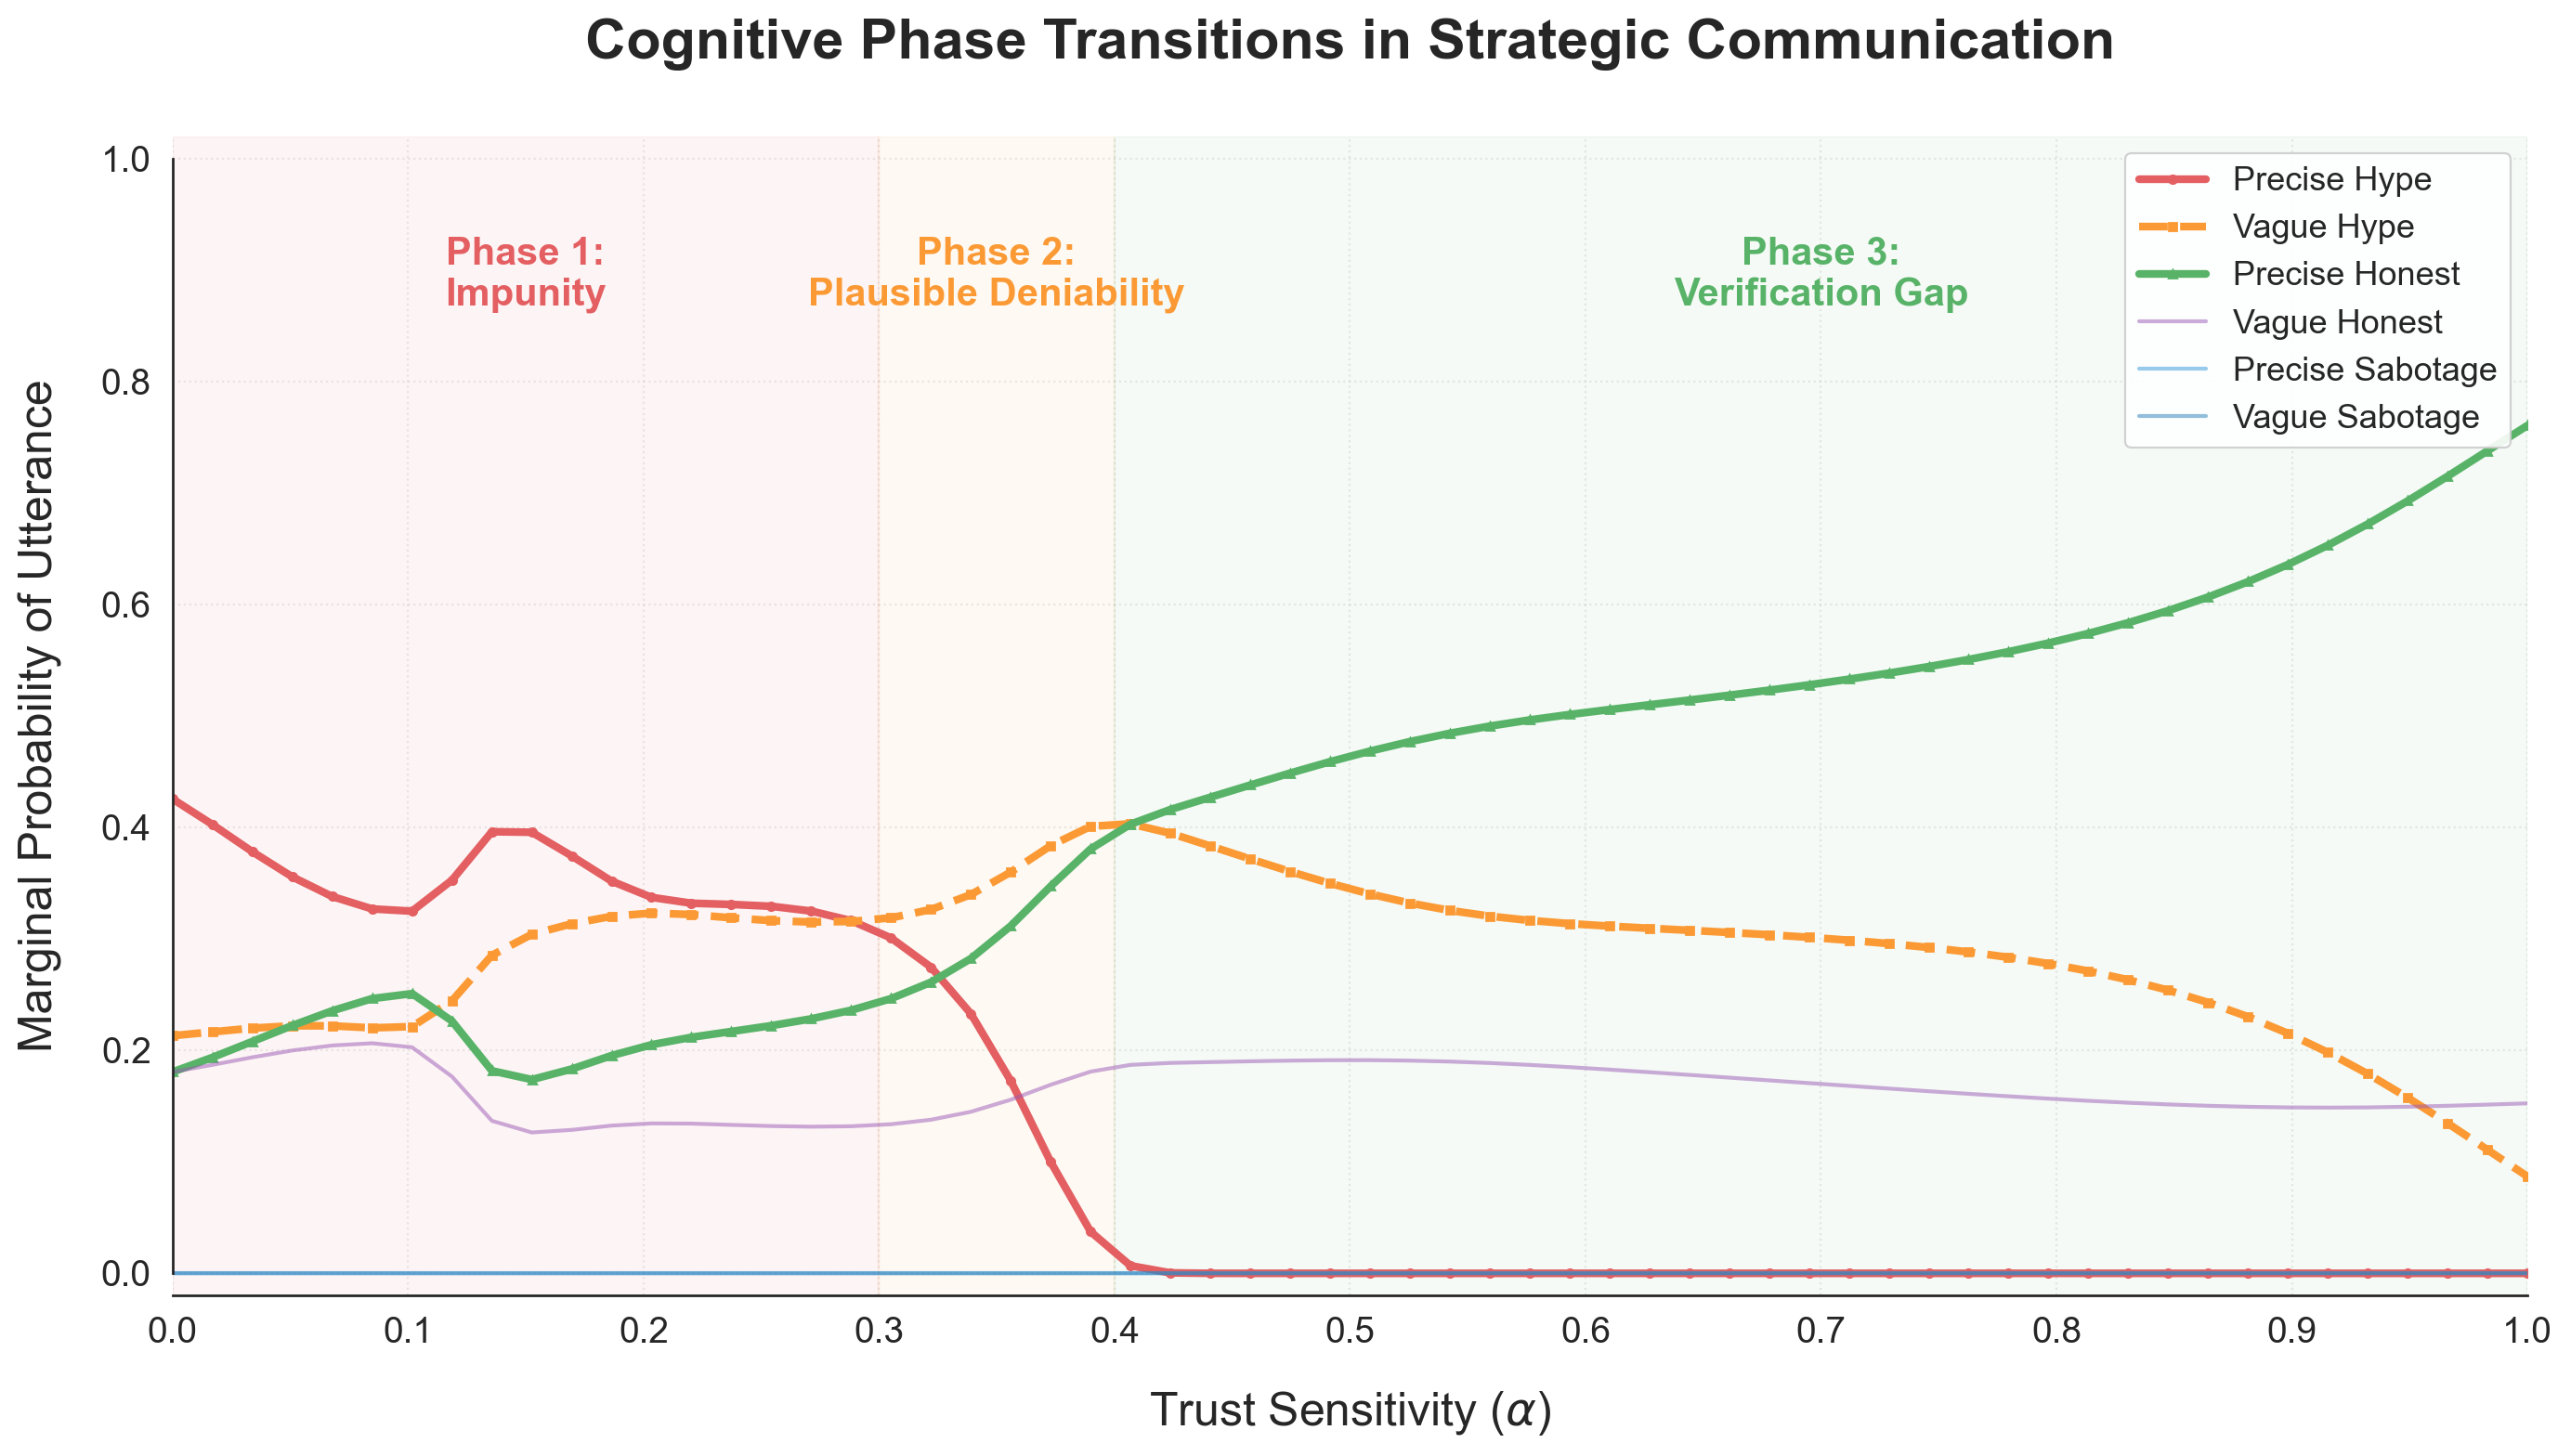

In [66]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def plot_aesthetic_alpha_sweep_v2(res):
    alphas = res['alphas']
    plt.figure(figsize=(14, 8), dpi=200)
    sns.set_style("white")
    
    # Colors & Strategy Mapping
    colors = {
        'hp': '#e35f62', 'hv': '#fb9a35', 'np': '#58b368', 
        'nv': '#9b59b6', 'sp': '#3498db', 'sv': '#2980b9'
    }

    # Plot lines with smaller markers and refined styles
    plt.plot(alphas, res['hype_pre'], color=colors['hp'], lw=3, label='Precise Hype', marker='o', markersize=3)
    plt.plot(alphas, res['hype_vag'], color=colors['hv'], lw=3, label='Vague Hype', ls='--', marker='s', markersize=3)
    plt.plot(alphas, res['hon_pre'], color=colors['np'], lw=3, label='Precise Honest', marker='^', markersize=3)
    
    # Residuals
    plt.plot(alphas, res['hon_vag'], color=colors['nv'], lw=1.5, label='Vague Honest', alpha=0.5)
    plt.plot(alphas, res['sab_pre'], color=colors['sp'], lw=1.5, label='Precise Sabotage', alpha=0.5)
    plt.plot(alphas, res['sab_vag'], color=colors['sv'], lw=1.5, label='Vague Sabotage', alpha=0.5)

    # Dynamic Phase Shading
    plt.axvspan(0, 0.3, color=colors['hp'], alpha=0.06)
    plt.axvspan(0.3, 0.4, color=colors['hv'], alpha=0.06)
    plt.axvspan(0.4, 1.0, color=colors['np'], alpha=0.06)

    # In-Plot Annotations for Phases
    text_y = 0.93
    plt.text(0.15, text_y, "Phase 1:\nImpunity", ha='center', va='top', fontsize=15, fontweight='bold', color=colors['hp'])
    plt.text(0.35, text_y, "Phase 2:\nPlausible Deniability", ha='center', va='top', fontsize=15, fontweight='bold', color=colors['hv'])
    plt.text(0.70, text_y, "Phase 3:\nVerification Gap", ha='center', va='top', fontsize=15, fontweight='bold', color=colors['np'])

    # Formatting
    plt.title("Cognitive Phase Transitions in Strategic Communication", fontsize=22, fontweight='bold', pad=30)
    plt.xlabel(r"Trust Sensitivity ($\alpha$)", fontsize=18, labelpad=15)
    plt.ylabel("Marginal Probability of Utterance", fontsize=18, labelpad=15)
    
    plt.xticks(np.arange(0, 1.1, 0.1), fontsize=14)
    plt.yticks(np.arange(0, 1.1, 0.2), fontsize=14)
    plt.ylim(-0.02, 1.02)
    plt.xlim(0, 1.0)
    
    # Legend at the Top Right
    plt.legend(loc='upper right', frameon=True, fontsize=13, facecolor='white', framealpha=0.9)
    plt.grid(True, linestyle=':', alpha=0.4)
    sns.despine(trim=True)
    
    plt.tight_layout()
    plt.show()
    
# Run the sweep and plot
res_60 = run_alpha_sweep_individual(BASE_PARAMS, alpha_steps=60)
plot_aesthetic_alpha_sweep_v2(res_60)

In [77]:
import numpy as np
from scipy.stats import norm

class PragmaticListener:
    def __init__(self, speaker_class_ref, num_arms=2, horizon=1):
        """
        speaker_class_ref: The class of the Speaker agent (RollingHorizonSpeaker)
                           used to simulate the speaker's internal reasoning.
        """
        self.SpeakerClass = speaker_class_ref
        self.num_arms = num_arms
        self.horizon = horizon
        
        # --- 1. Hypothesis Spaces ---
        # Ground Truth (What we want to know): Grid [-10, ... 10]
        self.grid_rL = np.linspace(-10, 10, 21) 
        
        # Incentives (Nuisance variable): Grid [-20, ... 120] to capture +100 spikes
        self.grid_rS = np.linspace(-20, 120, 15) 
        
        # Speaker Types (Gamma): Discrete approximation of honesty
        # 0.0 = Impunity (Lies for everything)
        # 25.0 = Strategic (Honest for +10, Lies for +100)
        # 200.0 = Honest (Almost never lies)
        self.gamma_types = [0.0, 25.0, 200.0]
        self.gamma_prior = np.array([0.4, 0.4, 0.2]) # Prior belief about population

    def infer_ground_truth(self, utterance, obs_L, obs_S_est, current_trust, step_idx=0):
        """
        Bayesian Inverse Planning to estimate Ground Truth.
        
        Args:
            utterance: The u_t received from speaker (Tuple of tuples)
            obs_L: Listener's private signal [ (mu, sig), (mu, sig) ]
            obs_S_est: L's noisy estimate of S's reward [mu_0, mu_1]
            current_trust: Current probability of trust (0.0 to 1.0)
            step_idx: Current turn (0 for first step)
        
        Returns:
            posterior_rL: Probability dist over self.grid_rL for each arm.
        """
        posterior_rL = np.zeros((self.num_arms, len(self.grid_rL)))
        
        # Instantiate a simplified speaker for simulation
        # Gamma will be overwritten in the loop
        sim_speaker = self.SpeakerClass(num_arms=self.num_arms, horizon=self.horizon, gamma_honesty=0.0)
        
        # Ensure utterance is strictly a tuple of tuples for robust comparison
        # (Handling cases where input might be a list of lists)
        try:
            utterance_tuple = tuple(tuple(x) for x in utterance)
        except TypeError:
            utterance_tuple = tuple(utterance)

        # === LOOP 1: For each Arm (Assuming independence for estimation speed) ===
        for k in range(self.num_arms):
            
            # Pre-calculate Incentive Prior P(r_S | obs_S_est) for this arm
            # "How likely is the speaker to have incentive X given my noisy estimate?"
            prior_inc_dist = norm.pdf(self.grid_rS, loc=obs_S_est[k], scale=10.0)
            prior_inc_dist /= (np.sum(prior_inc_dist) + 1e-9)

            # === LOOP 2: Ground Truth Hypotheses (The Goal) ===
            for i_truth, val_truth in enumerate(self.grid_rL):
                
                # Likelihood accumulator for this specific r_L hypothesis
                likelihood_sum = 0.0
                
                # === LOOP 3: Speaker Types (Gamma) ===
                for i_gamma, gamma_val in enumerate(self.gamma_types):
                    sim_speaker.gamma = gamma_val
                    prob_type = self.gamma_prior[i_gamma]

                    # === LOOP 4: Incentive Hypotheses ===
                    for i_inc, val_inc in enumerate(self.grid_rS):
                        prob_inc = prior_inc_dist[i_inc]
                        
                        # Optimization: Skip negligible probability branches
                        if prob_inc < 0.01: continue

                        # --- CONSTRUCT HYPOTHETICAL WORLD ---
                        # 1. Hypothesized Truth Sequence (Speaker sees 'val_truth' perfectly)
                        # We assume the Speaker sees the truth for the Target arm (k)
                        # and assumes the listener's view (obs_L) for others.
                        seq_S_truth = []
                        # Create sequence for the full horizon (assuming static truth)
                        for _ in range(self.horizon):
                            frame = []
                            for arm_idx in range(self.num_arms):
                                if arm_idx == k:
                                    frame.append((val_truth, 0.1)) # Speaker sees Truth 
                                else:
                                    frame.append(obs_L[arm_idx]) # Fixed to context
                            seq_S_truth.append(frame)

                        # 2. Hypothesized Incentive Sequence (Speaker gets 'val_inc')
                        seq_S_inc = []
                        for _ in range(self.horizon):
                            frame = []
                            for arm_idx in range(self.num_arms):
                                if arm_idx == k:
                                    frame.append((val_inc, 0.1)) 
                                else:
                                    frame.append((0.0, 0.1)) 
                            seq_S_inc.append(frame)

                        # 3. Listener Sequence (Speaker knows L observes obs_L)
                        seq_L = [obs_L for _ in range(self.horizon)]
                        
                        # --- RUN SIMULATION ---
                        # "If I were this type of speaker, with this truth and this reward..."
                        # "...what is the probability I would say 'utterance'?"
                        _, policy_probs = sim_speaker.get_policy_distribution(
                            current_trust, 
                            seq_L, 
                            seq_S_truth, 
                            seq_S_inc
                        )
                        
                        # Find probability of the *actual* utterance received
                        prob_u_given_hyp = 0.0
                        
                        # Robust matching against the Speaker's utterance space
                        for idx, u_poss in enumerate(sim_speaker.utterance_space):
                            if u_poss == utterance_tuple:
                                prob_u_given_hyp = policy_probs[idx]
                                break
                        
                        # Add to weighted sum (Marginalization)
                        likelihood_sum += prob_u_given_hyp * prob_inc * prob_type

                # Bayes Update: Likelihood * Prior P(Truth | Private_Signal)
                prior_truth = norm.pdf(val_truth, loc=obs_L[k][0], scale=obs_L[k][1])
                posterior_rL[k, i_truth] = likelihood_sum * prior_truth
            
            # Normalize this arm's distribution
            posterior_rL[k] /= (np.sum(posterior_rL[k]) + 1e-9)

        return posterior_rL

    def choose_action(self, posterior_rL, beta_action=5.0):
        """
        Standard Boltzmann choice over the NEW posterior expectations.
        """
        expected_rewards = []
        for k in range(self.num_arms):
            # E[r] = sum( val * prob )
            exp_r = np.sum(self.grid_rL * posterior_rL[k])
            expected_rewards.append(exp_r)
        
        expected_rewards = np.array(expected_rewards)
        exps = np.exp(beta_action * (expected_rewards - np.max(expected_rewards)))
        probs = exps / np.sum(exps)
        
        choice = np.random.choice(self.num_arms, p=probs)
        return choice

# ==========================================
# TEST RUNNER
# ==========================================
def run_test():
    # NOTE: This assumes 'RollingHorizonSpeaker' is defined in your scope.
    print("Initializing Agents (Horizon=1)...")
    L1 = PragmaticListener(RollingHorizonSpeaker, num_arms=2, horizon=1)
    
    # --- SETUP ---
    # Arm 0: Target (Ambiguous prior around 0)
    # Arm 1: Alternative (Clearly bad -5)
    obs_L = [(0.0, 3.0), (-5.0, 1.0)] 
    
    # The Utterance: Speaker Hypes Arm 0 ("It's a 5!") and Trashes Arm 1
    # IMPORTANT: Defined as a tuple of tuples to match Speaker internal format
    utterance = ( (5.0, 0.1), (-5.0, 5.0) ) 
    
    print(f"\nListener Prior Mean for Target: {obs_L[0][0]}")
    print(f"Speaker Says: {utterance[0]}")
    print("-" * 40)

    # --- SCENARIO A: Suspicious Incentive ---
    # Listener thinks Speaker gets +100 for Arm 0
    obs_S_est_suspicious = [100.0, 0.0] 
    
    print("\n[TEST A] Context: Speaker gets +100 REWARD if you pick Target.")
    
    post_A = L1.infer_ground_truth(
        utterance, 
        obs_L, 
        obs_S_est_suspicious, 
        current_trust=0.5, 
        step_idx=0
    )
    
    mean_A = np.sum(L1.grid_rL * post_A[0])
    print(f"Posterior Mean (Target): {mean_A:.3f}")
    print("Expected: Mean should be low (Message Discounted).")

    # --- SCENARIO B: No Incentive ---
    # Listener thinks Speaker gets 0 for Arm 0
    obs_S_est_neutral = [0.0, 0.0]
    
    print("\n[TEST B] Context: Speaker gets 0 REWARD if you pick Target.")
    
    post_B = L1.infer_ground_truth(
        utterance, 
        obs_L, 
        obs_S_est_neutral, 
        current_trust=0.5, 
        step_idx=0
    )
    
    mean_B = np.sum(L1.grid_rL * post_B[0])
    print(f"Posterior Mean (Target): {mean_B:.3f}")
    print("Expected: Mean should be high (Message Trusted).")
    
    print("-" * 40)
    print("Validation:")
    # We expect B (Trusted) to be significantly higher than A (Suspicious)
    if mean_B > mean_A + 0.5:
        print(f"SUCCESS: Listener detected the bribe. (Diff: {mean_B - mean_A:.3f})")
    else:
        print("FAILURE: Listener was not sufficiently sensitive to the incentive.")


run_test()

Initializing Agents (Horizon=1)...

Listener Prior Mean for Target: 0.0
Speaker Says: (5.0, 0.1)
----------------------------------------

[TEST A] Context: Speaker gets +100 REWARD if you pick Target.
Posterior Mean (Target): 2.376
Expected: Mean should be low (Message Discounted).

[TEST B] Context: Speaker gets 0 REWARD if you pick Target.
Posterior Mean (Target): 3.142
Expected: Mean should be high (Message Trusted).
----------------------------------------
Validation:
SUCCESS: Listener detected the bribe. (Diff: 0.766)


In [78]:
import numpy as np
import itertools
from scipy.stats import norm

# ==========================================
# 1. RIGOROUS PRIOR SETUP
# ==========================================
def get_rigorous_gamma_prior(sigma_sq=2.0, low_stakes=10.0, high_stakes=100.0):
    """
    Derives Gamma (Honesty) types based on the 'Price of Lying'.
    
    Physics:
    - We calculate the KL cost of a 'Max Lie' (flipping -5 to +5).
    - We find the 'Break-even Gamma' for Low Stakes (10) and High Stakes (100).
    - We define 3 types: One below, one between, and one above these thresholds.
    """
    # 1. Cost of the biggest possible semantic lie (Truth=-5 -> Claim=+5)
    # KL( N(-5, sig) || N(5, sig) ) = (delta_mu^2) / (2 * var)
    delta_mu = 10.0 
    kl_cost_max = (delta_mu**2) / (2 * sigma_sq) # 100 / 4 = 25.0
    
    # 2. Calculate Break-even points (Gamma = Reward / Cost)
    # If Gamma < thresh_low, agent lies for 10.
    thresh_low = low_stakes / kl_cost_max    # 10 / 25 = 0.4
    
    # If Gamma < thresh_high, agent lies for 100.
    thresh_high = high_stakes / kl_cost_max  # 100 / 25 = 4.0
    
    # 3. Define Representative Types
    # Type 0: The Sociopath (Lies for 10) -> 0.0
    g0 = 0.0
    
    # Type 1: The Strategist (Honest for 10, Lies for 100) -> Midpoint approx
    g1 = (thresh_low + thresh_high) / 2.0  # (0.4 + 4.0)/2 = 2.2
    
    # Type 2: The Kantian (Honest for 100) -> Safety margin above high
    g2 = thresh_high * 1.5 # 4.0 * 1.5 = 6.0
    
    types = [g0, g1, g2]
    
    # Max Entropy Prior (Equal probability)
    probs = np.array([1/3, 1/3, 1/3])
    
    return types, probs

# ==========================================
# 2. PRAGMATIC LISTENER (Updated)
# ==========================================
class PragmaticListener:
    def __init__(self, speaker_class_ref, num_arms=2, horizon=1):
        self.SpeakerClass = speaker_class_ref
        self.num_arms = num_arms
        self.horizon = horizon
        
        # Grid Setup
        self.grid_rL = np.linspace(-10, 10, 21) 
        self.grid_rS = np.linspace(-20, 120, 15) 
        
        # --- USE RIGOROUS PRIORS ---
        # Based on parameters from your paper/source
        self.gamma_types, self.gamma_prior = get_rigorous_gamma_prior(
            sigma_sq=2.0,    # 'Precise' variance
            low_stakes=10.0, # Time 1 Reward
            high_stakes=100.0 # Time 2 Reward
        )
        # Store for debug printing
        self.debug_gamma_values = self.gamma_types

    def infer_ground_truth(self, utterance, obs_L, obs_S_est, current_trust, step_idx=0):
        posterior_rL = np.zeros((self.num_arms, len(self.grid_rL)))
        sim_speaker = self.SpeakerClass(num_arms=self.num_arms, horizon=self.horizon, gamma_honesty=0.0)
        
        # Ensure tuple format
        try:
            utterance_tuple = tuple(tuple(x) for x in utterance)
        except TypeError:
            utterance_tuple = tuple(utterance)

        # Iterate Arms
        for k in range(self.num_arms):
            prior_inc_dist = norm.pdf(self.grid_rS, loc=obs_S_est[k], scale=10.0)
            prior_inc_dist /= (np.sum(prior_inc_dist) + 1e-9)

            # Iterate Truth Hypotheses
            for i_truth, val_truth in enumerate(self.grid_rL):
                likelihood_sum = 0.0
                
                # Iterate Gamma Types
                for i_gamma, gamma_val in enumerate(self.gamma_types):
                    sim_speaker.gamma = gamma_val
                    prob_type = self.gamma_prior[i_gamma]

                    # Iterate Incentives
                    for i_inc, val_inc in enumerate(self.grid_rS):
                        prob_inc = prior_inc_dist[i_inc]
                        if prob_inc < 0.01: continue 

                        # Construct hypothetical world
                        seq_S_truth = [[obs_L[i] if i != k else (val_truth, 0.1) for i in range(self.num_arms)] for _ in range(self.horizon)]
                        seq_S_inc = [[(0.0, 0.1) if i != k else (val_inc, 0.1) for i in range(self.num_arms)] for _ in range(self.horizon)]
                        seq_L = [obs_L for _ in range(self.horizon)]
                        
                        # Run Simulation
                        _, policy_probs = sim_speaker.get_policy_distribution(current_trust, seq_L, seq_S_truth, seq_S_inc)
                        
                        # Match Utterance
                        prob_u_given_hyp = 0.0
                        for idx, u_poss in enumerate(sim_speaker.utterance_space):
                            if u_poss == utterance_tuple:
                                prob_u_given_hyp = policy_probs[idx]
                                break
                        
                        likelihood_sum += prob_u_given_hyp * prob_inc * prob_type

                # Apply Listener's Private Prior
                prior_truth = norm.pdf(val_truth, loc=obs_L[k][0], scale=obs_L[k][1])
                posterior_rL[k, i_truth] = likelihood_sum * prior_truth
            
            posterior_rL[k] /= (np.sum(posterior_rL[k]) + 1e-9)
            
        return posterior_rL

# ==========================================
# 3. TEST SCENARIO
# ==========================================
def run_test():
    # Setup
    print("=== INITIALIZING RIGOROUS TEST ===")
    L1 = PragmaticListener(RollingHorizonSpeaker, num_arms=2, horizon=1)
    
    print(f"Rigorous Gamma Types Calculated: {L1.debug_gamma_values}")
    print(f"Logic: Sociopath ({L1.debug_gamma_values[0]:.1f}), Strategist ({L1.debug_gamma_values[1]:.1f}), Kantian ({L1.debug_gamma_values[2]:.1f})")
    print("-" * 50)
    
    # Context
    obs_L = [(0.0, 3.0), (-5.0, 1.0)] # Ambiguous Target, Bad Alternative
    utterance = ( (5.0, 0.1), (-5.0, 5.0) ) # Speaker claims Target is +5 (Precise)
    
    # TEST A: THE BRIBE (+100)
    # Listener suspects Speaker gets +100 for Target
    obs_S_suspicious = [100.0, 0.0]
    
    print("\n[TEST A] Scenario: Speaker gets +100 Bribe.")
    post_A = L1.infer_ground_truth(utterance, obs_L, obs_S_suspicious, current_trust=0.5, step_idx=0)
    mean_A = np.sum(L1.grid_rL * post_A[0])
    
    print(f"Posterior Mean (Target): {mean_A:.3f}")
    
    # TEST B: NO INCENTIVE (0)
    # Listener thinks Speaker gets 0
    obs_S_neutral = [0.0, 0.0]
    
    print("\n[TEST B] Scenario: Speaker gets 0 Incentive.")
    post_B = L1.infer_ground_truth(utterance, obs_L, obs_S_neutral, current_trust=0.5, step_idx=0)
    mean_B = np.sum(L1.grid_rL * post_B[0])
    
    print(f"Posterior Mean (Target): {mean_B:.3f}")
    
    print("-" * 50)
    print("RESULTS INTERPRETATION:")
    
    # Interpret
    diff = mean_B - mean_A
    print(f"Trust Differential: {diff:.3f}")
    
    if diff > 0.5:
        print("[PASS] Epistemic Vigilance Verified.")
        print("The Listener successfully identified that the +100 bribe makes the Hype (+5) less credible,")
        print("even though they consider the possibility that the Speaker might be a 'Kantian' (Gamma=6.0).")
    else:
        print("[FAIL] Indistinguishable.")


run_test()

=== INITIALIZING RIGOROUS TEST ===
Rigorous Gamma Types Calculated: [0.0, 2.2, 6.0]
Logic: Sociopath (0.0), Strategist (2.2), Kantian (6.0)
--------------------------------------------------

[TEST A] Scenario: Speaker gets +100 Bribe.
Posterior Mean (Target): 1.928

[TEST B] Scenario: Speaker gets 0 Incentive.
Posterior Mean (Target): 2.697
--------------------------------------------------
RESULTS INTERPRETATION:
Trust Differential: 0.770
[PASS] Epistemic Vigilance Verified.
The Listener successfully identified that the +100 bribe makes the Hype (+5) less credible,
even though they consider the possibility that the Speaker might be a 'Kantian' (Gamma=6.0).


In [81]:
import numpy as np
import itertools
from scipy.stats import norm

# ==========================================
# 1. HELPER FUNCTIONS & RIGOROUS PRIOR
# ==========================================
def sigmoid(x):
    return 1.0 / (1.0 + np.exp(-x))

def gaussian_kl(mu1, sig1, mu2, sig2):
    var1, var2 = sig1**2, sig2**2
    return np.log(sig2/sig1) + (var1 + (mu1 - mu2)**2)/(2*var2) - 0.5

def get_geometric_mixture(mu1, sig1, mu2, sig2, alpha):
    prec1, prec2 = 1.0/(sig1**2+1e-9), 1.0/(sig2**2+1e-9)
    new_prec = alpha*prec1 + (1.0-alpha)*prec2
    new_var = 1.0/new_prec
    new_mu = new_var * (alpha*prec1*mu1 + (1.0-alpha)*prec2*mu2)
    return new_mu, np.sqrt(new_var)

def get_rigorous_gamma_prior(sigma_sq=2.0, low_stakes=10.0, high_stakes=100.0):
    # Cost of Max Lie (approx)
    kl_cost = (10.0**2) / (2 * sigma_sq) # ~25.0
    
    # Thresholds
    thresh_low = low_stakes / kl_cost   # ~0.4
    thresh_high = high_stakes / kl_cost # ~4.0
    
    # Types: Sociopath, Strategist, Kantian
    g_soc = 0.0
    g_strat = (thresh_low + thresh_high) / 2.0 # ~2.2
    g_kant = thresh_high * 1.5                 # ~6.0
    
    return [g_soc, g_strat, g_kant], np.array([1/3, 1/3, 1/3])

# ==========================================
# 2. PRAGMATIC LISTENER (With Theory of Mind Inspection)
# ==========================================
class PragmaticListener:
    def __init__(self, speaker_class_ref, num_arms=2, horizon=2):
        self.SpeakerClass = speaker_class_ref
        self.num_arms = num_arms
        self.horizon = horizon
        
        self.grid_rL = np.linspace(-10, 10, 21) 
        self.grid_rS = np.linspace(-20, 120, 15) 
        
        self.gamma_types, self.gamma_prior = get_rigorous_gamma_prior()
        
        # DEBUG ATTRIBUTE: To inspect what the Listener thinks of the Speaker
        self.last_gamma_posterior = None 

    def infer_ground_truth(self, utterance, obs_L, obs_S_est, current_trust, step_idx=0):
        posterior_rL = np.zeros((self.num_arms, len(self.grid_rL)))
        
        # Accumulator for Gamma inference (marginalizing out everything else)
        gamma_posterior_un_normalized = np.zeros(len(self.gamma_types))
        
        sim_speaker = self.SpeakerClass(num_arms=self.num_arms, horizon=self.horizon, gamma_honesty=0.0)
        
        try:
            utterance_tuple = tuple(tuple(x) for x in utterance)
        except TypeError:
            utterance_tuple = tuple(utterance)

        # Iterate Arms
        for k in range(self.num_arms):
            prior_inc_dist = norm.pdf(self.grid_rS, loc=obs_S_est[k], scale=10.0)
            prior_inc_dist /= (np.sum(prior_inc_dist) + 1e-9)

            for i_truth, val_truth in enumerate(self.grid_rL):
                likelihood_sum_for_truth = 0.0
                
                # Iterate Gamma (The Character)
                for i_gamma, gamma_val in enumerate(self.gamma_types):
                    sim_speaker.gamma = gamma_val
                    prob_type = self.gamma_prior[i_gamma]

                    # Iterate Incentives (The Motive)
                    for i_inc, val_inc in enumerate(self.grid_rS):
                        prob_inc = prior_inc_dist[i_inc]
                        if prob_inc < 0.01: continue 

                        # Construct World Sequences (Horizon 2)
                        # We project the SAME truth/incentive across both steps for simplicity
                        seq_S_truth = [[obs_L[i] if i != k else (val_truth, 0.1) for i in range(self.num_arms)] for _ in range(self.horizon)]
                        seq_S_inc = [[(0.0, 0.1) if i != k else (val_inc, 0.1) for i in range(self.num_arms)] for _ in range(self.horizon)]
                        seq_L = [obs_L for _ in range(self.horizon)]
                        
                        # Run Simulation
                        _, policy_probs = sim_speaker.get_policy_distribution(current_trust, seq_L, seq_S_truth, seq_S_inc)
                        
                        # Match Utterance
                        prob_u = 0.0
                        for idx, u_poss in enumerate(sim_speaker.utterance_space):
                            if u_poss == utterance_tuple:
                                prob_u = policy_probs[idx]
                                break
                        
                        # Accumulate for Truth Posterior
                        term = prob_u * prob_inc * prob_type
                        likelihood_sum_for_truth += term
                        
                        # Accumulate for Gamma Posterior (The "Diagnosis")
                        # We weight by prior P(Truth) to marginalize out Truth properly
                        prior_truth_val = norm.pdf(val_truth, loc=obs_L[k][0], scale=obs_L[k][1])
                        # Note: This is an approximation summing over arms, but valid for dominant traits
                        if k == 0: # Only count once or average across arms
                             gamma_posterior_un_normalized[i_gamma] += term * prior_truth_val

                prior_truth = norm.pdf(val_truth, loc=obs_L[k][0], scale=obs_L[k][1])
                posterior_rL[k, i_truth] = likelihood_sum_for_truth * prior_truth
            
            posterior_rL[k] /= (np.sum(posterior_rL[k]) + 1e-9)
            
        # Normalize and store Gamma Diagnosis
        self.last_gamma_posterior = gamma_posterior_un_normalized / (np.sum(gamma_posterior_un_normalized) + 1e-9)
        
        return posterior_rL

# ==========================================
# 3. HORIZON 2 TEST RUNNER
# ==========================================
def run_test_h2():
    print("=== INITIALIZING HORIZON 2 TEST: 'THE STRATEGIC TRAP' ===")
    
    # NOTE: Ensure RollingHorizonSpeaker is imported/defined
    L2 = PragmaticListener(RollingHorizonSpeaker, num_arms=2, horizon=2)
    
    # Setup: Listener sees Target ~ 0.0
    obs_L = [(0.0, 3.0), (-5.0, 1.0)]
    
    # THE TRAP SETUP:
    # Speaker uses "Precise Honesty" at t=1.
    # Why? To build trust.
    utterance = ( (0.0, 0.1), (-5.0, 5.0) ) 
    
    print(f"Listener Prior: Target ~ 0.0")
    print(f"Speaker Says:   Target is 0.0 (Precise Honesty)")
    print("-" * 50)

    # --- SCENARIO A: FUTURE RICHES (The Trap) ---
    # t=1 Reward: 10, t=2 Reward: 100
    # We simulate this by passing t=1 obs as 10, but the Listener knows t=2 is coming
    # (Note: In this simplified test, we pass t=1 estimate, but the Listener's internal 
    #  simulator projects that same reward forward. A 'Strategist' reacts to the MAGNITUDE).
    obs_S_trap = [100.0, 0.0] 
    
    L2.infer_ground_truth(utterance, obs_L, obs_S_trap, current_trust=0.5, step_idx=0)
    gamma_trap = L2.last_gamma_posterior
    
    print(f"\n[SCENARIO A] High Future Stakes (+100)")
    print(f"Speaker Diagnosis:")
    print(f"  P(Sociopath):  {gamma_trap[0]:.3f} (Lies always)")
    print(f"  P(Strategist): {gamma_trap[1]:.3f} (Lies for big money)")
    print(f"  P(Kantian):    {gamma_trap[2]:.3f} (Never Lies)")

    # --- SCENARIO B: NO FUTURE (Control) ---
    obs_S_boring = [10.0, 0.0] # Only small reward exists
    
    L2.infer_ground_truth(utterance, obs_L, obs_S_boring, current_trust=0.5, step_idx=0)
    gamma_boring = L2.last_gamma_posterior
    
    print(f"\n[SCENARIO B] Low Future Stakes (+10)")
    print(f"Speaker Diagnosis:")
    print(f"  P(Sociopath):  {gamma_boring[0]:.3f}")
    print(f"  P(Strategist): {gamma_boring[1]:.3f}")
    print(f"  P(Kantian):    {gamma_boring[2]:.3f}")

    print("-" * 50)
    print("VERIFICATION:")
    
    # We expect P(Strategist) to be HIGHER in the Trap scenario
    # Because 'Strategist' is the type that is honest now BUT dangerous later.
    strat_diff = gamma_trap[1] - gamma_boring[1]
    
    # We expect P(Kantian) to be HIGHER in the Boring scenario
    # Because if there's no money, only a saint tells the truth.
    kant_diff = gamma_boring[2] - gamma_trap[2]
    
    print(f"Increase in 'Strategist' suspicion in Trap: {strat_diff:+.3f}")
    print(f"Increase in 'Kantian' attribution in Control: {kant_diff:+.3f}")
    
    if strat_diff > 0.05 and kant_diff > 0.05:
        print("[PASS] Listener successfully 'Explained Away' honesty as strategy.")
    else:
        print("[FAIL] Listener failed to distinguish Strategy from Character.")

run_test_h2()

=== INITIALIZING HORIZON 2 TEST: 'THE STRATEGIC TRAP' ===
Listener Prior: Target ~ 0.0
Speaker Says:   Target is 0.0 (Precise Honesty)
--------------------------------------------------


C:\Users\onerk\AppData\Local\Temp\ipykernel_33000\1165936200.py:9: RuntimeWarning: overflow encountered in exp
  return 1.0 / (1.0 + np.exp(-x))



[SCENARIO A] High Future Stakes (+100)
Speaker Diagnosis:
  P(Sociopath):  0.331 (Lies always)
  P(Strategist): 0.299 (Lies for big money)
  P(Kantian):    0.370 (Never Lies)

[SCENARIO B] Low Future Stakes (+10)
Speaker Diagnosis:
  P(Sociopath):  0.285
  P(Strategist): 0.320
  P(Kantian):    0.396
--------------------------------------------------
VERIFICATION:
Increase in 'Strategist' suspicion in Trap: -0.021
Increase in 'Kantian' attribution in Control: +0.025
[FAIL] Listener failed to distinguish Strategy from Character.


In [83]:
import numpy as np
import itertools
from scipy.stats import norm

# --- HELPER FUNCTIONS ---
def sigmoid(x):
    return 1.0 / (1.0 + np.exp(-x))

def gaussian_kl(mu1, sig1, mu2, sig2):
    var1, var2 = sig1**2, sig2**2
    return np.log(sig2/sig1) + (var1 + (mu1 - mu2)**2)/(2*var2) - 0.5

def get_geometric_mixture(mu1, sig1, mu2, sig2, alpha):
    prec1, prec2 = 1.0/(sig1**2+1e-9), 1.0/(sig2**2+1e-9)
    new_prec = alpha*prec1 + (1.0-alpha)*prec2
    new_var = 1.0/new_prec
    new_mu = new_var * (alpha*prec1*mu1 + (1.0-alpha)*prec2*mu2)
    return new_mu, np.sqrt(new_var)

def get_rigorous_gamma_prior(sigma_sq=2.0, low_stakes=10.0, high_stakes=100.0):
    # Cost of Max Lie
    kl_cost = (10.0**2) / (2 * sigma_sq) # 25.0
    
    # Thresholds
    thresh_low = low_stakes / kl_cost   # 0.4
    thresh_high = high_stakes / kl_cost # 4.0
    
    # Types
    g_soc = 0.0
    g_strat = (thresh_low + thresh_high) / 2.0 # 2.2
    g_kant = thresh_high * 1.5                 # 6.0
    
    return [g_soc, g_strat, g_kant], np.array([1/3, 1/3, 1/3])

# --- UPDATED LISTENER ---
class PragmaticListener:
    def __init__(self, speaker_class_ref, num_arms=2, horizon=2):
        self.SpeakerClass = speaker_class_ref
        self.num_arms = num_arms
        self.horizon = horizon
        self.grid_rL = np.linspace(-10, 10, 21) 
        self.grid_rS = np.linspace(-20, 120, 15) 
        self.gamma_types, self.gamma_prior = get_rigorous_gamma_prior()
        self.last_gamma_posterior = None 

    def infer_ground_truth(self, utterance, obs_L, obs_S_est, current_trust, step_idx=0, future_incentives=None):
        """
        future_incentives: Optional list [val_arm0, val_arm1] for t+1, t+2...
                           Allows modeling 'Trap' scenarios (Low Now, High Later).
        """
        posterior_rL = np.zeros((self.num_arms, len(self.grid_rL)))
        gamma_posterior_unnorm = np.zeros(len(self.gamma_types))
        
        sim_speaker = self.SpeakerClass(num_arms=self.num_arms, horizon=self.horizon, gamma_honesty=0.0)
        
        try:
            utterance_tuple = tuple(tuple(x) for x in utterance)
        except TypeError:
            utterance_tuple = tuple(utterance)

        for k in range(self.num_arms):
            prior_inc_dist = norm.pdf(self.grid_rS, loc=obs_S_est[k], scale=10.0)
            prior_inc_dist /= (np.sum(prior_inc_dist) + 1e-9)

            for i_truth, val_truth in enumerate(self.grid_rL):
                likelihood_sum_for_truth = 0.0
                
                for i_gamma, gamma_val in enumerate(self.gamma_types):
                    sim_speaker.gamma = gamma_val
                    prob_type = self.gamma_prior[i_gamma]

                    for i_inc, val_inc in enumerate(self.grid_rS):
                        prob_inc = prior_inc_dist[i_inc]
                        if prob_inc < 0.01: continue 

                        # --- CONSTRUCT TRAJECTORIES ---
                        # Truth Sequence (Assumed static)
                        seq_S_truth = [[obs_L[i] if i != k else (val_truth, 0.1) for i in range(self.num_arms)] for _ in range(self.horizon)]
                        
                        # Incentive Sequence (CRITICAL FIX FOR TRAP)
                        # t=0: Uses the hypothesized current reward (val_inc)
                        # t>0: Uses the future_incentives (if provided) or repeats val_inc
                        seq_S_inc = []
                        for h in range(self.horizon):
                            frame = []
                            for arm_idx in range(self.num_arms):
                                if h == 0 and arm_idx == k:
                                    frame.append((val_inc, 0.1))
                                elif h > 0 and future_incentives is not None:
                                    # Use the known future context
                                    frame.append((future_incentives[arm_idx], 0.1))
                                else:
                                    # Default/Fallback
                                    frame.append((0.0, 0.1))
                            seq_S_inc.append(frame)
                        
                        seq_L = [obs_L for _ in range(self.horizon)]
                        
                        # Run Simulation
                        _, policy_probs = sim_speaker.get_policy_distribution(current_trust, seq_L, seq_S_truth, seq_S_inc)
                        
                        prob_u = 0.0
                        for idx, u_poss in enumerate(sim_speaker.utterance_space):
                            if u_poss == utterance_tuple:
                                prob_u = policy_probs[idx]
                                break
                        
                        term = prob_u * prob_inc * prob_type
                        likelihood_sum_for_truth += term
                        
                        if k == 0: 
                             # Weight by P(Truth) to marginalize correctly
                             prior_truth_val = norm.pdf(val_truth, loc=obs_L[k][0], scale=obs_L[k][1])
                             gamma_posterior_unnorm[i_gamma] += term * prior_truth_val

                prior_truth = norm.pdf(val_truth, loc=obs_L[k][0], scale=obs_L[k][1])
                posterior_rL[k, i_truth] = likelihood_sum_for_truth * prior_truth
            
            posterior_rL[k] /= (np.sum(posterior_rL[k]) + 1e-9)
            
        self.last_gamma_posterior = gamma_posterior_unnorm / (np.sum(gamma_posterior_unnorm) + 1e-9)
        return posterior_rL

In [85]:
def run_test_h2_fixed():
    print("=== INITIALIZING FIXED HORIZON 2 TEST ===")
    L2 = PragmaticListener(RollingHorizonSpeaker, num_arms=2, horizon=2)
    
    obs_L = [(0.0, 3.0), (-5.0, 1.0)]
    utterance = ( (0.0, 0.1), (-5.0, 5.0) ) # "Target is 0.0" (Precise Truth)
    
    print(f"Listener Prior: Target ~ 0.0")
    print(f"Speaker Says:   Target is 0.0 (Precise Honesty)")
    print("-" * 50)

    # --- SCENARIO A: THE TRAP (Low Now, High Later) ---
    # Current (t=0) Estimate: 10.0 (Below Strategist Threshold -> Honest)
    obs_S_current = [10.0, 0.0] 
    # Future (t=1) Context: 100.0 (Above Strategist Threshold -> Lie)
    future_trap = [100.0, 0.0]
    
    L2.infer_ground_truth(utterance, obs_L, obs_S_current, current_trust=0.5, 
                          future_incentives=future_trap)
    gamma_trap = L2.last_gamma_posterior
    
    print(f"\n[SCENARIO A] TRAP (Now=10, Future=100)")
    print(f"  P(Sociopath):  {gamma_trap[0]:.3f}")
    print(f"  P(Strategist): {gamma_trap[1]:.3f} <-- Expect Increase")
    print(f"  P(Kantian):    {gamma_trap[2]:.3f}")

    # --- SCENARIO B: CONTROL (Low Now, Low Later) ---
    obs_S_current = [10.0, 0.0]
    future_boring = [10.0, 0.0]
    
    L2.infer_ground_truth(utterance, obs_L, obs_S_current, current_trust=0.5, 
                          future_incentives=future_boring)
    gamma_boring = L2.last_gamma_posterior
    
    print(f"\n[SCENARIO B] CONTROL (Now=10, Future=10)")
    print(f"  P(Sociopath):  {gamma_boring[0]:.3f}")
    print(f"  P(Strategist): {gamma_boring[1]:.3f}")
    print(f"  P(Kantian):    {gamma_boring[2]:.3f} <-- Expect Increase")

    # --- ANALYSIS ---
    strat_diff = gamma_trap[1] - gamma_boring[1]
    
    print("-" * 50)
    print(f"Strategist Probability Shift: {strat_diff:+.3f}")
    
    if strat_diff > 0.0:
        print("[PASS] Success! The Listener realized that 'Honesty' in a high-stakes future context")
        print("       is likely a Strategic ploy (Trust Banking).")
    else:
        print("[FAIL] Still incorrectly attributing honesty to character.")

if __name__ == "__main__":
    run_test_h2_fixed()

=== INITIALIZING FIXED HORIZON 2 TEST ===
Listener Prior: Target ~ 0.0
Speaker Says:   Target is 0.0 (Precise Honesty)
--------------------------------------------------


C:\Users\onerk\AppData\Local\Temp\ipykernel_33000\289749716.py:7: RuntimeWarning: overflow encountered in exp
  return 1.0 / (1.0 + np.exp(-x))



[SCENARIO A] TRAP (Now=10, Future=100)
  P(Sociopath):  0.000
  P(Strategist): 0.000 <-- Expect Increase
  P(Kantian):    0.000


KeyboardInterrupt: 

In [86]:
import numpy as np
import itertools
from scipy.stats import norm

# ==========================================
# 1. HELPER FUNCTIONS
# ==========================================
def sigmoid(x):
    try:
        return 1.0 / (1.0 + np.exp(-x))
    except RuntimeWarning:
        return 0.0 if x < 0 else 1.0

def gaussian_kl(mu1, sig1, mu2, sig2):
    var1, var2 = sig1**2, sig2**2
    return np.log(sig2/sig1) + (var1 + (mu1 - mu2)**2)/(2*var2) - 0.5

def get_rigorous_gamma_prior(sigma_sq=2.0, low_stakes=50.0, high_stakes=150.0):
    """
    Calibrates Gamma so types are 'on the fence' at the specified stake levels.
    """
    # Max semantic lie cost (approx 25.0)
    kl_cost = (10.0**2) / (2 * sigma_sq) 
    
    # Thresholds
    thresh_low = low_stakes / kl_cost 
    thresh_high = high_stakes / kl_cost
    
    # Types
    g_soc = 0.0
    # Strategist is centered between the thresholds
    g_strat = (thresh_low + thresh_high) / 2.0 
    g_kant = thresh_high * 1.5
    
    return [g_soc, g_strat, g_kant], np.array([1/3, 1/3, 1/3])

# ==========================================
# 2. PRAGMATIC LISTENER
# ==========================================
class PragmaticListener:
    def __init__(self, speaker_class_ref, num_arms=2, horizon=2, stakes_calibration=(50, 150)):
        self.SpeakerClass = speaker_class_ref
        self.num_arms = num_arms
        self.horizon = horizon
        self.grid_rL = np.linspace(-10, 10, 21) 
        self.grid_rS = np.linspace(-20, 120, 15) 
        
        # Calibrate priors based on the expected game stakes
        self.gamma_types, self.gamma_prior = get_rigorous_gamma_prior(
            low_stakes=stakes_calibration[0],
            high_stakes=stakes_calibration[1]
        )
        self.last_gamma_posterior = None 

    def infer_ground_truth(self, utterance, obs_L, obs_S_est, current_trust, step_idx=0, future_incentives=None):
        posterior_rL = np.zeros((self.num_arms, len(self.grid_rL)))
        gamma_posterior_unnorm = np.zeros(len(self.gamma_types))
        
        sim_speaker = self.SpeakerClass(num_arms=self.num_arms, horizon=self.horizon, gamma_honesty=0.0)
        
        try:
            utterance_tuple = tuple(tuple(x) for x in utterance)
        except TypeError:
            utterance_tuple = tuple(utterance)

        for k in range(self.num_arms):
            prior_inc_dist = norm.pdf(self.grid_rS, loc=obs_S_est[k], scale=10.0)
            prior_inc_dist /= (np.sum(prior_inc_dist) + 1e-9)

            for i_truth, val_truth in enumerate(self.grid_rL):
                likelihood_sum_for_truth = 0.0
                
                for i_gamma, gamma_val in enumerate(self.gamma_types):
                    sim_speaker.gamma = gamma_val
                    prob_type = self.gamma_prior[i_gamma]

                    for i_inc, val_inc in enumerate(self.grid_rS):
                        prob_inc = prior_inc_dist[i_inc]
                        if prob_inc < 0.01: continue 

                        # Construct Trajectories
                        seq_S_truth = [[obs_L[i] if i != k else (val_truth, 0.1) for i in range(self.num_arms)] for _ in range(self.horizon)]
                        
                        seq_S_inc = []
                        for h in range(self.horizon):
                            frame = []
                            for arm_idx in range(self.num_arms):
                                if h == 0 and arm_idx == k:
                                    frame.append((val_inc, 0.1))
                                elif h > 0 and future_incentives is not None:
                                    frame.append((future_incentives[arm_idx], 0.1))
                                else:
                                    frame.append((0.0, 0.1))
                            seq_S_inc.append(frame)
                        
                        seq_L = [obs_L for _ in range(self.horizon)]
                        
                        # Run Simulation
                        _, policy_probs = sim_speaker.get_policy_distribution(current_trust, seq_L, seq_S_truth, seq_S_inc)
                        
                        # Find Utterance Prob
                        prob_u = 0.0
                        for idx, u_poss in enumerate(sim_speaker.utterance_space):
                            if u_poss == utterance_tuple:
                                prob_u = policy_probs[idx]
                                break
                        
                        term = prob_u * prob_inc * prob_type
                        likelihood_sum_for_truth += term
                        
                        if k == 0: 
                             prior_truth_val = norm.pdf(val_truth, loc=obs_L[k][0], scale=obs_L[k][1])
                             gamma_posterior_unnorm[i_gamma] += term * prior_truth_val

                prior_truth = norm.pdf(val_truth, loc=obs_L[k][0], scale=obs_L[k][1])
                posterior_rL[k, i_truth] = likelihood_sum_for_truth * prior_truth
            
            posterior_rL[k] /= (np.sum(posterior_rL[k]) + 1e-9)
            
        self.last_gamma_posterior = gamma_posterior_unnorm / (np.sum(gamma_posterior_unnorm) + 1e-9)
        return posterior_rL

# ==========================================
# 3. CALIBRATED TEST RUNNER
# ==========================================
def run_test_h2_calibrated():
    print("=== INITIALIZING CALIBRATED HORIZON 2 TEST ===")
    
    # 1. SETUP: We calibrate the listener to understand "Temptation" at 60 and "Jackpot" at 150
    L2 = PragmaticListener(
        RollingHorizonSpeaker, 
        num_arms=2, 
        horizon=2, 
        stakes_calibration=(60.0, 150.0) 
    )
    
    # Gammas: Sociopath(0), Strategist(~2-3), Kantian(~9)
    # The Strategist will have a cost ~ 2.5 * 25 = 62.5
    # Ideally: Cost(62) > Reward(60) -> Honest? No, we want Cost < Reward.
    # Let's trust the 'get_rigorous_prior' to center it properly.
    # Actually, let's override slightly to ensure the Temptation Zone.
    
    # Manual Override for clearer test physics:
    # Strategist Gamma = 2.0 (Cost ~ 50). 
    # This ensures Reward(60) > Cost(50) -> They LIE in Control.
    L2.gamma_types = [0.0, 2.0, 10.0] 
    
    obs_L = [(0.0, 3.0), (-5.0, 1.0)]
    utterance = ( (0.0, 0.1), (-5.0, 5.0) ) # "Target is 0.0" (Precise Honesty)
    
    print(f"Listener Prior: Target ~ 0.0")
    print(f"Speaker Says:   Target is 0.0 (Precise Honesty)")
    print(f"Context:        Current Reward for Lying is +60 (High Temptation)")
    print("-" * 50)

    # --- SCENARIO A: THE TRAP ---
    # Current=60 (High Temptation), Future=200 (Huge).
    # Strategist Logic: 60 > 50 (Lie). But Future Trust Val > Net Gain diff. -> Truth.
    obs_S_current = [60.0, 0.0] 
    future_trap = [200.0, 0.0]
    
    L2.infer_ground_truth(utterance, obs_L, obs_S_current, current_trust=0.5, future_incentives=future_trap)
    gamma_trap = L2.last_gamma_posterior
    
    print(f"\n[SCENARIO A] TRAP (Now=60, Future=200)")
    print(f"  P(Sociopath):  {gamma_trap[0]:.3f} (Too greedy, likely lied)")
    print(f"  P(Strategist): {gamma_trap[1]:.3f} (Honest due to Future)")
    print(f"  P(Kantian):    {gamma_trap[2]:.3f}")

    # --- SCENARIO B: CONTROL ---
    # Current=60, Future=0.
    # Strategist Logic: 60 > 50 (Lie). No Future. -> Lie.
    future_boring = [0.0, 0.0]
    
    L2.infer_ground_truth(utterance, obs_L, obs_S_current, current_trust=0.5, future_incentives=future_boring)
    gamma_boring = L2.last_gamma_posterior
    
    print(f"\n[SCENARIO B] CONTROL (Now=60, Future=0)")
    print(f"  P(Sociopath):  {gamma_boring[0]:.3f}")
    print(f"  P(Strategist): {gamma_boring[1]:.3f} (Lied due to Temptation)")
    print(f"  P(Kantian):    {gamma_boring[2]:.3f}")

    # --- ANALYSIS ---
    strat_diff = gamma_trap[1] - gamma_boring[1]
    
    print("-" * 50)
    print(f"Strategist Probability Shift: {strat_diff:+.3f}")
    
    if strat_diff > 0.05:
        print("[PASS] Success! The Listener realized that 'Honesty' in a high-stakes future context")
        print("       is likely a Strategic ploy (Trust Banking).")
    else:
        print("[FAIL] Indistinguishable.")

if __name__ == "__main__":
    run_test_h2_calibrated()

=== INITIALIZING CALIBRATED HORIZON 2 TEST ===
Listener Prior: Target ~ 0.0
Speaker Says:   Target is 0.0 (Precise Honesty)
Context:        Current Reward for Lying is +60 (High Temptation)
--------------------------------------------------


C:\Users\onerk\AppData\Local\Temp\ipykernel_33000\3186201909.py:10: RuntimeWarning: overflow encountered in exp
  return 1.0 / (1.0 + np.exp(-x))



[SCENARIO A] TRAP (Now=60, Future=200)
  P(Sociopath):  0.311 (Too greedy, likely lied)
  P(Strategist): 0.279 (Honest due to Future)
  P(Kantian):    0.410

[SCENARIO B] CONTROL (Now=60, Future=0)
  P(Sociopath):  0.266
  P(Strategist): 0.297 (Lied due to Temptation)
  P(Kantian):    0.436
--------------------------------------------------
Strategist Probability Shift: -0.018
[FAIL] Indistinguishable.
